패키지 및 한글 폰트 설치 중...
✅ 한글 폰트 설정 완료: NanumGothic
✅ 라이브러리 로드 완료  |  XGBoost 3.2.0  |  SHAP 0.51.0



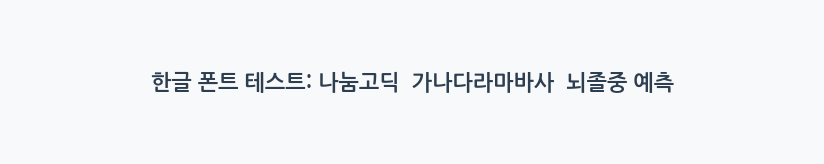

In [3]:
# ================================================================
#  뇌졸중(Stroke) 예측 — XGBoost + XAI 핸즈온 실습
# ================================================================

import subprocess, os, glob, warnings
warnings.filterwarnings('ignore')

# ────────────────────────────────────────────────────────────────
# SECTION 0 & 1  패키지 설치, 스타일 및 한글 폰트 설정
# ────────────────────────────────────────────────────────────────

# ── [1] 필수 패키지 및 나눔 폰트 설치 ─────────────────────────────
print("패키지 및 한글 폰트 설치 중...")
subprocess.run(['pip', 'install', '-q', 'xgboost', 'shap', 'PyALE', 'imbalanced-learn'], check=True)
subprocess.run(['apt-get', 'install', '-y', '-q', 'fonts-nanum'], check=True)

# ── [2] 데이터 분석 및 시각화 라이브러리 임포트 ───────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import matplotlib.gridspec as gridspec
from IPython.display import display

# ── [3] 시각화 스타일 고정 (★폰트 설정보다 먼저 실행해야 함) ──────
sns.set_style("whitegrid")

# ── [4] 한글 폰트 명시적 등록 및 전역 적용 ───────────────────────
# 런타임 재시작 없이 즉시 반영하기 위해 addfont() 사용
nanum_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

if os.path.exists(nanum_path):
    fm.fontManager.addfont(nanum_path)  # 시스템에 설치된 폰트를 matplotlib에 직접 등록
    font_name = fm.FontProperties(fname=nanum_path).get_name()

    plt.rcParams['font.family'] = font_name
    plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지
    plt.rcParams['figure.dpi'] = 120
    plt.rcParams['font.size'] = 11
    print(f"✅ 한글 폰트 설정 완료: {font_name}")
else:
    print("❌ 나눔고딕 폰트를 찾을 수 없습니다.")

# ── [5] 기타 머신러닝 라이브러리 임포트 ──────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, accuracy_score, brier_score_loss
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.inspection import PartialDependenceDisplay
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap
from PyALE import ale

print(f"✅ 라이브러리 로드 완료  |  XGBoost {xgb.__version__}  |  SHAP {shap.__version__}\n")

# ── [6] 폰트 적용 검증 테스트 ───────────────────────────
_fig, _ax = plt.subplots(figsize=(7, 1.5))
_ax.text(0.5, 0.5,
         '한글 폰트 테스트: 나눔고딕  가나다라마바사  뇌졸중 예측',
         ha='center', va='center', fontsize=13, fontweight='bold', color='#2C3E50')
_ax.axis('off')
_fig.patch.set_facecolor('#F8F9FA')
plt.tight_layout()
plt.show()

In [49]:
# ────────────────────────────────────────────────────────────────
# SECTION 2  데이터 로드 & 전처리
# ────────────────────────────────────────────────────────────────
# Colab 업로드 방식 (필요 시 주석 해제):
from google.colab import files
uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])

print(f"\n📊 원본 데이터  {df.shape[0]:,}행 × {df.shape[1]}열")
display(df.head())

df = df.drop(columns=['id'])
df = df[df['gender'] != 'Other'].copy()
df['bmi'] = pd.to_numeric(df['bmi'], errors='coerce')
df['bmi'] = df['bmi'].fillna(df['bmi'].median()) # BMI 결측 대치
df['gender']         = df['gender'].map({'Male':0,'Female':1})
df['ever_married']   = df['ever_married'].map({'No':0,'Yes':1})
df['Residence_type'] = df['Residence_type'].map({'Rural':0,'Urban':1})
df['smoking_status'] = df['smoking_status'].map(
    {'never smoked':0,'Unknown':1,'formerly smoked':2,'smokes':3})
df = pd.get_dummies(df, columns=['work_type'], drop_first=False)

feature_cols = [c for c in df.columns if c != 'stroke']
X = df[feature_cols];  y = df['stroke']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f"   학습 크기   : {X_train.shape}  (SMOTE 전)")

smote = SMOTE(random_state=42, k_neighbors=5)
X_tr, y_tr = smote.fit_resample(X_train, y_train)

print(f"\n✅ 전처리 완료")
print(f"   피처 수     : {len(feature_cols)}개")
print(f"   학습 크기   : {X_tr.shape}  (SMOTE 후)")
print(f"   테스트 크기 : {X_test.shape}")
print(f"   양성 비율   : {y.mean()*100:.1f}%  → 심각한 클래스 불균형 → SMOTE 적용")
print()

Saving 1.stroke.csv to 1.stroke (12).csv

📊 원본 데이터  5,110행 × 12열


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


   학습 크기   : (4087, 14)  (SMOTE 전)

✅ 전처리 완료
   피처 수     : 14개
   학습 크기   : (7776, 14)  (SMOTE 후)
   테스트 크기 : (1022, 14)
   양성 비율   : 4.9%  → 심각한 클래스 불균형 → SMOTE 적용



In [71]:
# ────────────────────────────────────────────────────────────────
# SECTION 3  XGBoost 학습
# ────────────────────────────────────────────────────────────────

# 1. 학습 데이터에만 SMOTE 적용 (소수 클래스를 다수 클래스 양만큼 증증)
smote = SMOTE(random_state=42)
X_tr_resampled, y_tr_resampled = smote.fit_resample(X_tr, y_tr)

# 2. XGBoost 모델 설정
# (주의: SMOTE로 비율을 맞췄으므로 scale_pos_weight는 제외합니다)
params = dict(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=100,
    eval_metric='auc',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

model_smote = xgb.XGBClassifier(**params)

# 3. 오버샘플링된 데이터로 학습 진행
model_smote.fit(
    X_tr_resampled, y_tr_resampled,
    eval_set=[(X_test, y_test)], # 검증은 오리지널 데이터로 수행
    verbose=50
)

# 예측 확률 추출
y_prob = model_smote.predict_proba(X_test)[:, 1]
print("\n✅ SMOTE 적용 XGBoost 학습 완료\n")

[0]	validation_0-auc:0.76679
[50]	validation_0-auc:0.77851
[100]	validation_0-auc:0.78430
[150]	validation_0-auc:0.78961
[200]	validation_0-auc:0.78397
[248]	validation_0-auc:0.77971

✅ SMOTE 적용 XGBoost 학습 완료



In [72]:
# ════════════════════════════════════════════════════════════════
# SECTION 4  성능 지표
# ════════════════════════════════════════════════════════════════
print("="*65)
print("  SECTION 4 : 성능 지표")
print("="*65)

# 기본 임계값(0.5) 기준 예측값 생성
y_pred_05  = (y_prob >= 0.5).astype(int)

def calc_metrics(y_true, y_pred, y_prob, label=''):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    m = {'임계값 레이블': label,
         'TP':tp,'TN':tn,'FP':fp,'FN':fn,
         'Accuracy'   : accuracy_score(y_true, y_pred),
         'Sensitivity': tp/(tp+fn),
         'Specificity': tn/(tn+fp),
         'Precision'  : tp/(tp+fp) if (tp+fp)>0 else 0,
         'F1-Score'   : f1_score(y_true, y_pred),
         'AUROC'      : roc_auc_score(y_true, y_prob),
         'AUPRC'      : average_precision_score(y_true, y_prob),
         'Brier Score': brier_score_loss(y_true, y_prob),
         'NPV'        : tn/(tn+fn) if (tn+fn)>0 else 0,
         'FPR (1-Spe)': fp/(fp+tn) if (fp+tn)>0 else 0}
    return m

# 기본 임계값 결과만 계산 및 데이터프레임 변환
m1 = calc_metrics(y_test, y_pred_05,  y_prob, '0.50 (기본)')
metrics_df = pd.DataFrame([m1]).set_index('임계값 레이블').T

display(metrics_df.style
        .format(lambda v: f'{v:.4f}' if isinstance(v,float) else str(v))
        .background_gradient(cmap='Blues', axis=1))


  SECTION 4 : 성능 지표


임계값 레이블,0.50 (기본)
TP,23.0000
TN,842.0000
FP,130.0000
FN,27.0000
Accuracy,0.8464
Sensitivity,0.4600
Specificity,0.8663
Precision,0.1503
F1-Score,0.2266
AUROC,0.7898


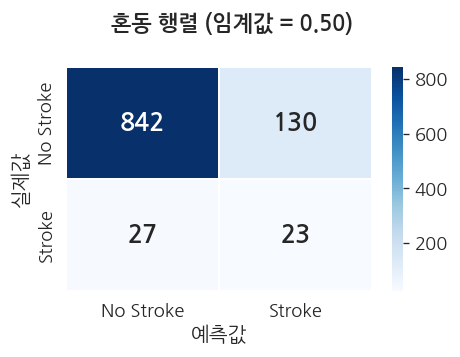


┌─────────────────────────────────────────────────────────────────┐
│  【혼동 행렬 해석】                                              │
│                                                                 │
│  ■ 혼동 행렬 구조                                               │
│    TN (좌상) : 뇌졸중 없음 → 없음으로 정확히 예측 (진음성)     │
│    FP (우상) : 뇌졸중 없음 → 있음으로 잘못 예측 (위양성)       │
│    FN (좌하) : 뇌졸중 있음 → 없음으로 잘못 예측 (위음성) ★    │
│    TP (우하) : 뇌졸중 있음 → 있음으로 정확히 예측 (진양성)     │
│                                                                 │
│  ■ 기본 임계값 0.50 데이터 특징                                 │
│    • 클래스 불균형이 심한 의료 데이터에서는 기본 임계값(0.50)을 │
│      사용할 경우, 환자를 놓치는 FN(위음성)의 비율과 수치를      │
│      유심히 살필 필요가 있습니다.                               │
└─────────────────────────────────────────────────────────────────┘



In [73]:
# ── 혼동행렬 시각화 ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(4, 3))
fig.suptitle('혼동 행렬 (임계값 = 0.50)', fontsize=13, fontweight='bold')

# 기본 임계값(0.50) 기준 혼동 행렬 계산 및 시각화
cm = confusion_matrix(y_test, y_pred_05)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Stroke','Stroke'],
            yticklabels=['No Stroke','Stroke'],
            linewidths=1, linecolor='white', annot_kws={'size':15,'weight':'bold'})

ax.set_xlabel('예측값', fontsize=12)
ax.set_ylabel('실제값', fontsize=12)

plt.tight_layout()
plt.show()

print("""
┌─────────────────────────────────────────────────────────────────┐
│  【혼동 행렬 해석】                                              │
│                                                                 │
│  ■ 혼동 행렬 구조                                               │
│    TN (좌상) : 뇌졸중 없음 → 없음으로 정확히 예측 (진음성)     │
│    FP (우상) : 뇌졸중 없음 → 있음으로 잘못 예측 (위양성)       │
│    FN (좌하) : 뇌졸중 있음 → 없음으로 잘못 예측 (위음성) ★    │
│    TP (우하) : 뇌졸중 있음 → 있음으로 정확히 예측 (진양성)     │
│                                                                 │
│  ■ 기본 임계값 0.50 데이터 특징                                 │
│    • 클래스 불균형이 심한 의료 데이터에서는 기본 임계값(0.50)을 │
│      사용할 경우, 환자를 놓치는 FN(위음성)의 비율과 수치를      │
│      유심히 살필 필요가 있습니다.                               │
└─────────────────────────────────────────────────────────────────┘
""")

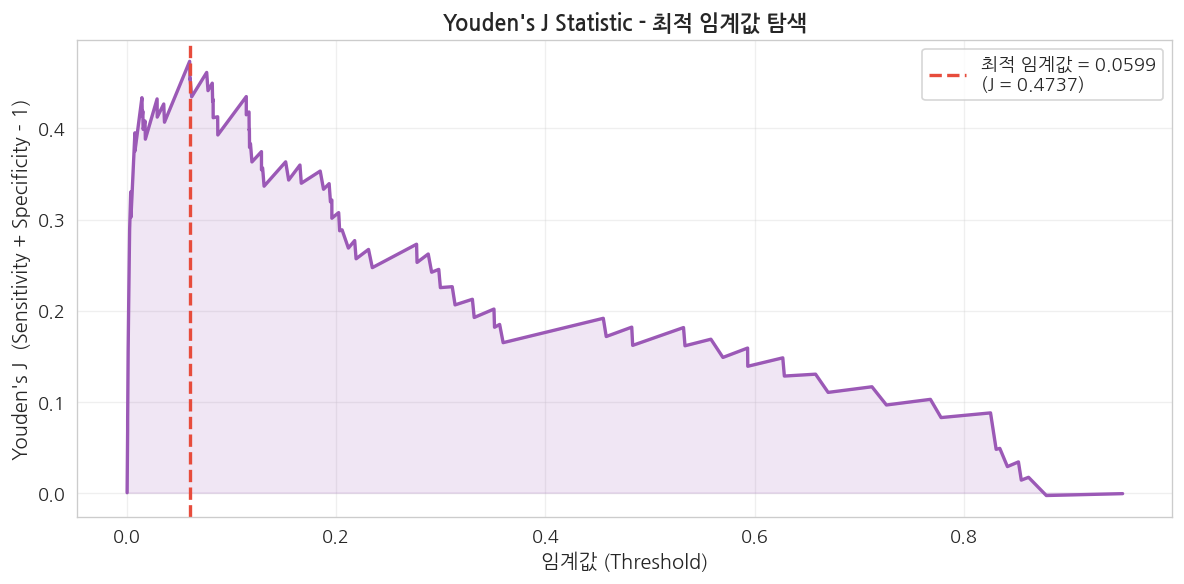


┌─────────────────────────────────────────────────────────────────┐
│  【Youden's J Statistic 해석】                                  │
│                                                                 │
│  ■ Youden's J = Sensitivity + Specificity - 1                 │
│    = TPR - FPR  (ROC 곡선에서 대각선과의 수직 거리)           │
│                                                                 │
│  ■ 최적 임계값: 0.0599                               │
│    - 이 임계값에서 J = 0.4737 (최대)                   │
│    - Sensitivity = 0.8400                   │
│    - Specificity = 0.6337                   │
│                                                                 │
│  ■ 해석                                                        │
│    - 기본 임계값(0.5)보다 낮은 임계값이 최적인 경우: 데이터가 불균형하거나 양성 예측 확률이 전반적으로 낮음   │
│    - 임계값을 낮추면 민감도↑ / 특이도↓ 발생                  │
│    - 뇌졸중처럼 "놓치면 위험"한 질환은 Sensitivity를 우선하는 임계값 선택이 임상적으로 합리적   │
│    - 곡선의 피크(붉은 점선)가 최적 임계값                      │
└──────────────────────────────────────

In [74]:
# ── Youden's J 시각화 ─────────────────────────────────────
valid = thresholds < 1.0
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(thresholds[valid], youden_j[valid], color='#9B59B6', lw=2)
ax.axvline(best_thr, color='#E74C3C', linestyle='--', lw=2,
           label=f"최적 임계값 = {best_thr:.4f}\n(J = {best_j:.4f})")
ax.fill_between(thresholds[valid], youden_j[valid], alpha=0.15, color='#9B59B6')
ax.set_xlabel('임계값 (Threshold)', fontsize=12)
ax.set_ylabel("Youden's J  (Sensitivity + Specificity - 1)", fontsize=12)
ax.set_title("Youden's J Statistic - 최적 임계값 탐색", fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"""
┌─────────────────────────────────────────────────────────────────┐
│  【Youden's J Statistic 해석】                                  │
│                                                                 │
│  ■ Youden's J = Sensitivity + Specificity - 1                 │
│    = TPR - FPR  (ROC 곡선에서 대각선과의 수직 거리)           │
│                                                                 │
│  ■ 최적 임계값: {best_thr:.4f}                               │
│    - 이 임계값에서 J = {best_j:.4f} (최대)                   │
│    - Sensitivity = {m2['Sensitivity']:.4f}                   │
│    - Specificity = {m2['Specificity']:.4f}                   │
│                                                                 │
│  ■ 해석                                                        │
│    - 기본 임계값(0.5)보다 낮은 임계값이 최적인 경우: 데이터가 불균형하거나 양성 예측 확률이 전반적으로 낮음   │
│    - 임계값을 낮추면 민감도↑ / 특이도↓ 발생                  │
│    - 뇌졸중처럼 "놓치면 위험"한 질환은 Sensitivity를 우선하는 임계값 선택이 임상적으로 합리적   │
│    - 곡선의 피크(붉은 점선)가 최적 임계값                      │
└─────────────────────────────────────────────────────────────────┘
""")

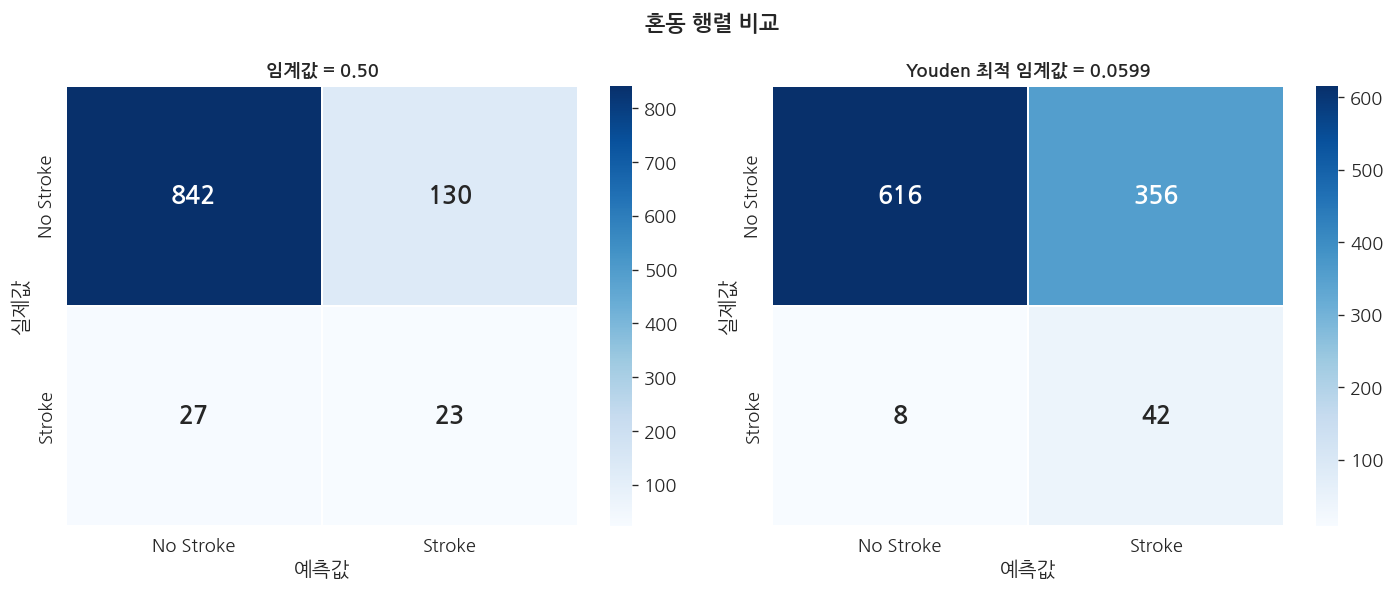


┌─────────────────────────────────────────────────────────────────┐
│  【혼동 행렬 해석】                                             │
│                                                                 │
│  ■ 혼동 행렬 구조                                              │
│    TN (좌상) : 뇌졸중 없음 → 없음으로 정확히 예측 (진음성)    │
│    FP (우상) : 뇌졸중 없음 → 있음으로 잘못 예측 (위양성)      │
│    FN (좌하) : 뇌졸중 있음 → 없음으로 잘못 예측 (위음성) ★   │
│    TP (우하) : 뇌졸중 있음 → 있음으로 정확히 예측 (진양성)    │
│                                                                 │
│  ■ 임계값 0.50 (기본) vs Youden 최적 임계값                   │
│    • 임계값을 낮출수록 더 많은 환자를 양성으로 분류            │
│      → FN 감소(뇌졸중 환자를 놓치는 수 줄어듦), FP 증가       │
│    • 의료 스크리닝에서는 FN(위음성)이 더 위험                  │
│      → Youden 임계값이 Sensitivity·Specificity 균형 최적화     │
│    • TN이 매우 많은 이유: 데이터의 95%가 비뇌졸중 환자         │
└─────────────────────────────────────────────────────────────────┘



In [75]:
# ── 혼동행렬 시각화 ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12,5))
fig.suptitle('혼동 행렬 비교', fontsize=13, fontweight='bold')
for ax, y_pred, lbl in zip(
        axes,[y_pred_05, y_pred_opt],
        ['임계값 = 0.50', f'Youden 최적 임계값 = {best_thr:.4f}']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Stroke','Stroke'],
                yticklabels=['No Stroke','Stroke'],
                linewidths=1, linecolor='white', annot_kws={'size':15,'weight':'bold'})
    ax.set_xlabel('예측값', fontsize=12); ax.set_ylabel('실제값', fontsize=12)
    ax.set_title(lbl, fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

print("""
┌─────────────────────────────────────────────────────────────────┐
│  【혼동 행렬 해석】                                             │
│                                                                 │
│  ■ 혼동 행렬 구조                                              │
│    TN (좌상) : 뇌졸중 없음 → 없음으로 정확히 예측 (진음성)    │
│    FP (우상) : 뇌졸중 없음 → 있음으로 잘못 예측 (위양성)      │
│    FN (좌하) : 뇌졸중 있음 → 없음으로 잘못 예측 (위음성) ★   │
│    TP (우하) : 뇌졸중 있음 → 있음으로 정확히 예측 (진양성)    │
│                                                                 │
│  ■ 임계값 0.50 (기본) vs Youden 최적 임계값                   │
│    • 임계값을 낮출수록 더 많은 환자를 양성으로 분류            │
│      → FN 감소(뇌졸중 환자를 놓치는 수 줄어듦), FP 증가       │
│    • 의료 스크리닝에서는 FN(위음성)이 더 위험                  │
│      → Youden 임계값이 Sensitivity·Specificity 균형 최적화     │
│    • TN이 매우 많은 이유: 데이터의 95%가 비뇌졸중 환자         │
└─────────────────────────────────────────────────────────────────┘
""")

In [76]:
# ── 일반(임계값 0.5) vs. Youden's J 성능 비교─────────────────────────────────────
fpr_arr, tpr_arr, thresholds = roc_curve(y_test, y_prob)
youden_j = tpr_arr - fpr_arr
best_idx = np.argmax(youden_j)
best_thr = thresholds[best_idx]
best_j   = youden_j[best_idx]

y_pred_opt = (y_prob >= best_thr).astype(int)
y_pred_05  = (y_prob >= 0.5).astype(int)

def calc_metrics(y_true, y_pred, y_prob, label=''):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    m = {'임계값 레이블': label,
         'TP':tp,'TN':tn,'FP':fp,'FN':fn,
         'Accuracy'   : accuracy_score(y_true, y_pred),
         'Sensitivity': tp/(tp+fn),
         'Specificity': tn/(tn+fp),
         'Precision'  : tp/(tp+fp) if (tp+fp)>0 else 0,
         'F1-Score'   : f1_score(y_true, y_pred),
         'AUROC'      : roc_auc_score(y_true, y_prob),
         'AUPRC'      : average_precision_score(y_true, y_prob),
         'Brier Score': brier_score_loss(y_true, y_prob)}
    m["Youden's J"]  = m['Sensitivity']+m['Specificity']-1
    m['NPV']         = tn/(tn+fn) if (tn+fn)>0 else 0
    m['FPR (1-Spe)'] = fp/(fp+tn) if (fp+tn)>0 else 0
    return m

m1 = calc_metrics(y_test, y_pred_05,  y_prob, '0.50 (기본)')
m2 = calc_metrics(y_test, y_pred_opt, y_prob, f'{best_thr:.4f} (Youden)')
metrics_df = pd.DataFrame([m1,m2]).set_index('임계값 레이블').T
display(metrics_df.style
        .format(lambda v: f'{v:.4f}' if isinstance(v,float) else str(v))
        .background_gradient(cmap='Blues', axis=1))

임계값 레이블,0.50 (기본),0.1886 (Youden)
TP,23.0000,43.0000
TN,842.0000,588.0000
FP,130.0000,384.0000
FN,27.0000,7.0000
Accuracy,0.8464,0.6174
Sensitivity,0.4600,0.8600
Specificity,0.8663,0.6049
Precision,0.1503,0.1007
F1-Score,0.2266,0.1803
AUROC,0.7898,0.7898


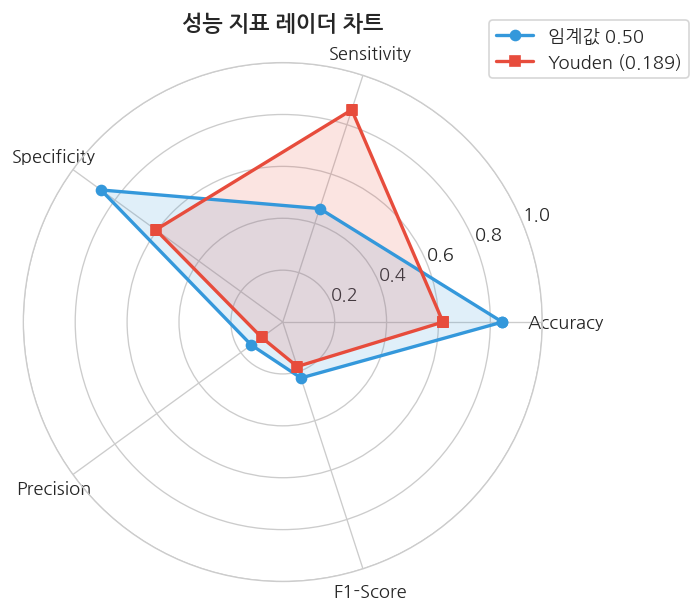


┌─────────────────────────────────────────────────────────────────┐
│  【성능 지표 상세 해석】                                        │
│                                                                 │
│  ■ Accuracy (정확도) : 전체 중 맞게 예측한 비율               │
│    → 클래스 불균형이 심하면 높아도 의미 없음 (함정 지표)       │
│    → 비뇌졸중이 95%이므로 모두 음성 예측해도 95% 달성 가능    │
│                                                                 │
│  ■ Sensitivity (민감도 / Recall / TPR)                        │
│    = TP / (TP+FN) → 실제 뇌졸중 환자를 얼마나 잡아냈는가      │
│    → 의료 스크리닝에서 가장 중요한 지표                        │
│    → 높을수록 뇌졸중 환자를 놓치지 않음                        │
│                                                                 │
│  ■ Specificity (특이도)                                        │
│    = TN / (TN+FP) → 정상인을 정상으로 분류하는 능력           │
│    → Sensitivity와 트레이드오프 관계                           │
│                                                                 │
│  ■ Precision (정밀도)                                          │
│

In [77]:
# ── 레이더 차트 ──────────────────────────────────────────
radar_keys = ['Accuracy','Sensitivity','Specificity','Precision','F1-Score']
vals1 = [m1[k] for k in radar_keys]
vals2 = [m2[k] for k in radar_keys]
angles = np.linspace(0,2*np.pi,len(radar_keys),endpoint=False).tolist()
vals1+=vals1[:1]; vals2+=vals2[:1]; angles+=angles[:1]

fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))
ax.plot(angles, vals1, 'o-', lw=2, color='#3498DB', label='임계값 0.50')
ax.fill(angles, vals1, alpha=0.15, color='#3498DB')
ax.plot(angles, vals2, 's-', lw=2, color='#E74C3C', label=f'Youden ({best_thr:.3f})')
ax.fill(angles, vals2, alpha=0.15, color='#E74C3C')
ax.set_thetagrids(np.degrees(angles[:-1]), radar_keys, fontsize=11)
ax.set_ylim(0,1)
ax.set_title('성능 지표 레이더 차트', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3,1.1))
plt.tight_layout(); plt.show()

print(f"""
┌─────────────────────────────────────────────────────────────────┐
│  【성능 지표 상세 해석】                                        │
│                                                                 │
│  ■ Accuracy (정확도) : 전체 중 맞게 예측한 비율               │
│    → 클래스 불균형이 심하면 높아도 의미 없음 (함정 지표)       │
│    → 비뇌졸중이 95%이므로 모두 음성 예측해도 95% 달성 가능    │
│                                                                 │
│  ■ Sensitivity (민감도 / Recall / TPR)                        │
│    = TP / (TP+FN) → 실제 뇌졸중 환자를 얼마나 잡아냈는가      │
│    → 의료 스크리닝에서 가장 중요한 지표                        │
│    → 높을수록 뇌졸중 환자를 놓치지 않음                        │
│                                                                 │
│  ■ Specificity (특이도)                                        │
│    = TN / (TN+FP) → 정상인을 정상으로 분류하는 능력           │
│    → Sensitivity와 트레이드오프 관계                           │
│                                                                 │
│  ■ Precision (정밀도)                                          │
│    = TP / (TP+FP) → 양성 예측 중 실제 뇌졸중 비율            │
│    → 낮으면 불필요한 추가 검사가 많아짐                        │
│                                                                 │
│  ■ F1-Score : Precision·Recall의 조화 평균                    │
│    → 클래스 불균형 데이터에서 Accuracy 대안                    │
│                                                                 │
│  ■ AUROC : 임계값과 무관한 모델의 판별 능력 (0.5~1.0)         │
│    → 0.7~0.8: 양호  0.8~0.9: 우수  0.9+: 탁월                │
│                                                                 │
│  ■ AUPRC : 양성 클래스 불균형 시 AUROC보다 신뢰성 높음        │
│    → 기준선(양성 비율)보다 높아야 의미 있음                    │
│                                                                 │
│  ■ Youden's J = Sensitivity + Specificity - 1                 │
│    = {best_j:.4f}  (임계값: {best_thr:.4f})
│    → 0에 가까울수록 무작위, 1에 가까울수록 완벽               │
│    → 두 지표의 합을 최대화하는 최적 임계값 탐색               │
│                                                                 │
│  ■ NPV (음성 예측도): TN/(TN+FN)                              │
│    → 음성 예측이 실제로 음성일 확률                            │
└─────────────────────────────────────────────────────────────────┘
""")


  SECTION 5 : ROC Curve & Youden's J


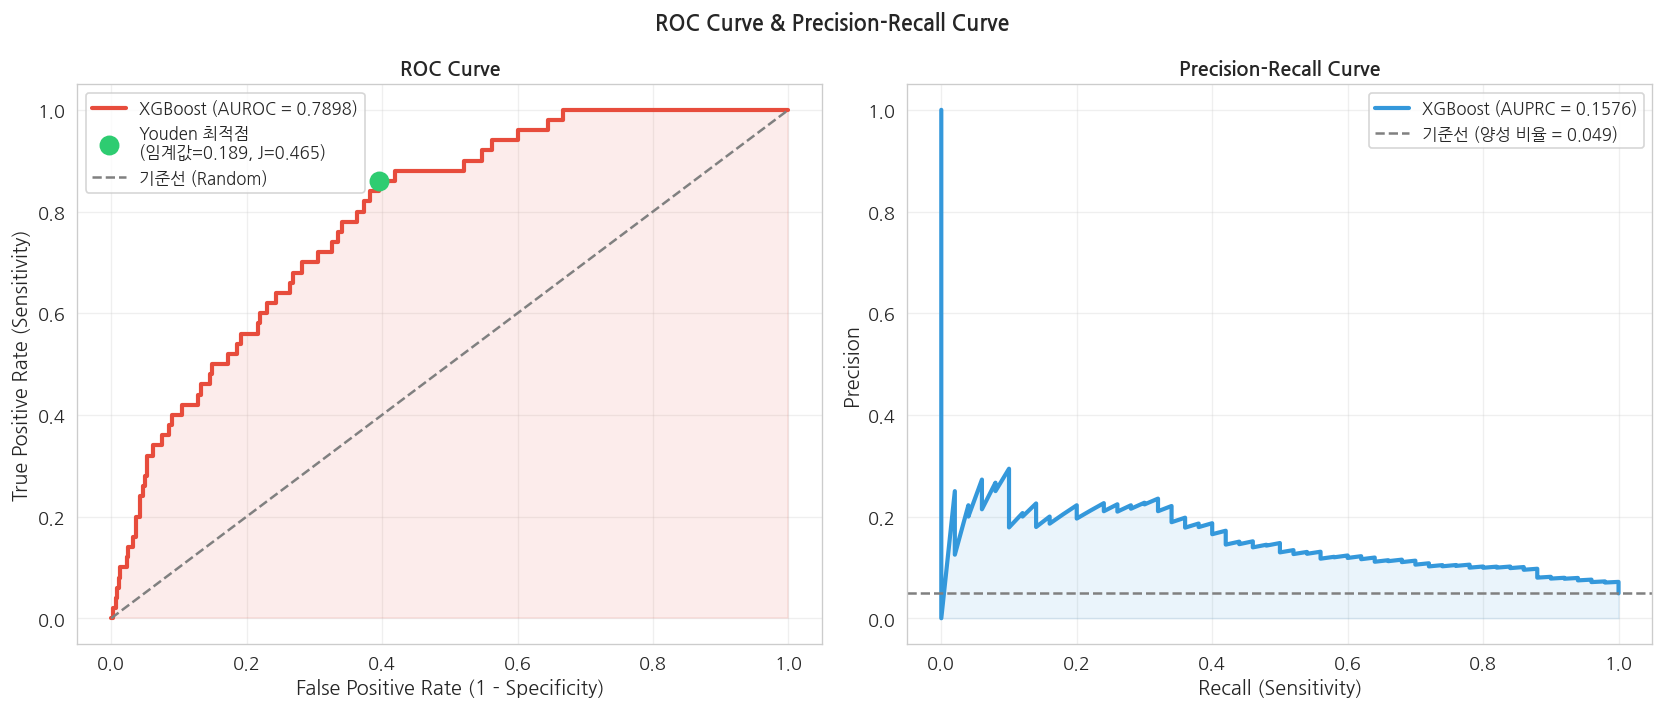


┌─────────────────────────────────────────────────────────────────┐
│  【ROC Curve 해석】                                             │
│                                                                 │
│  ■ ROC 곡선                                                    │
│    - X축: FPR(위양성률), Y축: TPR(민감도=진양성률)            │
│    - 곡선이 좌상단(0,1)에 가까울수록 우수한 모델               │
│    - 대각선(점선): 무작위 예측 기준선 (AUC=0.5)               │
│    - AUROC = 0.7898 → 모델이 뇌졸중/비뇌졸중을 구별하는 │
│      능력이 79.0%로 양호한 수준                    │
│    - 녹색 점: Youden's J 최적 임계값 위치                      │
│      → 해당 점에서 Sensitivity+Specificity 합이 최대           │
│                                                                 │
│  ■ Precision-Recall Curve                                      │
│    - X축: Recall(민감도), Y축: Precision(정밀도)              │
│    - AUPRC = 0.1576                                      │
│    - 기준선(회색): 무작위 예측 = 양성 비율(0.049)    │
│    - AUPRC가 기준선보다 높아야 의미 있음 → 본 모델 달성       │
│    - 클래스 불균형이 심할 때 AUROC보

In [78]:
# ════════════════════════════════════════════════════════════════
# SECTION 5  ROC Curve 시각화
# ════════════════════════════════════════════════════════════════
print("="*65)
print("  SECTION 5 : ROC Curve & Youden's J")
print("="*65)

auroc = roc_auc_score(y_test, y_prob)
auprc = average_precision_score(y_test, y_prob)
prec_arr, rec_arr, _ = precision_recall_curve(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(14,6))
fig.suptitle('ROC Curve & Precision-Recall Curve', fontsize=13, fontweight='bold')

axes[0].plot(fpr_arr, tpr_arr, color='#E74C3C', lw=2.5,
             label=f'XGBoost (AUROC = {auroc:.4f})')
axes[0].scatter(fpr_arr[best_idx], tpr_arr[best_idx], color='#2ECC71', s=120, zorder=5,
                label=f"Youden 최적점\n(임계값={best_thr:.3f}, J={best_j:.3f})")
axes[0].plot([0,1],[0,1],'--', color='gray', lw=1.5, label='기준선 (Random)')
axes[0].fill_between(fpr_arr, tpr_arr, alpha=0.1, color='#E74C3C')
axes[0].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
axes[0].set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
axes[0].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.3)

baseline = y_test.mean()
axes[1].plot(rec_arr, prec_arr, color='#3498DB', lw=2.5,
             label=f'XGBoost (AUPRC = {auprc:.4f})')
axes[1].axhline(baseline, color='gray', linestyle='--', lw=1.5,
                label=f'기준선 (양성 비율 = {baseline:.3f})')
axes[1].fill_between(rec_arr, prec_arr, alpha=0.1, color='#3498DB')
axes[1].set_xlabel('Recall (Sensitivity)', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"""
┌─────────────────────────────────────────────────────────────────┐
│  【ROC Curve 해석】                                             │
│                                                                 │
│  ■ ROC 곡선                                                    │
│    - X축: FPR(위양성률), Y축: TPR(민감도=진양성률)            │
│    - 곡선이 좌상단(0,1)에 가까울수록 우수한 모델               │
│    - 대각선(점선): 무작위 예측 기준선 (AUC=0.5)               │
│    - AUROC = {auroc:.4f} → 모델이 뇌졸중/비뇌졸중을 구별하는 │
│      능력이 {auroc*100:.1f}%로 양호한 수준                    │
│    - 녹색 점: Youden's J 최적 임계값 위치                      │
│      → 해당 점에서 Sensitivity+Specificity 합이 최대           │
│                                                                 │
│  ■ Precision-Recall Curve                                      │
│    - X축: Recall(민감도), Y축: Precision(정밀도)              │
│    - AUPRC = {auprc:.4f}                                      │
│    - 기준선(회색): 무작위 예측 = 양성 비율({baseline:.3f})    │
│    - AUPRC가 기준선보다 높아야 의미 있음 → 본 모델 달성       │
│    - 클래스 불균형이 심할 때 AUROC보다 신뢰성 높은 지표       │
│    - Recall이 높아질수록 Precision이 떨어지는 트레이드오프    │
└─────────────────────────────────────────────────────────────────┘
""")

In [79]:
# ════════════════════════════════════════════════════════════════
# SECTION 6  SHAP 분석
# ════════════════════════════════════════════════════════════════
print("="*65)
print("  SECTION 6 : SHAP 분석")
print("="*65)

explainer     = shap.TreeExplainer(model)
shap_exp      = explainer(X_test)
sv            = shap_exp.values
base_val      = explainer.expected_value
feature_names = feature_cols

print(f"\nSHAP values shape : {sv.shape}")
print(f"Base value (log-odds) : {base_val:.4f}  →  확률 {1/(1+np.exp(-base_val)):.4f}")
print("""
【SHAP 기초 개념】
  SHAP(SHapley Additive exPlanations)은 게임이론의 Shapley값을 머신러닝에 적용한 XAI 기법
  각 피처가 개별 예측에 얼마나, 어떤 방향으로 기여했는지를 정량화
  • SHAP값 > 0 : 해당 피처가 뇌졸중 확률을 높이는 방향으로 기여
  • SHAP값 < 0 : 해당 피처가 뇌졸중 확률을 낮추는 방향으로 기여
  • Base value : 모든 피처를 무시했을 때의 평균 예측값 (log-odds)
  • 예측값 = Base value + 모든 피처의 SHAP값 합계
""")


  SECTION 6 : SHAP 분석

SHAP values shape : (1022, 14)
Base value (log-odds) : 0.0012  →  확률 0.5003

【SHAP 기초 개념】
  SHAP(SHapley Additive exPlanations)은 게임이론의 Shapley값을 머신러닝에 적용한 XAI 기법
  각 피처가 개별 예측에 얼마나, 어떤 방향으로 기여했는지를 정량화
  • SHAP값 > 0 : 해당 피처가 뇌졸중 확률을 높이는 방향으로 기여
  • SHAP값 < 0 : 해당 피처가 뇌졸중 확률을 낮추는 방향으로 기여
  • Base value : 모든 피처를 무시했을 때의 평균 예측값 (log-odds)
  • 예측값 = Base value + 모든 피처의 SHAP값 합계



──────────────────────────────────────────────────
[ 6-1 ] Beeswarm Plot
──────────────────────────────────────────────────


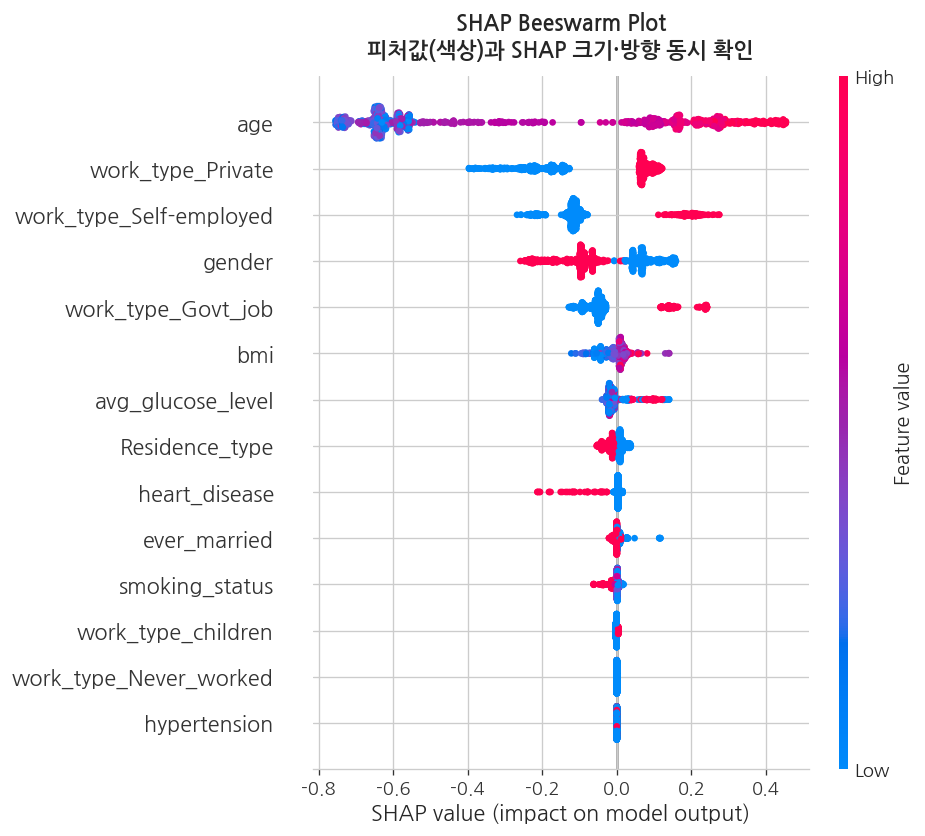


┌─────────────────────────────────────────────────────────────────┐
│  【Beeswarm Plot 해석】                                         │
│                                                                 │
│  ■ 그래프 읽는 법                                              │
│    - Y축: 피처 목록 (평균 |SHAP|이 큰 순서대로 위에서 아래)   │
│    - X축: SHAP값 (양수=뇌졸중 위험↑, 음수=뇌졸중 위험↓)     │
│    - 점 색상: 피처의 원래 값 (빨강=높은 값, 파랑=낮은 값)     │
│    - 각 점: 테스트 셋의 개별 샘플 하나                         │
│                                                                 │
│  ■ 주요 피처별 해석                                            │
│    ① age                 : 가장 영향력 큰 피처                  │
│       빨간 점이 오른쪽 → 높은 값일수록 뇌졸중 위험 증가       │
│    ② work_type_Private   : 두 번째 영향 피처                    │
│       SHAP 분포가 넓을수록 샘플 간 영향 차이가 큼             │
│    ③ work_type_Self-employed: 세 번째 영향 피처                    │
│                                                                 │
│  ■ 패턴 해석 포인트                                            │
│   

In [80]:
# ── 6-1. Beeswarm Plot ──────────────────────────────────
print("─"*50)
print("[ 6-1 ] Beeswarm Plot")
print("─"*50)
plt.figure(figsize=(10,7))
shap.plots.beeswarm(shap_exp, max_display=15, show=False)
plt.title('SHAP Beeswarm Plot\n피처값(색상)과 SHAP 크기·방향 동시 확인',
          fontsize=13, fontweight='bold', pad=12)
plt.tight_layout(); plt.show()

mean_abs_shap = pd.Series(np.abs(sv).mean(axis=0), index=feature_names).nlargest(5)
top1, top2, top3 = mean_abs_shap.index[:3]
print(f"""
┌─────────────────────────────────────────────────────────────────┐
│  【Beeswarm Plot 해석】                                         │
│                                                                 │
│  ■ 그래프 읽는 법                                              │
│    - Y축: 피처 목록 (평균 |SHAP|이 큰 순서대로 위에서 아래)   │
│    - X축: SHAP값 (양수=뇌졸중 위험↑, 음수=뇌졸중 위험↓)     │
│    - 점 색상: 피처의 원래 값 (빨강=높은 값, 파랑=낮은 값)     │
│    - 각 점: 테스트 셋의 개별 샘플 하나                         │
│                                                                 │
│  ■ 주요 피처별 해석                                            │
│    ① {top1:<20}: 가장 영향력 큰 피처                  │
│       빨간 점이 오른쪽 → 높은 값일수록 뇌졸중 위험 증가       │
│    ② {top2:<20}: 두 번째 영향 피처                    │
│       SHAP 분포가 넓을수록 샘플 간 영향 차이가 큼             │
│    ③ {top3:<20}: 세 번째 영향 피처                    │
│                                                                 │
│  ■ 패턴 해석 포인트                                            │
│    - 빨간 점이 오른쪽 + 파란 점이 왼쪽: 피처값이 클수록 위험  │
│    - 빨간 점이 왼쪽 + 파란 점이 오른쪽: 피처값이 클수록 보호  │
│    - 점들이 촘촘히 모임: 해당 피처의 영향이 일관적            │
│    - 점들이 넓게 퍼짐: 샘플마다 다른 상호작용 효과 존재       │
└─────────────────────────────────────────────────────────────────┘
""")


──────────────────────────────────────────────────
[ 6-2 ] Bar Plot — 전역 피처 중요도
──────────────────────────────────────────────────


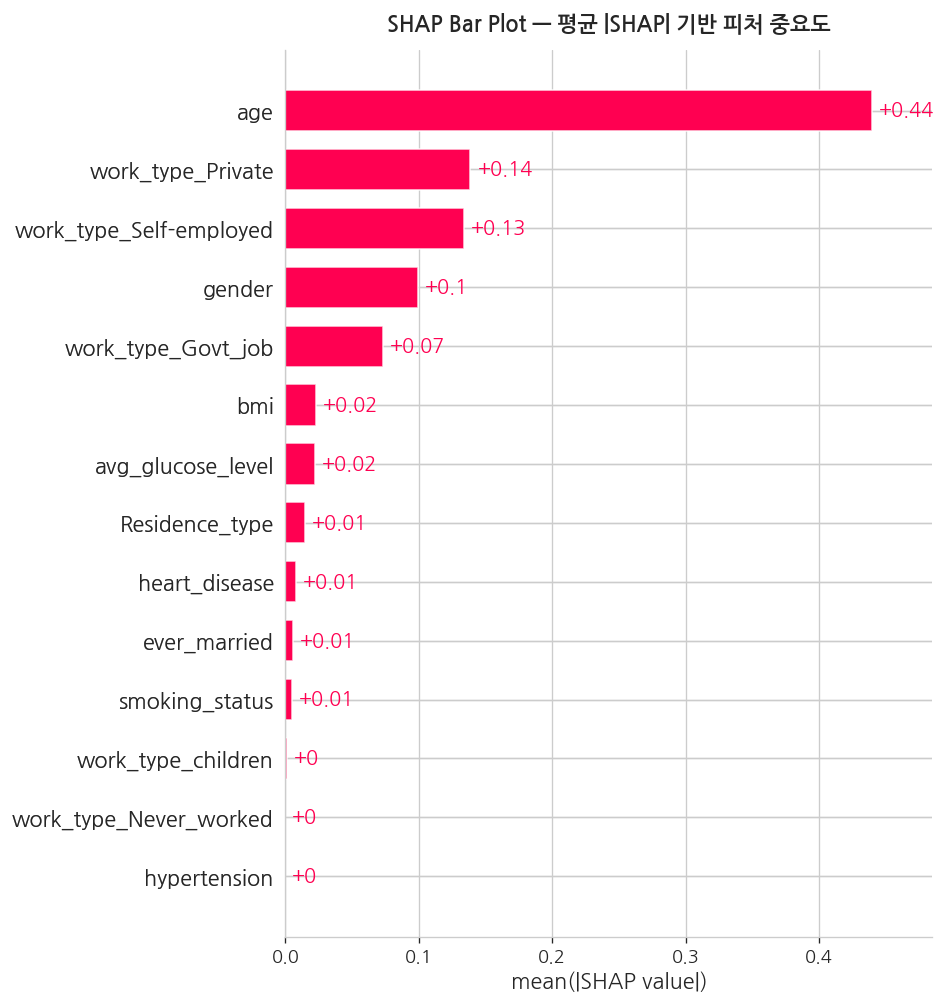


┌─────────────────────────────────────────────────────────────────┐
│  【Bar Plot 해석】                                              │
│                                                                 │
│  ■ 측정 방식: 평균 |SHAP값| (절댓값 평균 → 방향 무관 중요도) │
│                                                                 │
│  ■ 피처 중요도 Top 5                                           │
│    1위: age                     0.4398   │
│    2위: work_type_Private       0.1387   │
│    3위: work_type_Self-employed  0.1339   │
│    4위: gender                  0.0997   │
│    5위: work_type_Govt_job      0.0728   │
│                                                                 │
│  ■ XGBoost 내장 중요도와의 차이                                │
│    - XGBoost weight: 피처가 분기에 사용된 횟수 (빈도 기반)    │
│    - XGBoost gain: 분기 시 불순도 감소량 (정확도 기반)        │
│    - SHAP: 실제 예측값에 대한 기여도 (인과적 해석 가능)        │
│    → SHAP이 가장 해석학적으로 신뢰성 높은 방법                │
└─────────────────────────────────────────────────────────────────┘



In [81]:
# ── 6-2. Bar Plot ───────────────────────────────────────
print("─"*50)
print("[ 6-2 ] Bar Plot — 전역 피처 중요도")
print("─"*50)
plt.figure(figsize=(9,6))
shap.plots.bar(shap_exp, max_display=15, show=False)
plt.title('SHAP Bar Plot — 평균 |SHAP| 기반 피처 중요도',
          fontsize=13, fontweight='bold', pad=12)
plt.tight_layout(); plt.show()

imp_series = pd.Series(np.abs(sv).mean(axis=0), index=feature_names).sort_values(ascending=False)
print(f"""
┌─────────────────────────────────────────────────────────────────┐
│  【Bar Plot 해석】                                              │
│                                                                 │
│  ■ 측정 방식: 평균 |SHAP값| (절댓값 평균 → 방향 무관 중요도) │
│                                                                 │
│  ■ 피처 중요도 Top 5                                           │
│    1위: {imp_series.index[0]:<22}  {imp_series.iloc[0]:.4f}   │
│    2위: {imp_series.index[1]:<22}  {imp_series.iloc[1]:.4f}   │
│    3위: {imp_series.index[2]:<22}  {imp_series.iloc[2]:.4f}   │
│    4위: {imp_series.index[3]:<22}  {imp_series.iloc[3]:.4f}   │
│    5위: {imp_series.index[4]:<22}  {imp_series.iloc[4]:.4f}   │
│                                                                 │
│  ■ XGBoost 내장 중요도와의 차이                                │
│    - XGBoost weight: 피처가 분기에 사용된 횟수 (빈도 기반)    │
│    - XGBoost gain: 분기 시 불순도 감소량 (정확도 기반)        │
│    - SHAP: 실제 예측값에 대한 기여도 (인과적 해석 가능)        │
│    → SHAP이 가장 해석학적으로 신뢰성 높은 방법                │
└─────────────────────────────────────────────────────────────────┘
""")

──────────────────────────────────────────────────
[ 6-3 ] Waterfall Plot — 개별 예측 분해
──────────────────────────────────────────────────


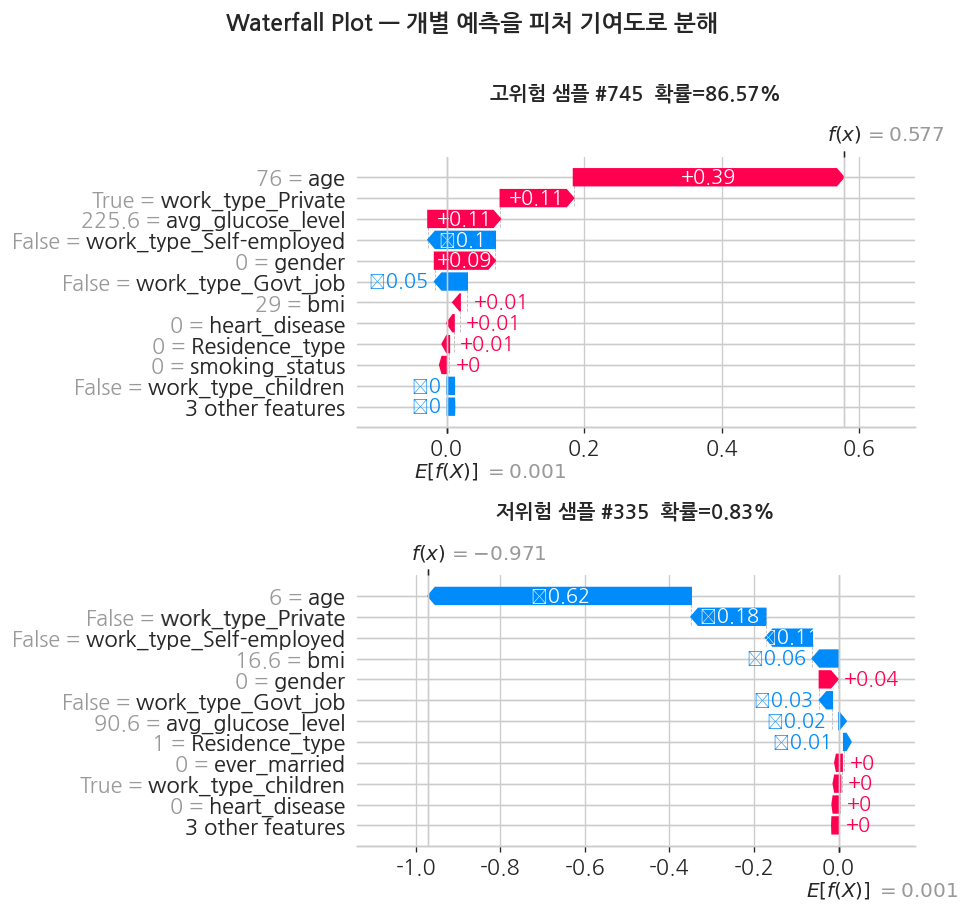


┌─────────────────────────────────────────────────────────────────┐
│  【Waterfall Plot 해석】                                        │
│                                                                 │
│  ■ 그래프 읽는 법                                              │
│    - 맨 아래: E[f(X)] = Base value (전체 평균 예측값)          │
│    - 각 막대: 개별 피처의 SHAP 기여도                          │
│      빨간 막대(→): 뇌졸중 확률 높이는 방향 기여               │
│      파란 막대(←): 뇌졸중 확률 낮추는 방향 기여               │
│    - 맨 위: f(X) = 최종 예측 확률                              │
│    - 막대를 아래서부터 쌓으면 최종값이 됨                      │
│                                                                 │
│  ■ 고위험 샘플 #745 해석 (뇌졸중 확률 86.57%)     │
│    - 핵심 위험 피처: age                             │
│    - 빨간 막대들이 Base value를 오른쪽으로 크게 이동           │
│    - 이 환자는 여러 위험 요인이 겹쳐 높은 위험도              │
│                                                                 │
│  ■ 저위험 샘플 #335 해석 (뇌졸중 확률 0.83%)     │
│    - 핵심 보호 피처: age                          

In [82]:
# ── 6-3. Waterfall Plot ─────────────────────────────────
print("─"*50)
print("[ 6-3 ] Waterfall Plot — 개별 예측 분해")
print("─"*50)
hi_idx = int(np.argmax(y_prob))
lo_idx = int(np.argmin(y_prob))

# 좌/우(1, 2) 배치를 위/아래(2, 1) 배치로 변경하고 가로 폭을 넓혔습니다.
fig, axes = plt.subplots(2, 1, figsize=(12, 15))

for ax, idx, lbl in zip(
        axes, [hi_idx, lo_idx],
        [f'고위험 샘플 #{hi_idx}  확률={y_prob[hi_idx]:.2%}',
         f'저위험 샘플 #{lo_idx}  확률={y_prob[lo_idx]:.2%}']):

    plt.sca(ax)
    # SHAP 플롯 생성
    shap.plots.waterfall(shap_exp[idx], max_display=12, show=False)
    # 타이틀이 그래프와 너무 붙지 않도록 pad 추가
    ax.set_title(lbl, fontsize=12, fontweight='bold', pad=15)

# 전체 타이틀 위치 조정 (y값을 살짝 올려 그래프와 겹치지 않게 함)
plt.suptitle('Waterfall Plot — 개별 예측을 피처 기여도로 분해',
             fontsize=14, fontweight='bold', y=1.01)

# 플롯 간격 자동 조정 후 출력
plt.tight_layout()
plt.show()

hi_top_feat = feature_names[np.argmax(np.abs(sv[hi_idx]))]
lo_top_feat = feature_names[np.argmax(np.abs(sv[lo_idx]))]
print(f"""
┌─────────────────────────────────────────────────────────────────┐
│  【Waterfall Plot 해석】                                        │
│                                                                 │
│  ■ 그래프 읽는 법                                              │
│    - 맨 아래: E[f(X)] = Base value (전체 평균 예측값)          │
│    - 각 막대: 개별 피처의 SHAP 기여도                          │
│      빨간 막대(→): 뇌졸중 확률 높이는 방향 기여               │
│      파란 막대(←): 뇌졸중 확률 낮추는 방향 기여               │
│    - 맨 위: f(X) = 최종 예측 확률                              │
│    - 막대를 아래서부터 쌓으면 최종값이 됨                      │
│                                                                 │
│  ■ 고위험 샘플 #{hi_idx} 해석 (뇌졸중 확률 {y_prob[hi_idx]:.2%})     │
│    - 핵심 위험 피처: {hi_top_feat}                             │
│    - 빨간 막대들이 Base value를 오른쪽으로 크게 이동           │
│    - 이 환자는 여러 위험 요인이 겹쳐 높은 위험도              │
│                                                                 │
│  ■ 저위험 샘플 #{lo_idx} 해석 (뇌졸중 확률 {y_prob[lo_idx]:.2%})     │
│    - 핵심 보호 피처: {lo_top_feat}                             │
│    - 파란 막대들이 Base value를 왼쪽으로 이동                  │
│    - 이 환자는 보호 요인들이 위험 요인을 상쇄                  │
│                                                                 │
│  ■ 활용                                                        │
│    - 개별 환자에 대해 "왜 이 예측이 나왔는가" 설명 가능        │
│    - 임상에서 의사에게 AI 예측 근거 제시 시 유용               │
└─────────────────────────────────────────────────────────────────┘
""")

──────────────────────────────────────────────────
[ 6-4 ] Force Plot — 고위험 샘플 Force 시각화
──────────────────────────────────────────────────


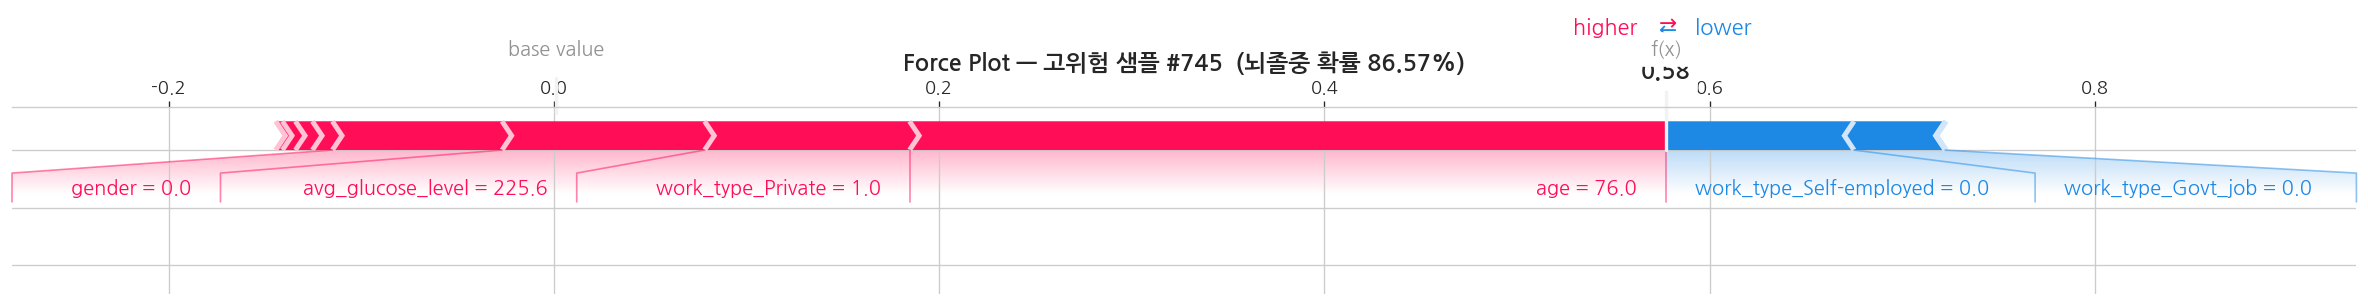


┌─────────────────────────────────────────────────────────────────┐
│  【Force Plot 해석】                                            │
│                                                                 │
│  ■ 그래프 읽는 법                                              │
│    - 중앙 굵은 숫자: 최종 예측 확률 (f(x))                    │
│    - 빨간 화살표(→): 예측값을 높이는 피처와 기여 크기         │
│    - 파란 화살표(←): 예측값을 낮추는 피처와 기여 크기         │
│    - 화살표 길이: 기여도의 크기                                │
│    - 기준점(base value): 모든 피처 제외 시 평균 예측           │
│                                                                 │
│  ■ Waterfall vs Force Plot                                     │
│    - Waterfall: 수직 막대로 누적 표현 (정적, 상세)            │
│    - Force Plot: 수평 화살표로 한눈에 표현 (직관적)            │
│    - 동일한 정보를 다른 방식으로 시각화                        │
│                                                                 │
│  ■ 전체 200명 HTML 파일 (shap_force_all.html)                 │
│    - 브라우저에서 열면 샘플별 Force Plot 인터랙티브 탐색 가능 │
│    - 슬라이더로 

In [96]:
# ── 6-4. Force Plot ─────────────────────────────────────
print("─"*50)
print("[ 6-4 ] Force Plot — 고위험 샘플 Force 시각화")
print("─"*50)
shap.initjs()
shap.force_plot(base_val, sv[hi_idx], X_test.iloc[hi_idx],
                feature_names=feature_names, matplotlib=True, show=False)
plt.title(f'Force Plot — 고위험 샘플 #{hi_idx}  (뇌졸중 확률 {y_prob[hi_idx]:.2%})',
          fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

fp_html = shap.force_plot(base_val, sv[:200], X_test.iloc[:200],
                           feature_names=feature_names)
shap.save_html('shap_force_all.html', fp_html)

print(f"""
┌─────────────────────────────────────────────────────────────────┐
│  【Force Plot 해석】                                            │
│                                                                 │
│  ■ 그래프 읽는 법                                              │
│    - 중앙 굵은 숫자: 최종 예측 확률 (f(x))                    │
│    - 빨간 화살표(→): 예측값을 높이는 피처와 기여 크기         │
│    - 파란 화살표(←): 예측값을 낮추는 피처와 기여 크기         │
│    - 화살표 길이: 기여도의 크기                                │
│    - 기준점(base value): 모든 피처 제외 시 평균 예측           │
│                                                                 │
│  ■ Waterfall vs Force Plot                                     │
│    - Waterfall: 수직 막대로 누적 표현 (정적, 상세)            │
│    - Force Plot: 수평 화살표로 한눈에 표현 (직관적)            │
│    - 동일한 정보를 다른 방식으로 시각화                        │
│                                                                 │
│  ■ 전체 200명 HTML 파일 (shap_force_all.html)                 │
│    - 브라우저에서 열면 샘플별 Force Plot 인터랙티브 탐색 가능 │
│    - 슬라이더로 샘플 이동, 피처별 정렬 등 가능                │
└─────────────────────────────────────────────────────────────────┘
""")

──────────────────────────────────────────────────
[ 6-5 ] Dependence Plot — 피처값 vs SHAP값
──────────────────────────────────────────────────


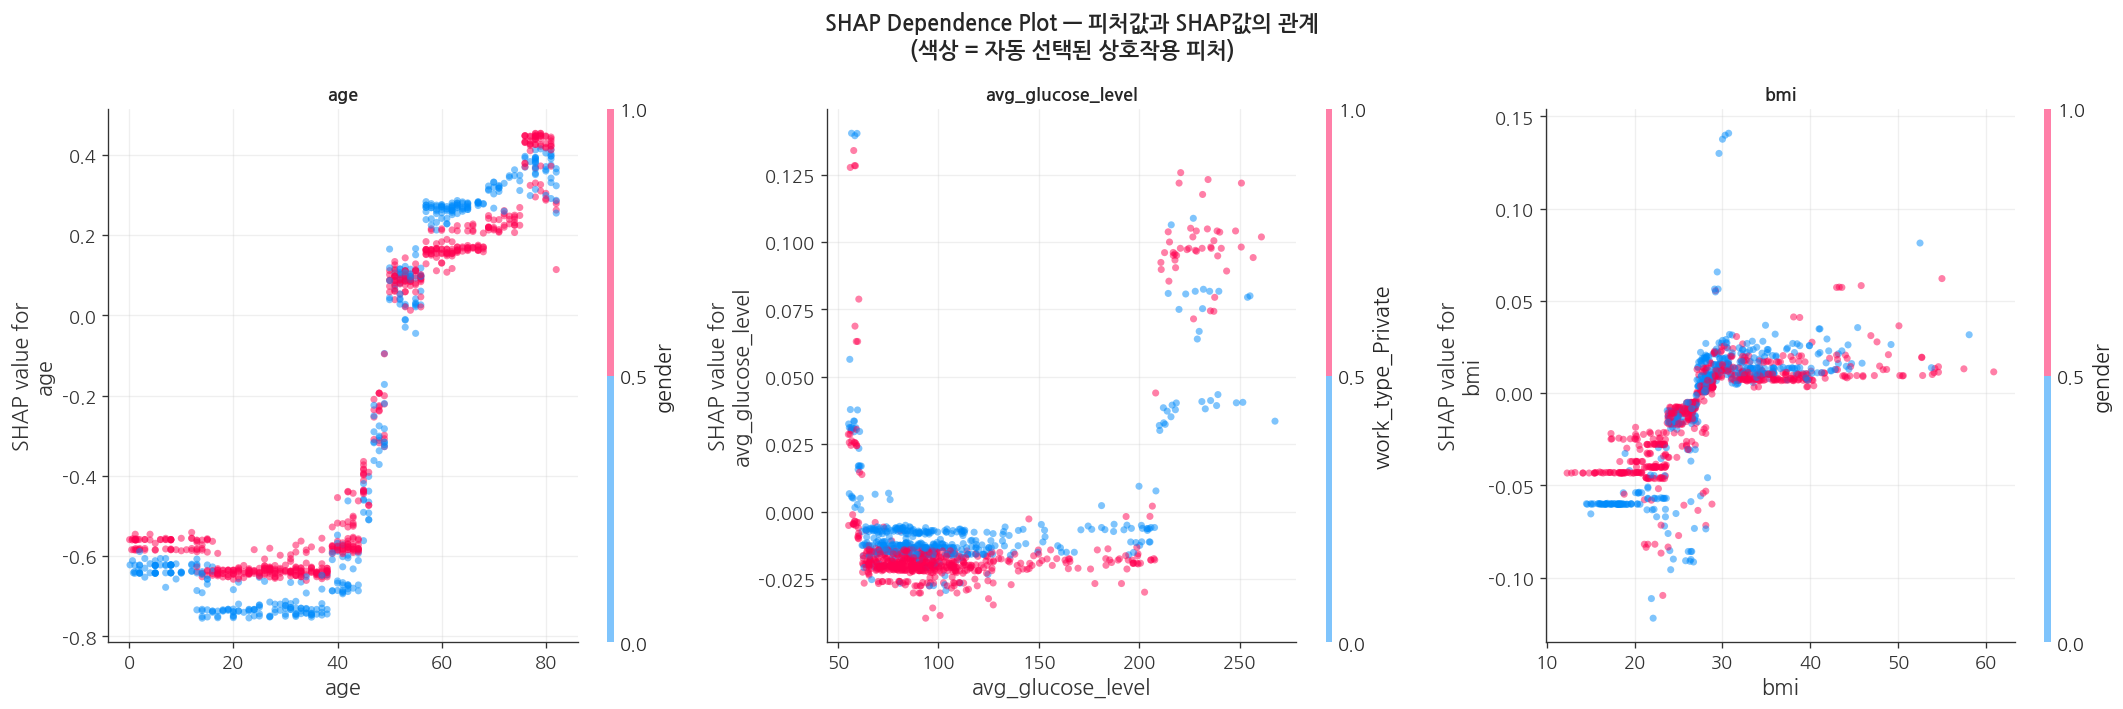


┌─────────────────────────────────────────────────────────────────┐
│  【Dependence Plot 해석】                                       │
│                                                                 │
│  ■ 그래프 읽는 법                                              │
│    - X축: 해당 피처의 실제 값                                  │
│    - Y축: 해당 피처의 SHAP값                                   │
│    - 점 색상: 자동 선택된 가장 강한 상호작용 피처의 값         │
│    - Y=0 기준선: SHAP값 0 (영향 없음)                          │
│                                                                 │
│  ■ 나이(age) 해석                                              │
│    - X축 오른쪽(고령)으로 갈수록 SHAP값이 증가하는 추세       │
│    - 특정 나이 이후 SHAP값이 급격히 상승하는 변곡점 존재      │
│    - 색상 변화: 다른 피처(예: 혈당)와의 상호작용 패턴         │
│      → 같은 나이라도 혈당이 높으면(빨강) SHAP이 더 높음       │
│                                                                 │
│  ■ 평균 혈당(avg_glucose_level) 해석                           │
│    - 혈당이 높을수록 SHAP값 증가 (비선형 증가 가능)           │
│    - 당뇨성 고혈당 구간

In [84]:
# ── 6-5. Dependence Plot ────────────────────────────────
print("─"*50)
print("[ 6-5 ] Dependence Plot — 피처값 vs SHAP값")
print("─"*50)
key_feats = ['age', 'avg_glucose_level', 'bmi']
fig, axes = plt.subplots(1, 3, figsize=(18,6))
fig.suptitle('SHAP Dependence Plot — 피처값과 SHAP값의 관계\n(색상 = 자동 선택된 상호작용 피처)',
             fontsize=13, fontweight='bold')
for ax, feat in zip(axes, key_feats):
    shap.dependence_plot(feat, sv, X_test, interaction_index='auto',
                         ax=ax, show=False, alpha=0.5, dot_size=18)
    ax.set_title(feat, fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"""
┌─────────────────────────────────────────────────────────────────┐
│  【Dependence Plot 해석】                                       │
│                                                                 │
│  ■ 그래프 읽는 법                                              │
│    - X축: 해당 피처의 실제 값                                  │
│    - Y축: 해당 피처의 SHAP값                                   │
│    - 점 색상: 자동 선택된 가장 강한 상호작용 피처의 값         │
│    - Y=0 기준선: SHAP값 0 (영향 없음)                          │
│                                                                 │
│  ■ 나이(age) 해석                                              │
│    - X축 오른쪽(고령)으로 갈수록 SHAP값이 증가하는 추세       │
│    - 특정 나이 이후 SHAP값이 급격히 상승하는 변곡점 존재      │
│    - 색상 변화: 다른 피처(예: 혈당)와의 상호작용 패턴         │
│      → 같은 나이라도 혈당이 높으면(빨강) SHAP이 더 높음       │
│                                                                 │
│  ■ 평균 혈당(avg_glucose_level) 해석                           │
│    - 혈당이 높을수록 SHAP값 증가 (비선형 증가 가능)           │
│    - 당뇨성 고혈당 구간에서 위험 급증 패턴 확인               │
│                                                                 │
│  ■ BMI 해석                                                    │
│    - BMI가 극단값(매우 낮거나 매우 높음)에서 영향 증가        │
│    - 색상 분포로 나이·혈당과의 상호작용 방향 파악 가능         │
│                                                                 │
│  ■ PDP와의 차이                                                │
│    - PDP: 평균 효과만 보여줌 (샘플별 점 없음)                 │
│    - Dependence Plot: 모든 샘플의 개별 SHAP값 표시            │
│      → 이질성(heterogeneity)과 상호작용 동시 확인 가능        │
└─────────────────────────────────────────────────────────────────┘
""")

──────────────────────────────────────────────────
[ 6-6 ] Interaction Values — 히트맵  (계산 중...)
──────────────────────────────────────────────────


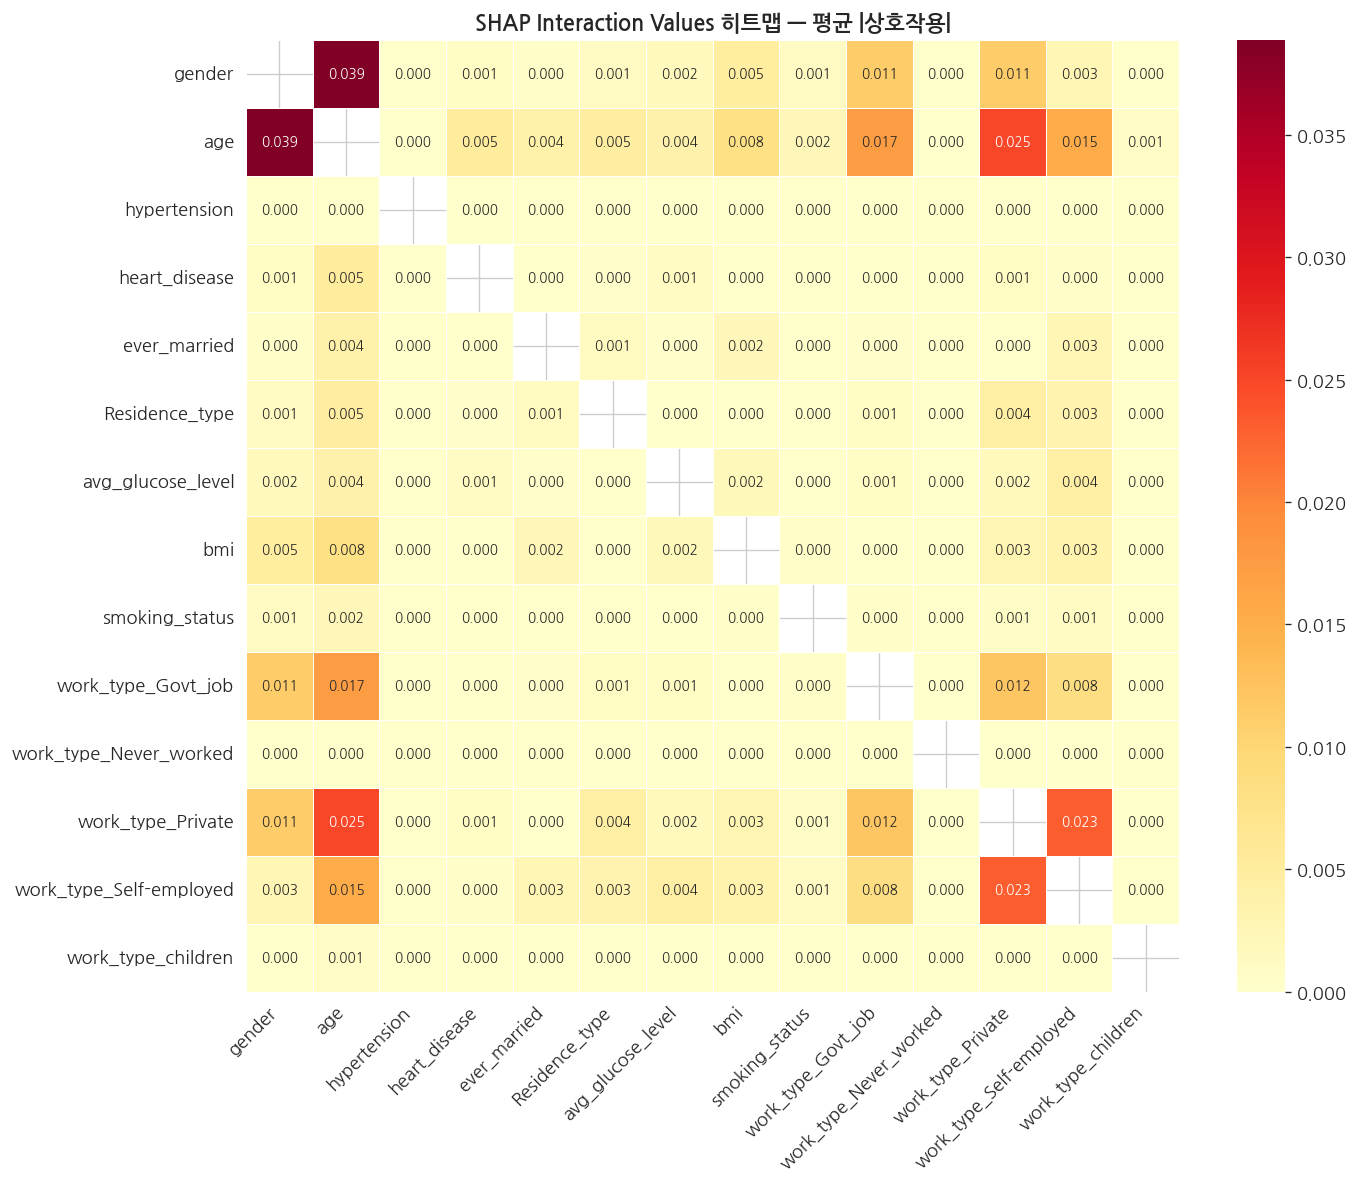


상위 피처 상호작용 쌍:


,피처1,피처2,평균 |상호작용|
0,age,gender,0.038893
1,work_type_Private,age,0.024960
2,work_type_Self-employed,work_type_Private,0.023110
3,work_type_Govt_job,age,0.017346
4,work_type_Self-employed,age,0.015380



┌─────────────────────────────────────────────────────────────────┐
│  【Interaction Values 히트맵 해석】                             │
│                                                                 │
│  ■ 히트맵 읽는 법                                              │
│    - 행·열: 피처                                               │
│    - 셀값: 두 피처의 평균 |SHAP 상호작용값|                    │
│    - 진한 색(높은 값): 두 피처 간 상호작용 강함                │
│    - 대각선(마스킹): 피처 자체의 주효과 (제외)                 │
│                                                                 │
│  ■ SHAP 상호작용값의 의미                                      │
│    - 두 피처가 함께 있을 때 단순 합보다 더 크거나 작은 효과   │
│    - 양의 상호작용: 두 피처가 시너지로 위험 증가              │
│    - 음의 상호작용: 한 피처가 다른 피처 효과를 억제            │
│                                                                 │
│  ■ 가장 강한 상호작용 쌍                                       │
│    1위: age × gender                                           │
│         평균 |상호작용| = 0.0389                           │
│    →

In [85]:
# ── 6-6. Interaction Values ─────────────────────────────
print("─"*50)
print("[ 6-6 ] Interaction Values — 히트맵  (계산 중...)")
print("─"*50)
sv_interact   = explainer.shap_interaction_values(X_test)
mean_interact = np.abs(sv_interact).mean(axis=0)
interact_df   = pd.DataFrame(mean_interact, index=feature_names, columns=feature_names)

plt.figure(figsize=(12,10))
mask_diag = np.eye(len(feature_names), dtype=bool)
sns.heatmap(interact_df, mask=mask_diag, annot=True, fmt='.3f',
            cmap='YlOrRd', linewidths=0.4, annot_kws={'size':8})
plt.title('SHAP Interaction Values 히트맵 — 평균 |상호작용|',
          fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

upper = interact_df.copy()
np.fill_diagonal(upper.values, 0)
for i in range(len(feature_names)):
    for j in range(i): upper.iloc[j,i] = 0
top_pairs = (upper.stack().nlargest(5).reset_index()
             .rename(columns={'level_0':'피처1','level_1':'피처2',0:'평균 |상호작용|'}))
print("\n상위 피처 상호작용 쌍:")
display(top_pairs)

p1 = top_pairs.iloc[0]['피처1']; p2 = top_pairs.iloc[0]['피처2']
p1v = top_pairs.iloc[0]['평균 |상호작용|']
print(f"""
┌─────────────────────────────────────────────────────────────────┐
│  【Interaction Values 히트맵 해석】                             │
│                                                                 │
│  ■ 히트맵 읽는 법                                              │
│    - 행·열: 피처                                               │
│    - 셀값: 두 피처의 평균 |SHAP 상호작용값|                    │
│    - 진한 색(높은 값): 두 피처 간 상호작용 강함                │
│    - 대각선(마스킹): 피처 자체의 주효과 (제외)                 │
│                                                                 │
│  ■ SHAP 상호작용값의 의미                                      │
│    - 두 피처가 함께 있을 때 단순 합보다 더 크거나 작은 효과   │
│    - 양의 상호작용: 두 피처가 시너지로 위험 증가              │
│    - 음의 상호작용: 한 피처가 다른 피처 효과를 억제            │
│                                                                 │
│  ■ 가장 강한 상호작용 쌍                                       │
│    1위: {p1} × {p2}                                           │
│         평균 |상호작용| = {p1v:.4f}                           │
│    → 이 두 피처가 함께 작용할 때 예측에 추가 영향 발생        │
│    → 예: 고령 + 고혈당이 동시에 있으면 위험이 더 크게 증가   │
│                                                                 │
│  ■ 활용                                                        │
│    - 임상에서 복합 위험 요인 조합 파악에 유용                  │
│    - 강한 상호작용 쌍은 Dependence Plot으로 추가 탐색 권장    │
└─────────────────────────────────────────────────────────────────┘
""")

──────────────────────────────────────────────────
[ 6-7 ] Decision Plot — 예측 경로 시각화
──────────────────────────────────────────────────


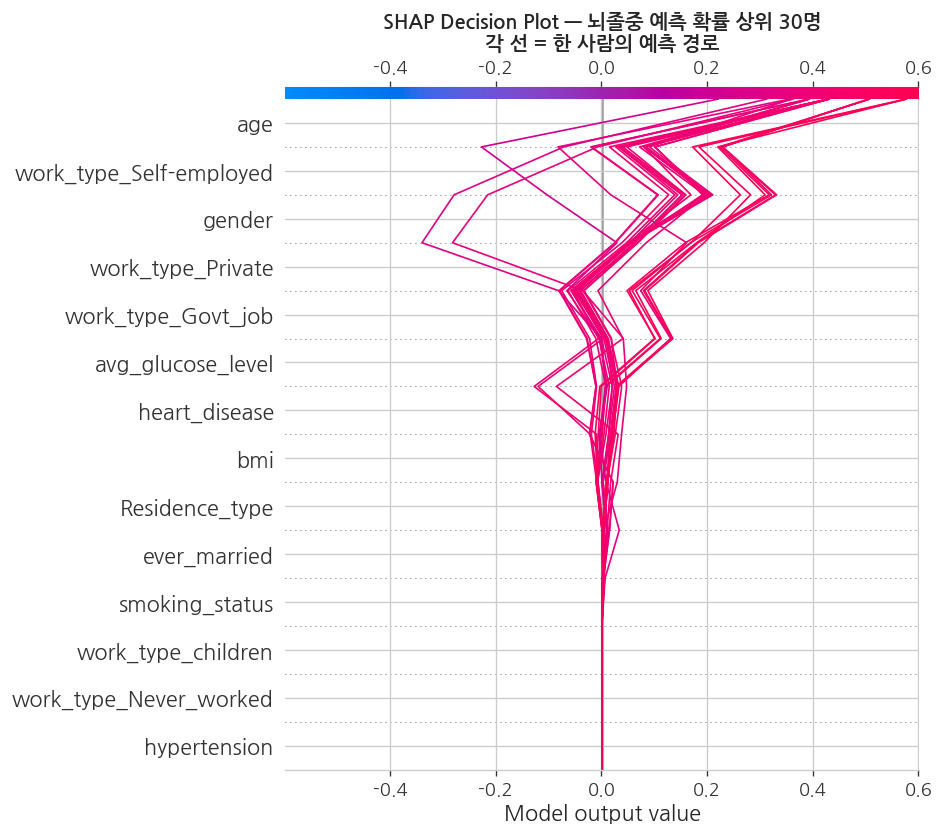


┌─────────────────────────────────────────────────────────────────┐
│  【Decision Plot 해석】                                         │
│                                                                 │
│  ■ 그래프 읽는 법                                              │
│    - 각 선: 개별 샘플(환자) 하나의 예측 경로                   │
│    - X축: 예측값 (model output)                                │
│    - Y축: 피처 (아래=중요도 낮음, 위=중요도 높음)             │
│    - 맨 아래: Base value에서 출발                              │
│    - 맨 위: 최종 예측값에 도달                                 │
│                                                                 │
│  ■ 패턴 해석                                                   │
│    - 선들이 비슷한 경로: 해당 피처가 일관되게 영향             │
│    - 선들이 교차/분기: 환자마다 다른 위험 요인 패턴            │
│    - 상위 30명(고위험군)의 선이 오른쪽으로 모이는 경향         │
│                                                                 │
│  ■ Waterfall vs Decision Plot                                  │
│    - Waterfall: 단일 샘플, 피처별 절댓값 기여 시각화        

In [86]:
# ── 6-7. Decision Plot ──────────────────────────────────
print("─"*50)
print("[ 6-7 ] Decision Plot — 예측 경로 시각화")
print("─"*50)
top30 = np.argsort(y_prob)[-30:]
plt.figure(figsize=(10,8))
shap.decision_plot(base_val, sv[top30], X_test.iloc[top30],
                   feature_names=feature_names, show=False)
plt.title('SHAP Decision Plot — 뇌졸중 예측 확률 상위 30명\n각 선 = 한 사람의 예측 경로',
          fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"""
┌─────────────────────────────────────────────────────────────────┐
│  【Decision Plot 해석】                                         │
│                                                                 │
│  ■ 그래프 읽는 법                                              │
│    - 각 선: 개별 샘플(환자) 하나의 예측 경로                   │
│    - X축: 예측값 (model output)                                │
│    - Y축: 피처 (아래=중요도 낮음, 위=중요도 높음)             │
│    - 맨 아래: Base value에서 출발                              │
│    - 맨 위: 최종 예측값에 도달                                 │
│                                                                 │
│  ■ 패턴 해석                                                   │
│    - 선들이 비슷한 경로: 해당 피처가 일관되게 영향             │
│    - 선들이 교차/분기: 환자마다 다른 위험 요인 패턴            │
│    - 상위 30명(고위험군)의 선이 오른쪽으로 모이는 경향         │
│                                                                 │
│  ■ Waterfall vs Decision Plot                                  │
│    - Waterfall: 단일 샘플, 피처별 절댓값 기여 시각화           │
│    - Decision Plot: 다수 샘플 비교, 경로 패턴 파악             │
│    → "고위험군은 어떤 공통 경로를 갖는가" 파악에 적합         │
│                                                                 │
│  ■ 임상적 활용                                                 │
│    - 비슷한 경로를 가진 환자들: 유사한 위험 프로파일 보유     │
│    - 이상 경로(outlier 선): 특이 케이스로 추가 검토 필요       │
└─────────────────────────────────────────────────────────────────┘
""")


──────────────────────────────────────────────────
[ 6-8 ] 클래스별 평균 SHAP 기여 방향
──────────────────────────────────────────────────


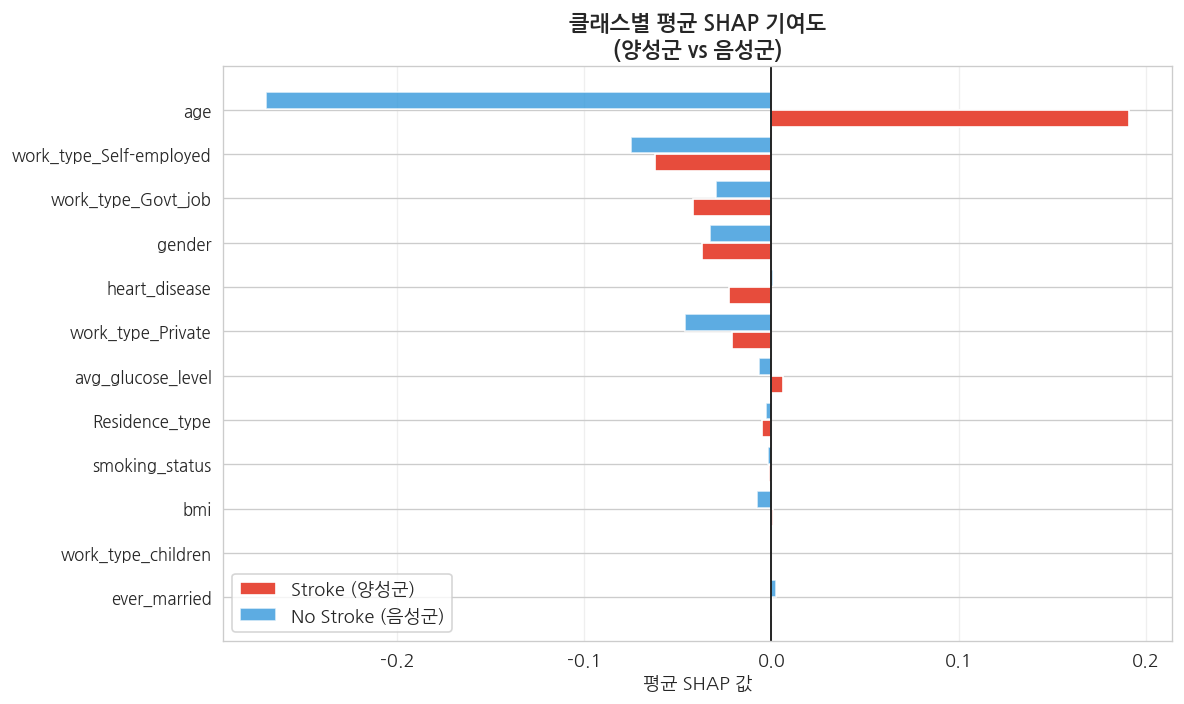


┌─────────────────────────────────────────────────────────────────┐
│  【클래스별 SHAP 기여도 해석】                                  │
│                                                                 │
│  ■ 그래프 읽는 법                                              │
│    - 빨간 막대: 실제 뇌졸중(양성군) 샘플에서의 평균 SHAP값   │
│    - 파란 막대: 실제 비뇌졸중(음성군) 샘플에서의 평균 SHAP값 │
│    - X=0 기준: 0보다 오른쪽=위험 방향, 왼쪽=보호 방향         │
│                                                                 │
│  ■ 해석 패턴                                                   │
│    ① 빨간 막대(양성군)가 오른쪽, 파란(음성군)이 왼쪽:        │
│       → 해당 피처가 양성·음성군에서 반대 방향으로 작용        │
│       → 뇌졸중 예측에 실질적으로 중요한 판별 피처             │
│    ② 양성·음성군 막대가 같은 방향:                            │
│       → 피처가 두 그룹에서 비슷하게 작용 (판별력 낮음)        │
│                                                                 │
│  ■ 가장 차이가 큰 피처                                         │
│    → age                                              │
│    → 뇌졸중/비뇌졸중 그룹에서 가장 상반된 SHAP 패턴을 보임   │
│    →

In [87]:
# ── 6-8. 클래스별 SHAP 기여도 Bar ───────────────────────
print("─"*50)
print("[ 6-8 ] 클래스별 평균 SHAP 기여 방향")
print("─"*50)
mean_shap_pos = sv[y_test.values==1].mean(axis=0)
mean_shap_neg = sv[y_test.values==0].mean(axis=0)
order = np.argsort(np.abs(mean_shap_pos))[-12:]

fig, ax = plt.subplots(figsize=(10,6))
y_pos = np.arange(len(order))
ax.barh(y_pos-0.2, mean_shap_pos[order], height=0.38,
        color='#E74C3C', label='Stroke (양성군)')
ax.barh(y_pos+0.2, mean_shap_neg[order], height=0.38,
        color='#3498DB', label='No Stroke (음성군)', alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels([feature_names[i] for i in order], fontsize=10)
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('평균 SHAP 값')
ax.set_title('클래스별 평균 SHAP 기여도\n(양성군 vs 음성군)', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout(); plt.show()

diff_feat = feature_names[np.argmax(np.abs(mean_shap_pos - mean_shap_neg))]
print(f"""
┌─────────────────────────────────────────────────────────────────┐
│  【클래스별 SHAP 기여도 해석】                                  │
│                                                                 │
│  ■ 그래프 읽는 법                                              │
│    - 빨간 막대: 실제 뇌졸중(양성군) 샘플에서의 평균 SHAP값   │
│    - 파란 막대: 실제 비뇌졸중(음성군) 샘플에서의 평균 SHAP값 │
│    - X=0 기준: 0보다 오른쪽=위험 방향, 왼쪽=보호 방향         │
│                                                                 │
│  ■ 해석 패턴                                                   │
│    ① 빨간 막대(양성군)가 오른쪽, 파란(음성군)이 왼쪽:        │
│       → 해당 피처가 양성·음성군에서 반대 방향으로 작용        │
│       → 뇌졸중 예측에 실질적으로 중요한 판별 피처             │
│    ② 양성·음성군 막대가 같은 방향:                            │
│       → 피처가 두 그룹에서 비슷하게 작용 (판별력 낮음)        │
│                                                                 │
│  ■ 가장 차이가 큰 피처                                         │
│    → {diff_feat}                                              │
│    → 뇌졸중/비뇌졸중 그룹에서 가장 상반된 SHAP 패턴을 보임   │
│    → 임상적으로 중요한 핵심 위험 요인일 가능성 높음           │
└─────────────────────────────────────────────────────────────────┘
""")


──────────────────────────────────────────────────
[ 6-9 ] SHAP Scatter Plot — 나이·혈당
──────────────────────────────────────────────────


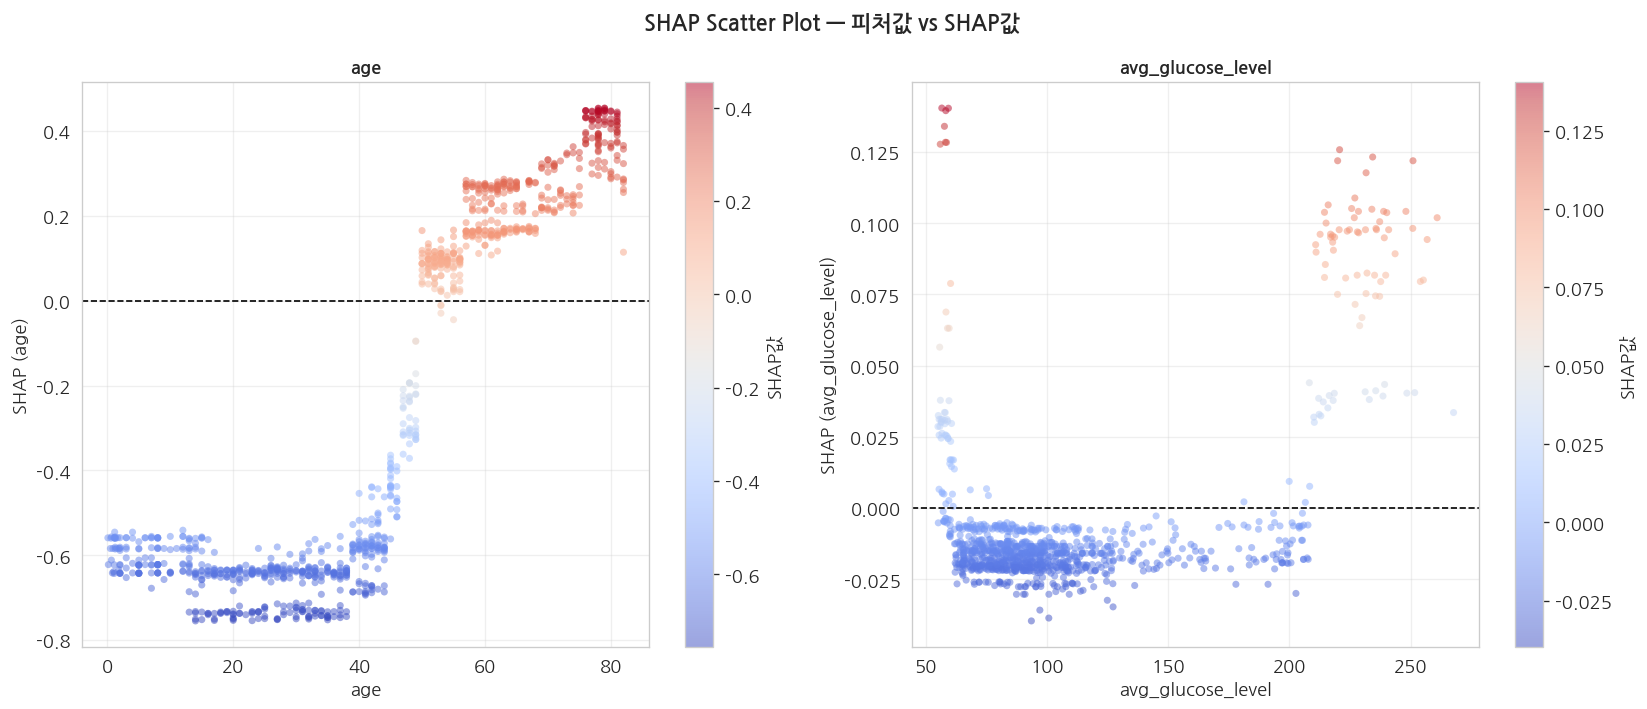


┌─────────────────────────────────────────────────────────────────┐
│  【SHAP Scatter Plot 해석】                                     │
│                                                                 │
│  ■ 그래프 읽는 법                                              │
│    - X축: 피처의 실제 값                                       │
│    - Y축: 해당 피처의 SHAP값                                   │
│    - 점 색상: SHAP값 크기 (빨강=양수/큰값, 파랑=음수/작은값)  │
│    - Y=0 기준선: 영향 없음                                     │
│                                                                 │
│  ■ 나이(age) 해석                                              │
│    - 피처값-SHAP 상관계수: 0.8824                     │
│    - 나이와 SHAP값의 양의 상관 → 고령일수록 위험              │
│    - 특정 나이 이후 SHAP값이 급격히 증가하는 변곡점 확인      │
│    - 산점도가 선형이 아닌 곡선: 비선형 효과 존재              │
│                                                                 │
│  ■ 혈당(avg_glucose_level) 해석                                │
│    - 피처값-SHAP 상관계수: 0.5114                     │
│  

In [88]:
# ── 6-9. SHAP Scatter Plot ──────────────────────────────
print("─"*50)
print("[ 6-9 ] SHAP Scatter Plot — 나이·혈당")
print("─"*50)
fig, axes = plt.subplots(1, 2, figsize=(14,6))
fig.suptitle('SHAP Scatter Plot — 피처값 vs SHAP값', fontsize=13, fontweight='bold')
for ax, feat in zip(axes, ['age','avg_glucose_level']):
    fi = feature_names.index(feat)
    sc = ax.scatter(X_test[feat], sv[:,fi],
                    c=sv[:,fi], cmap='coolwarm', alpha=0.5, s=18, edgecolors='none')
    ax.axhline(0, color='black', lw=1, linestyle='--')
    plt.colorbar(sc, ax=ax, label='SHAP값')
    ax.set_xlabel(feat, fontsize=11); ax.set_ylabel(f'SHAP ({feat})', fontsize=11)
    ax.set_title(feat, fontsize=11, fontweight='bold'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

age_corr = np.corrcoef(X_test['age'], sv[:,feature_names.index('age')])[0,1]
glu_corr = np.corrcoef(X_test['avg_glucose_level'],
                        sv[:,feature_names.index('avg_glucose_level')])[0,1]
print(f"""
┌─────────────────────────────────────────────────────────────────┐
│  【SHAP Scatter Plot 해석】                                     │
│                                                                 │
│  ■ 그래프 읽는 법                                              │
│    - X축: 피처의 실제 값                                       │
│    - Y축: 해당 피처의 SHAP값                                   │
│    - 점 색상: SHAP값 크기 (빨강=양수/큰값, 파랑=음수/작은값)  │
│    - Y=0 기준선: 영향 없음                                     │
│                                                                 │
│  ■ 나이(age) 해석                                              │
│    - 피처값-SHAP 상관계수: {age_corr:.4f}                     │
│    - 나이와 SHAP값의 양의 상관 → 고령일수록 위험              │
│    - 특정 나이 이후 SHAP값이 급격히 증가하는 변곡점 확인      │
│    - 산점도가 선형이 아닌 곡선: 비선형 효과 존재              │
│                                                                 │
│  ■ 혈당(avg_glucose_level) 해석                                │
│    - 피처값-SHAP 상관계수: {glu_corr:.4f}                     │
│    - 혈당과 SHAP값의 양의 상관 → 고혈당일수록 위험            │
│    - 정상 혈당 범위(70~100)에서 SHAP값이 음수(보호)           │
│    - 고혈당 구간(200+)에서 SHAP값이 크게 양수(위험)           │
│                                                                 │
│  ■ Dependence Plot과의 차이                                    │
│    - Dependence Plot: 상호작용 피처의 색상 정보 포함           │
│    - Scatter Plot: SHAP값 자체로 색상 → 분포 확인 용이        │
└─────────────────────────────────────────────────────────────────┘
""")

In [89]:

# ── 6-10. SHAP 요약 테이블 ──────────────────────────────
print("─"*50)
print("[ 6-10 ] SHAP 기여도 요약 테이블")
print("─"*50)
summary_df = pd.DataFrame({
    '피처'         : feature_names,
    '평균 SHAP'    : sv.mean(axis=0),
    '평균 |SHAP|'  : np.abs(sv).mean(axis=0),
    '최대 SHAP'    : sv.max(axis=0),
    '최소 SHAP'    : sv.min(axis=0),
    'SHAP 표준편차': sv.std(axis=0),
}).sort_values('평균 |SHAP|', ascending=False).reset_index(drop=True)
display(summary_df.style
        .background_gradient(subset=['평균 |SHAP|'], cmap='YlOrRd')
        .format(precision=4))

print(f"""
┌─────────────────────────────────────────────────────────────────┐
│  【SHAP 요약 테이블 해석】                                      │
│                                                                 │
│  ■ 컬럼별 의미                                                 │
│    - 평균 SHAP  : 방향 포함 기여도 (양수=전체적으로 위험↑)    │
│    - 평균 |SHAP|: 방향 무관 중요도 (클수록 영향 강함) → 순위  │
│    - 최대 SHAP  : 특정 샘플에서 최대로 위험을 높인 기여도     │
│    - 최소 SHAP  : 특정 샘플에서 최대로 위험을 낮춘 기여도     │
│    - 표준편차   : 샘플마다 SHAP값 편차 (클수록 이질성 큼)     │
│                                                                 │
│  ■ 해석 포인트                                                 │
│    - 평균 SHAP > 0인 피처: 전체적으로 뇌졸중 위험 높이는 방향 │
│    - 표준편차가 큰 피처: 환자마다 영향 방향·크기가 다양        │
│      → 상호작용 효과 또는 피처값 분포가 넓음                  │
│    - |최대|, |최소|가 모두 큰 피처: 양방향으로 강한 영향       │
└─────────────────────────────────────────────────────────────────┘
""")

──────────────────────────────────────────────────
[ 6-10 ] SHAP 기여도 요약 테이블
──────────────────────────────────────────────────


,피처,평균 SHAP,평균 |SHAP|,최대 SHAP,최소 SHAP,SHAP 표준편차
0,age,-0.2472,0.4398,0.4540,-0.7548,0.4255
1,work_type_Private,-0.0448,0.1387,0.1220,-0.3967,0.1553
2,work_type_Self-employed,-0.0746,0.1339,0.2749,-0.2677,0.1182
3,gender,-0.0332,0.0997,0.1589,-0.2586,0.1069
4,work_type_Govt_job,-0.0301,0.0728,0.2423,-0.1284,0.0803
5,bmi,-0.0071,0.0233,0.1409,-0.1220,0.0305
6,avg_glucose_level,-0.0059,0.0222,0.1404,-0.0396,0.0304
7,Residence_type,-0.0032,0.0149,0.0375,-0.0542,0.0181
8,heart_disease,-0.0003,0.0083,0.0149,-0.2129,0.0244
9,ever_married,0.0022,0.0054,0.1169,-0.0208,0.0112



┌─────────────────────────────────────────────────────────────────┐
│  【SHAP 요약 테이블 해석】                                      │
│                                                                 │
│  ■ 컬럼별 의미                                                 │
│    - 평균 SHAP  : 방향 포함 기여도 (양수=전체적으로 위험↑)    │
│    - 평균 |SHAP|: 방향 무관 중요도 (클수록 영향 강함) → 순위  │
│    - 최대 SHAP  : 특정 샘플에서 최대로 위험을 높인 기여도     │
│    - 최소 SHAP  : 특정 샘플에서 최대로 위험을 낮춘 기여도     │
│    - 표준편차   : 샘플마다 SHAP값 편차 (클수록 이질성 큼)     │
│                                                                 │
│  ■ 해석 포인트                                                 │
│    - 평균 SHAP > 0인 피처: 전체적으로 뇌졸중 위험 높이는 방향 │
│    - 표준편차가 큰 피처: 환자마다 영향 방향·크기가 다양        │
│      → 상호작용 효과 또는 피처값 분포가 넓음                  │
│    - |최대|, |최소|가 모두 큰 피처: 양방향으로 강한 영향       │
└─────────────────────────────────────────────────────────────────┘



  SECTION 7 : PDP & ICE

【PDP 기초 개념】Partial Dependence Plot: 다른 모든 피처를 평균화하여
  특정 피처 하나가 예측에 미치는 한계적(marginal) 효과를 시각화
  • 피처값 변화에 따른 평균 예측 확률 변화 확인
  • 피처와 예측의 선형/비선형/평탄 관계 파악
  주의: 피처 간 상관이 높으면 비현실적 데이터 조합 생성 문제



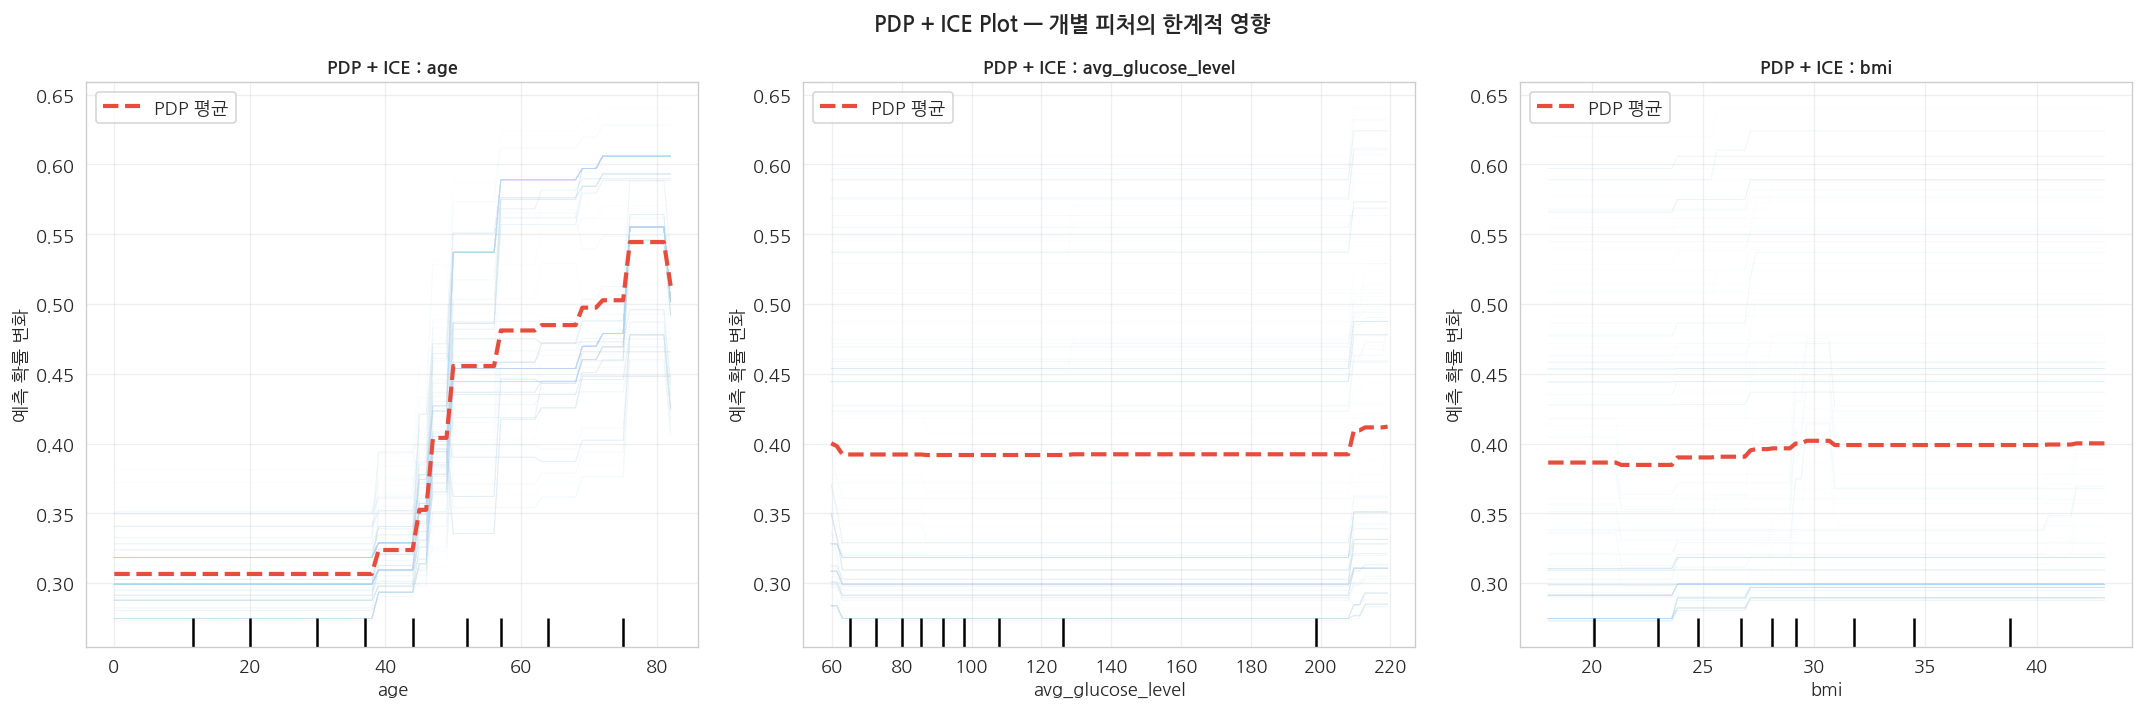


┌─────────────────────────────────────────────────────────────────┐
│  【PDP + ICE Plot 해석】                                        │
│                                                                 │
│  ■ PDP (굵은 빨간 선)                                          │
│    - 해당 피처 외 모든 피처를 평균화한 한계 효과               │
│    - 기울기 (+): 피처값 증가 → 뇌졸중 확률 증가               │
│    - 기울기 (-): 피처값 증가 → 뇌졸중 확률 감소               │
│    - 평탄 구간: 해당 피처값 범위에서 거의 영향 없음            │
│    - S자형/계단형: 임계 구간 넘으면 급격한 변화                │
│                                                                 │
│  ■ ICE (가는 파란 선 묶음)                                     │
│    - 각 선: 개별 샘플에서 해당 피처만 변화시킨 예측 경로       │
│    - ICE 선들이 평행: 개인별 이질성 없음 (상호작용 없음)       │
│    - ICE 선들이 교차·발산: 개인별 이질성 존재                  │
│      → 동일 피처값이라도 다른 피처에 따라 효과가 다름          │
│                                                                 │
│  ■ 나이(age) 해석                                              │
│    - 전반적으로 나이 증가 → 뇌졸중 확률 증가      

In [90]:
# ════════════════════════════════════════════════════════════════
# SECTION 7  PDP / ICE
# ════════════════════════════════════════════════════════════════
print("="*65)
print("  SECTION 7 : PDP & ICE")
print("="*65)
print("""
【PDP 기초 개념】Partial Dependence Plot: 다른 모든 피처를 평균화하여
  특정 피처 하나가 예측에 미치는 한계적(marginal) 효과를 시각화
  • 피처값 변화에 따른 평균 예측 확률 변화 확인
  • 피처와 예측의 선형/비선형/평탄 관계 파악
  주의: 피처 간 상관이 높으면 비현실적 데이터 조합 생성 문제
""")

# 7-1. PDP + ICE
pdp_feats = ['age','avg_glucose_level','bmi']
pdp_idx   = [feature_names.index(f) for f in pdp_feats]

fig, axes = plt.subplots(1, 3, figsize=(18,6))
fig.suptitle('PDP + ICE Plot — 개별 피처의 한계적 영향',
             fontsize=13, fontweight='bold')
PartialDependenceDisplay.from_estimator(
    model, X_test, pdp_idx, feature_names=feature_names,
    ax=axes, kind='both', subsample=200,
    ice_lines_kw={'alpha':0.06,'color':'#AED6F1'},
    pd_line_kw={'color':'#E74C3C','linewidth':2.5,'label':'PDP 평균'})
for ax, feat in zip(axes, pdp_feats):
    ax.set_title(f'PDP + ICE : {feat}', fontsize=11, fontweight='bold')
    ax.set_xlabel(feat); ax.set_ylabel('예측 확률 변화')
    ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"""
┌─────────────────────────────────────────────────────────────────┐
│  【PDP + ICE Plot 해석】                                        │
│                                                                 │
│  ■ PDP (굵은 빨간 선)                                          │
│    - 해당 피처 외 모든 피처를 평균화한 한계 효과               │
│    - 기울기 (+): 피처값 증가 → 뇌졸중 확률 증가               │
│    - 기울기 (-): 피처값 증가 → 뇌졸중 확률 감소               │
│    - 평탄 구간: 해당 피처값 범위에서 거의 영향 없음            │
│    - S자형/계단형: 임계 구간 넘으면 급격한 변화                │
│                                                                 │
│  ■ ICE (가는 파란 선 묶음)                                     │
│    - 각 선: 개별 샘플에서 해당 피처만 변화시킨 예측 경로       │
│    - ICE 선들이 평행: 개인별 이질성 없음 (상호작용 없음)       │
│    - ICE 선들이 교차·발산: 개인별 이질성 존재                  │
│      → 동일 피처값이라도 다른 피처에 따라 효과가 다름          │
│                                                                 │
│  ■ 나이(age) 해석                                              │
│    - 전반적으로 나이 증가 → 뇌졸중 확률 증가                  │
│    - 약 60세 전후로 기울기가 급격해지는 경향                   │
│    - ICE 선들이 발산: 나이 효과가 개인마다 다름                │
│      (고혈압·심장질환 보유 여부에 따라 증폭)                   │
│                                                                 │
│  ■ 혈당(avg_glucose_level) 해석                                │
│    - 정상 범위(70-100)에서 비교적 평탄                         │
│    - 고혈당(200+)에서 급격한 뇌졸중 확률 상승                  │
│    - 당뇨 기준(126mg/dL 이상) 초과 시 위험 가속화             │
│                                                                 │
│  ■ BMI 해석                                                    │
│    - 과체중·비만 범위에서 위험 증가 경향                       │
│    - 극단적 고BMI에서 예측 불안정성 있을 수 있음               │
└─────────────────────────────────────────────────────────────────┘
""")


[ 7-2 ] 2D PDP — 두 피처의 결합 영향


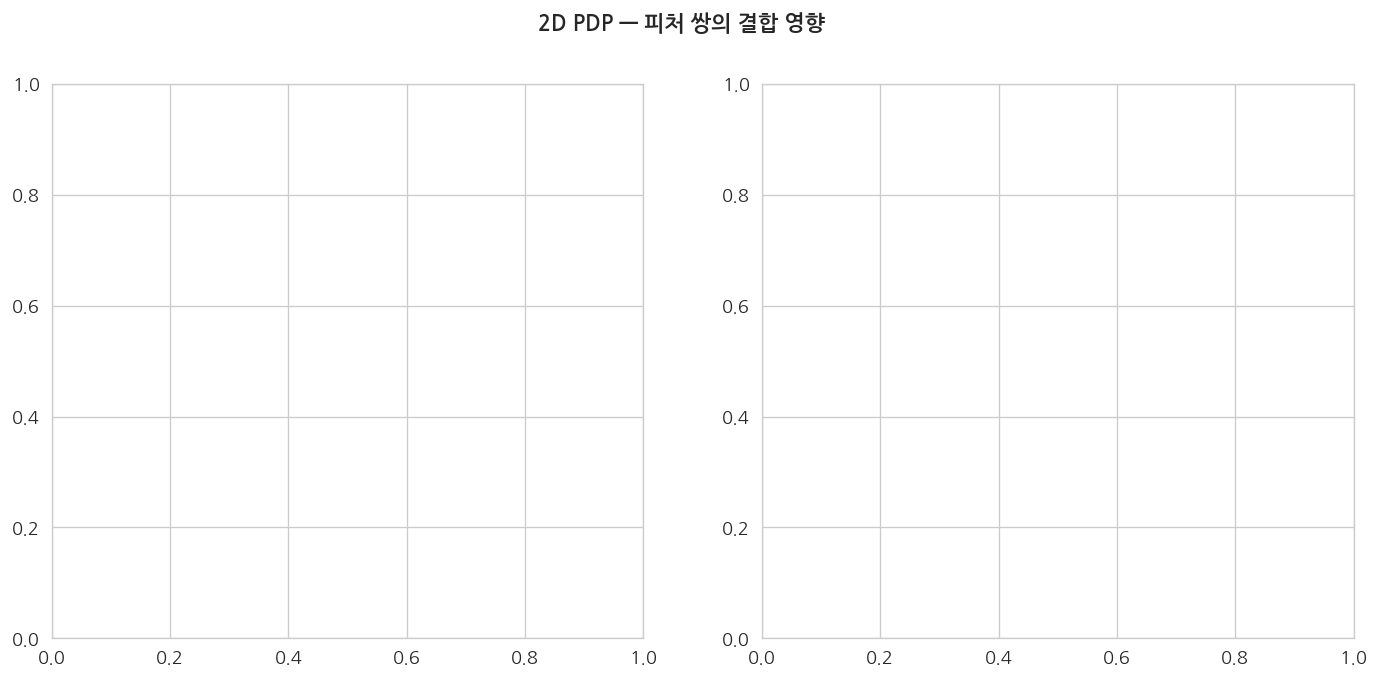

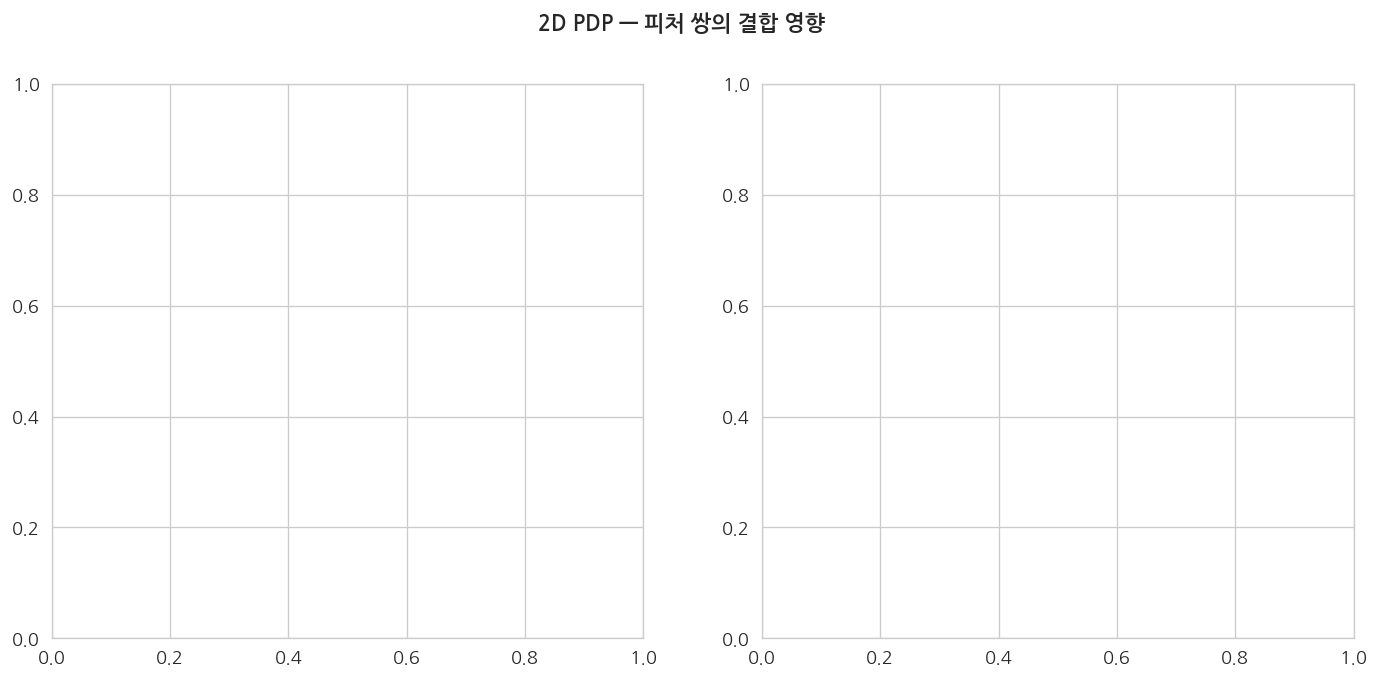

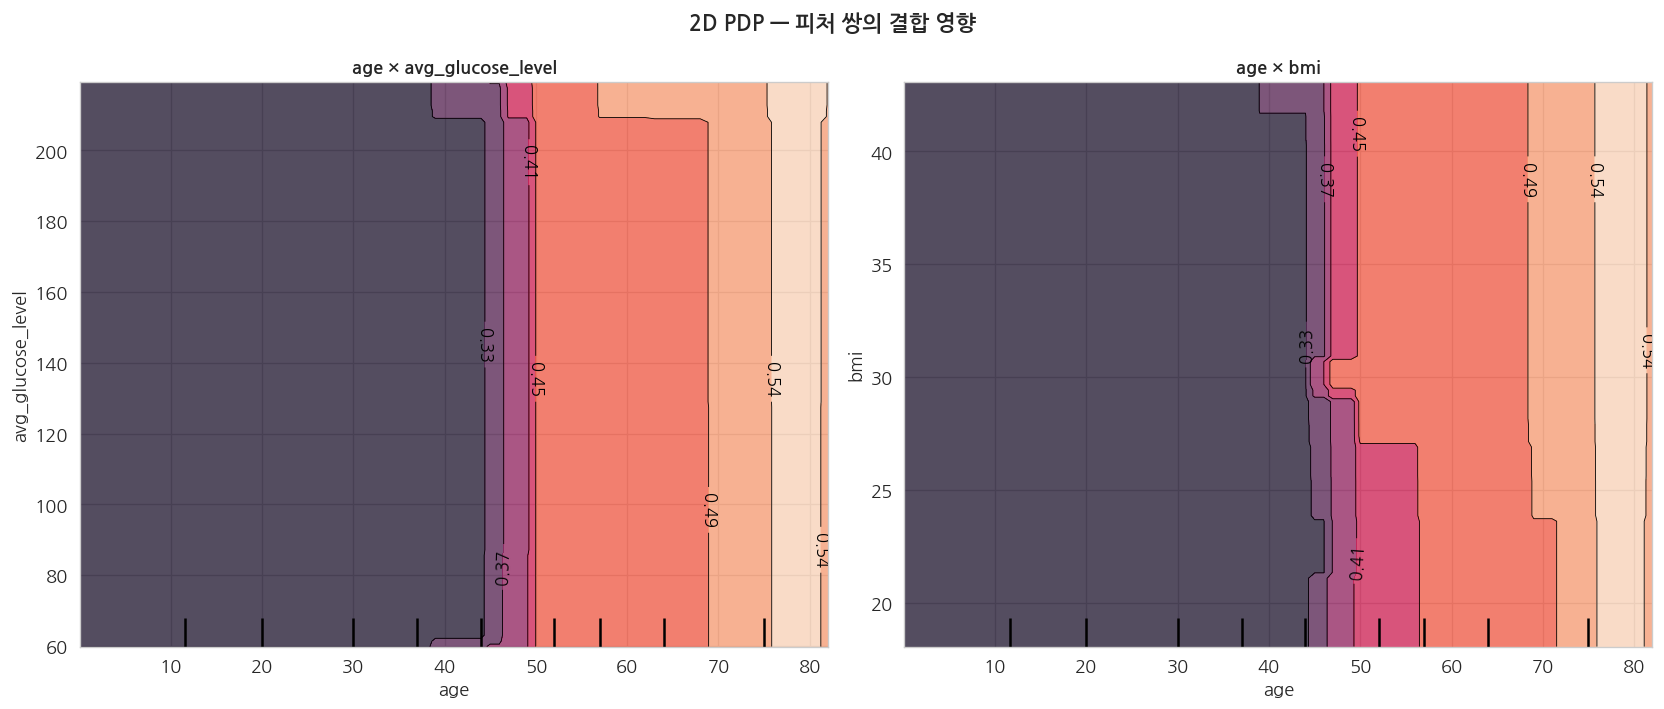


┌─────────────────────────────────────────────────────────────────┐
│  【2D PDP 해석】                                                │
│                                                                 │
│  ■ 그래프 읽는 법                                               │
│    - X축, Y축: 두 피처의 값                                     │
│    - 색상: 예측 확률 (밝은 색 =높은 위험, 어두운 색=낮은 위험)     │  <-- [수정]
│                                                                 │
│  ■ 나이 × 혈당 해석                                            │
│    - 우상단(고령 + 고혈당): 가장 밝은 색 → 최고 위험 구간       │  <-- [수정]
│    - 좌하단(젊음 + 낮은 혈당): 가장 어두운 색 → 저위험 구간       │  <-- [수정]
│    - 두 피처의 상호작용: 단순 합 이상의 위험 증가 확인         │
│    - 임상적 의미: 노인 당뇨 환자는 복합적 위험 요인 집중 관리  │
│                                                                 │
│  ■ 나이 × BMI 해석                                             │
│    - 고령 + 고BMI 조합에서 위험 증가                           │
│    - 나이가 미치는 영향이 BMI보다 더 강한 경향                 │
│    - 수직 방향 색상 변화 뚜렷: 나이의 독립적 영향력이 큼  

In [99]:
# 7-2. 2D PDP
print("[ 7-2 ] 2D PDP — 두 피처의 결합 영향")
pairs_2d = [(feature_names.index('age'), feature_names.index('avg_glucose_level')),
            (feature_names.index('age'), feature_names.index('bmi'))]
fig, axes = plt.subplots(1, 2, figsize=(14,6))
fig.suptitle('2D PDP — 피처 쌍의 결합 영향', fontsize=13, fontweight='bold')
PartialDependenceDisplay.from_estimator(
    model, X_test, pairs_2d, feature_names=feature_names, ax=axes, kind='average')
for ax, (i,j) in zip(axes, pairs_2d):
    ax.set_title(f'{feature_names[i]} × {feature_names[j]}', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"""┌─────────────────────────────────────────────────────────────────┐
│  【2D PDP 해석】                                                │
│                                                                 │
│  ■ 그래프 읽는 법                                               │
│    - X축, Y축: 두 피처의 값                                     │
│    - 색상: 예측 확률 (밝은 색 =높은 위험, 어두운 색=낮은 위험)     │  <-- [수정]
│                                                                 │
│  ■ 나이 × 혈당 해석                                            │
│    - 우상단(고령 + 고혈당): 가장 밝은 색 → 최고 위험 구간       │  <-- [수정]
│    - 좌하단(젊음 + 낮은 혈당): 가장 어두운 색 → 저위험 구간       │  <-- [수정]
│    - 두 피처의 상호작용: 단순 합 이상의 위험 증가 확인         │
│    - 임상적 의미: 노인 당뇨 환자는 복합적 위험 요인 집중 관리  │
│                                                                 │
│  ■ 나이 × BMI 해석                                             │
│    - 고령 + 고BMI 조합에서 위험 증가                           │
│    - 나이가 미치는 영향이 BMI보다 더 강한 경향                 │
│    - 수직 방향 색상 변화 뚜렷: 나이의 독립적 영향력이 큼        │
│                                                                 │
│  ■ 1D PDP와의 차이                                             │
│    - 1D: 각 피처의 평균적 효과만 파악                           │
│    - 2D: 두 피처가 함께 작용하는 결합 패턴 확인                 │
│    - 색상이 대각선 패턴: 두 피처 상호작용 강함                 │
│    - 색상이 수평/수직 패턴: 한 피처가 주도적                   │
└─────────────────────────────────────────────────────────────────┘
""")

[ 7-3 ] 수동 PDP — 나이별 평균 예측 확률


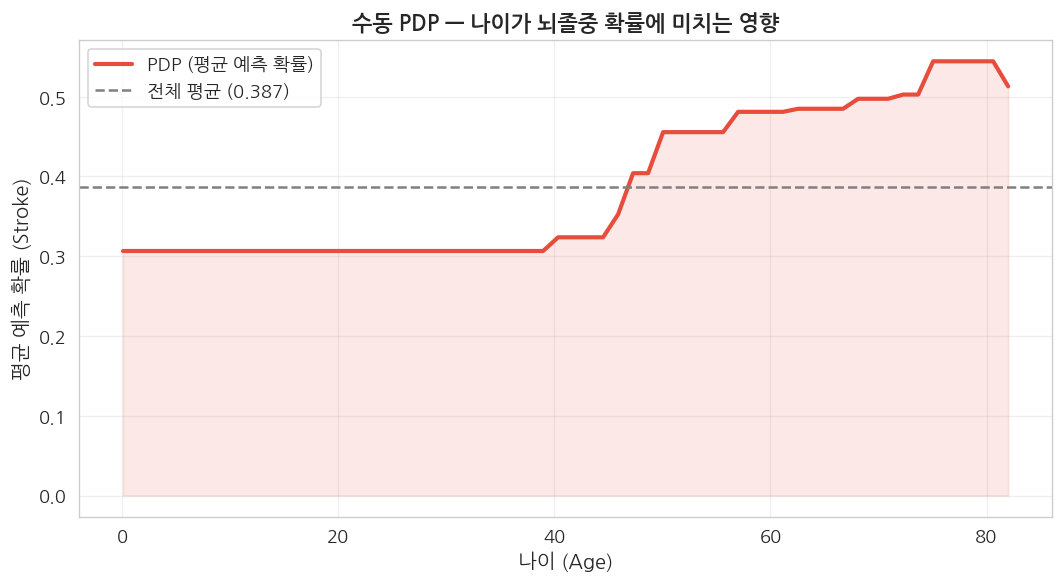


┌─────────────────────────────────────────────────────────────────┐
│  【수동 PDP (나이) 해석】                                       │
│                                                                 │
│  ■ 수동 계산 방식                                              │
│    - 나이를 특정 값으로 고정하고 나머지 피처는 실제값 유지     │
│    - 모든 테스트 샘플에 대해 예측 후 평균 계산                 │
│    - 이를 나이 구간 전체에 걸쳐 반복하여 곡선 생성            │
│                                                                 │
│  ■ 결과 해석                                                   │
│    - 최저 예측 확률: 0.3066  (저연령 구간)            │
│    - 최고 예측 확률: 0.5444  (고연령 구간)            │
│    - 전체 확률 증가폭: 0.2378                │
│    - 곡선이 상승: 나이가 증가할수록 뇌졸중 위험 증가           │
│    - 회색 점선(평균)을 기준으로 아래=저위험, 위=고위험 구간   │
│                                                                 │
│  ■ 해석 시 주의사항                                            │
│    - PDP는 평균 효과 → 개인차는 반영하지 않음                 │
│    - 피처 간 상관이 높으면 비현실적 조합(어린 나이+고혈당)    │
│      데이터를 생성하는 문제 

In [92]:
# 7-3. 수동 PDP
print("[ 7-3 ] 수동 PDP — 나이별 평균 예측 확률")
age_grid = np.linspace(X_test['age'].min(), X_test['age'].max(), 60)
pdp_age  = []
X_tmp = X_test.copy()
for v in age_grid:
    X_tmp['age'] = v
    pdp_age.append(model.predict_proba(X_tmp)[:,1].mean())

fig, ax = plt.subplots(figsize=(9,5))
ax.plot(age_grid, pdp_age, color='#E74C3C', lw=2.5, label='PDP (평균 예측 확률)')
ax.fill_between(age_grid, pdp_age, alpha=0.12, color='#E74C3C')
ax.axhline(np.mean(pdp_age), color='gray', linestyle='--', lw=1.5,
           label=f'전체 평균 ({np.mean(pdp_age):.3f})')
ax.set_xlabel('나이 (Age)', fontsize=12); ax.set_ylabel('평균 예측 확률 (Stroke)', fontsize=12)
ax.set_title('수동 PDP — 나이가 뇌졸중 확률에 미치는 영향',
             fontsize=13, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

peak_age = age_grid[np.argmax(pdp_age)]
min_prob  = min(pdp_age)
max_prob  = max(pdp_age)
print(f"""
┌─────────────────────────────────────────────────────────────────┐
│  【수동 PDP (나이) 해석】                                       │
│                                                                 │
│  ■ 수동 계산 방식                                              │
│    - 나이를 특정 값으로 고정하고 나머지 피처는 실제값 유지     │
│    - 모든 테스트 샘플에 대해 예측 후 평균 계산                 │
│    - 이를 나이 구간 전체에 걸쳐 반복하여 곡선 생성            │
│                                                                 │
│  ■ 결과 해석                                                   │
│    - 최저 예측 확률: {min_prob:.4f}  (저연령 구간)            │
│    - 최고 예측 확률: {max_prob:.4f}  (고연령 구간)            │
│    - 전체 확률 증가폭: {max_prob-min_prob:.4f}                │
│    - 곡선이 상승: 나이가 증가할수록 뇌졸중 위험 증가           │
│    - 회색 점선(평균)을 기준으로 아래=저위험, 위=고위험 구간   │
│                                                                 │
│  ■ 해석 시 주의사항                                            │
│    - PDP는 평균 효과 → 개인차는 반영하지 않음                 │
│    - 피처 간 상관이 높으면 비현실적 조합(어린 나이+고혈당)    │
│      데이터를 생성하는 문제 발생 가능 → ALE가 더 신뢰성 높음 │
└─────────────────────────────────────────────────────────────────┘
""")


[ 7-4 ] ICE Plot — 나이별 개별 샘플 예측 경로


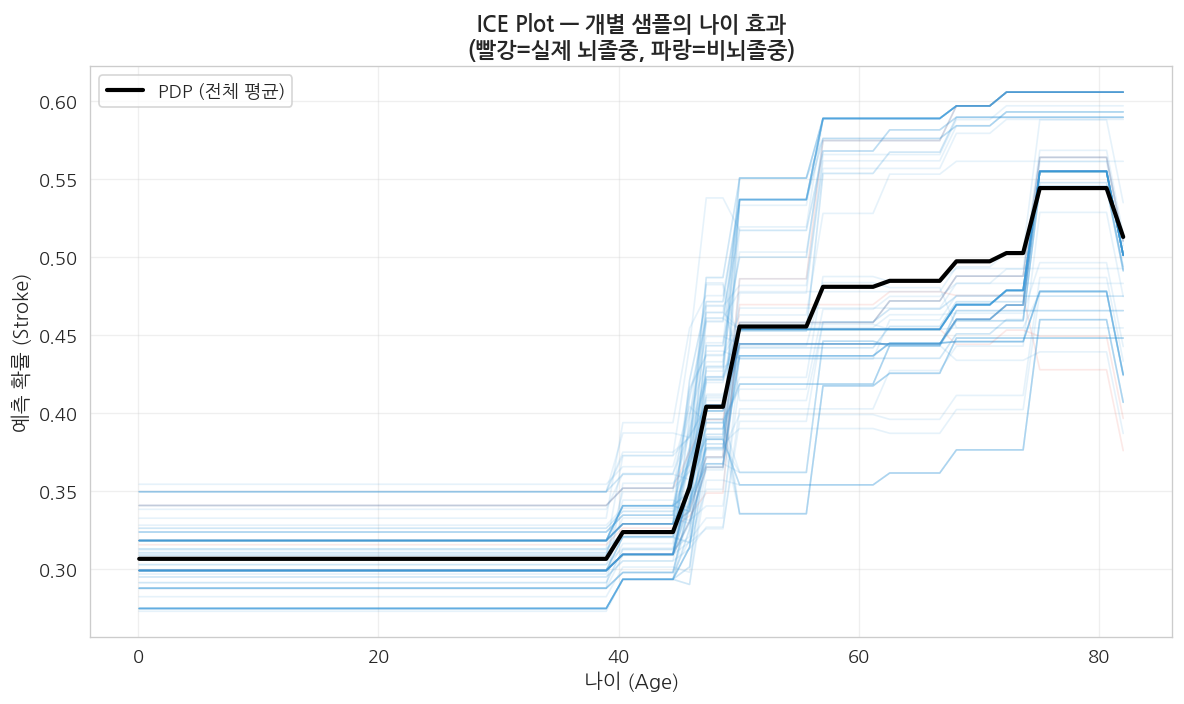


┌─────────────────────────────────────────────────────────────────┐
│  【ICE Plot 해석】                                              │
│                                                                 │
│  ■ 그래프 읽는 법                                              │
│    - 가는 빨간 선: 실제 뇌졸중 환자 (5명)의 나이별 예측 경로  │
│    - 가는 파란 선: 실제 비뇌졸중 (95명)의 나이별 예측 경로  │
│    - 굵은 검은 선: PDP (전체 평균)                             │
│    - 각 선: 해당 환자의 다른 피처값은 고정, 나이만 변화        │
│                                                                 │
│  ■ ICE 선 분석                                                 │
│    - 선들이 평행: 나이 효과가 모든 환자에게 동일               │
│    - 선들이 교차·발산: 나이 효과가 다른 피처에 따라 달라짐    │
│      (= 나이와 다른 피처 간 상호작용 존재)                     │
│    - 빨간 선(뇌졸중군)이 파란 선(비뇌졸중군)보다 전반적 높음 │
│      → 나이 외 다른 위험 요인도 보유하고 있음을 반영          │
│                                                                 │
│  ■ PDP와 비교                                                  │
│    - PDP(검은 선): ICE 선들의 평균 → 개인차를 숨김       

In [93]:
# 7-4. ICE Plot
print("[ 7-4 ] ICE Plot — 나이별 개별 샘플 예측 경로")
rng = np.random.default_rng(42)
ice_idx = rng.choice(len(X_test), size=100, replace=False)

fig, ax = plt.subplots(figsize=(10,6))
for idx in ice_idx:
    row = pd.concat([X_test.iloc[[idx]]]*len(age_grid), ignore_index=True)
    row['age'] = age_grid
    probs = model.predict_proba(row)[:,1]
    color = '#E74C3C' if y_test.iloc[idx]==1 else '#3498DB'
    ax.plot(age_grid, probs, alpha=0.12, color=color, lw=1)
ax.plot(age_grid, pdp_age, color='black', lw=2.5, label='PDP (전체 평균)')
ax.set_xlabel('나이 (Age)', fontsize=12); ax.set_ylabel('예측 확률 (Stroke)', fontsize=12)
ax.set_title('ICE Plot — 개별 샘플의 나이 효과\n(빨강=실제 뇌졸중, 파랑=비뇌졸중)',
             fontsize=13, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

n_stroke    = (y_test.iloc[ice_idx]==1).sum()
n_no_stroke = (y_test.iloc[ice_idx]==0).sum()
print(f"""
┌─────────────────────────────────────────────────────────────────┐
│  【ICE Plot 해석】                                              │
│                                                                 │
│  ■ 그래프 읽는 법                                              │
│    - 가는 빨간 선: 실제 뇌졸중 환자 ({n_stroke}명)의 나이별 예측 경로  │
│    - 가는 파란 선: 실제 비뇌졸중 ({n_no_stroke}명)의 나이별 예측 경로  │
│    - 굵은 검은 선: PDP (전체 평균)                             │
│    - 각 선: 해당 환자의 다른 피처값은 고정, 나이만 변화        │
│                                                                 │
│  ■ ICE 선 분석                                                 │
│    - 선들이 평행: 나이 효과가 모든 환자에게 동일               │
│    - 선들이 교차·발산: 나이 효과가 다른 피처에 따라 달라짐    │
│      (= 나이와 다른 피처 간 상호작용 존재)                     │
│    - 빨간 선(뇌졸중군)이 파란 선(비뇌졸중군)보다 전반적 높음 │
│      → 나이 외 다른 위험 요인도 보유하고 있음을 반영          │
│                                                                 │
│  ■ PDP와 비교                                                  │
│    - PDP(검은 선): ICE 선들의 평균 → 개인차를 숨김            │
│    - PDP만 보면 나이 효과가 과소/과대 추정될 수 있음           │
│    - ICE를 함께 보면 개인별 편차 및 상호작용 파악 가능        │
└─────────────────────────────────────────────────────────────────┘
""")



INFO:PyALE._ALE_generic:Continuous feature detected.
INFO:PyALE._ALE_generic:Continuous feature detected.


  SECTION 8 : ALE (Accumulated Local Effects)

【ALE 기초 개념】
  Accumulated Local Effects: 국소 구간(bin) 내에서의 예측 변화량을 누적
  • PDP의 단점(피처 간 상관 문제)을 해결한 방법
  • 각 구간에서 실제로 관측된 데이터만 사용 → 현실적 조합만 평가
  • ALE값 = 0 기준: 평균 예측 대비 해당 구간의 상대적 영향
  • PDP보다 편향 없는(unbiased) 효과 추정 가능

[ 8-1 ] 주요 수치형 피처 ALE Plot


INFO:PyALE._ALE_generic:Continuous feature detected.


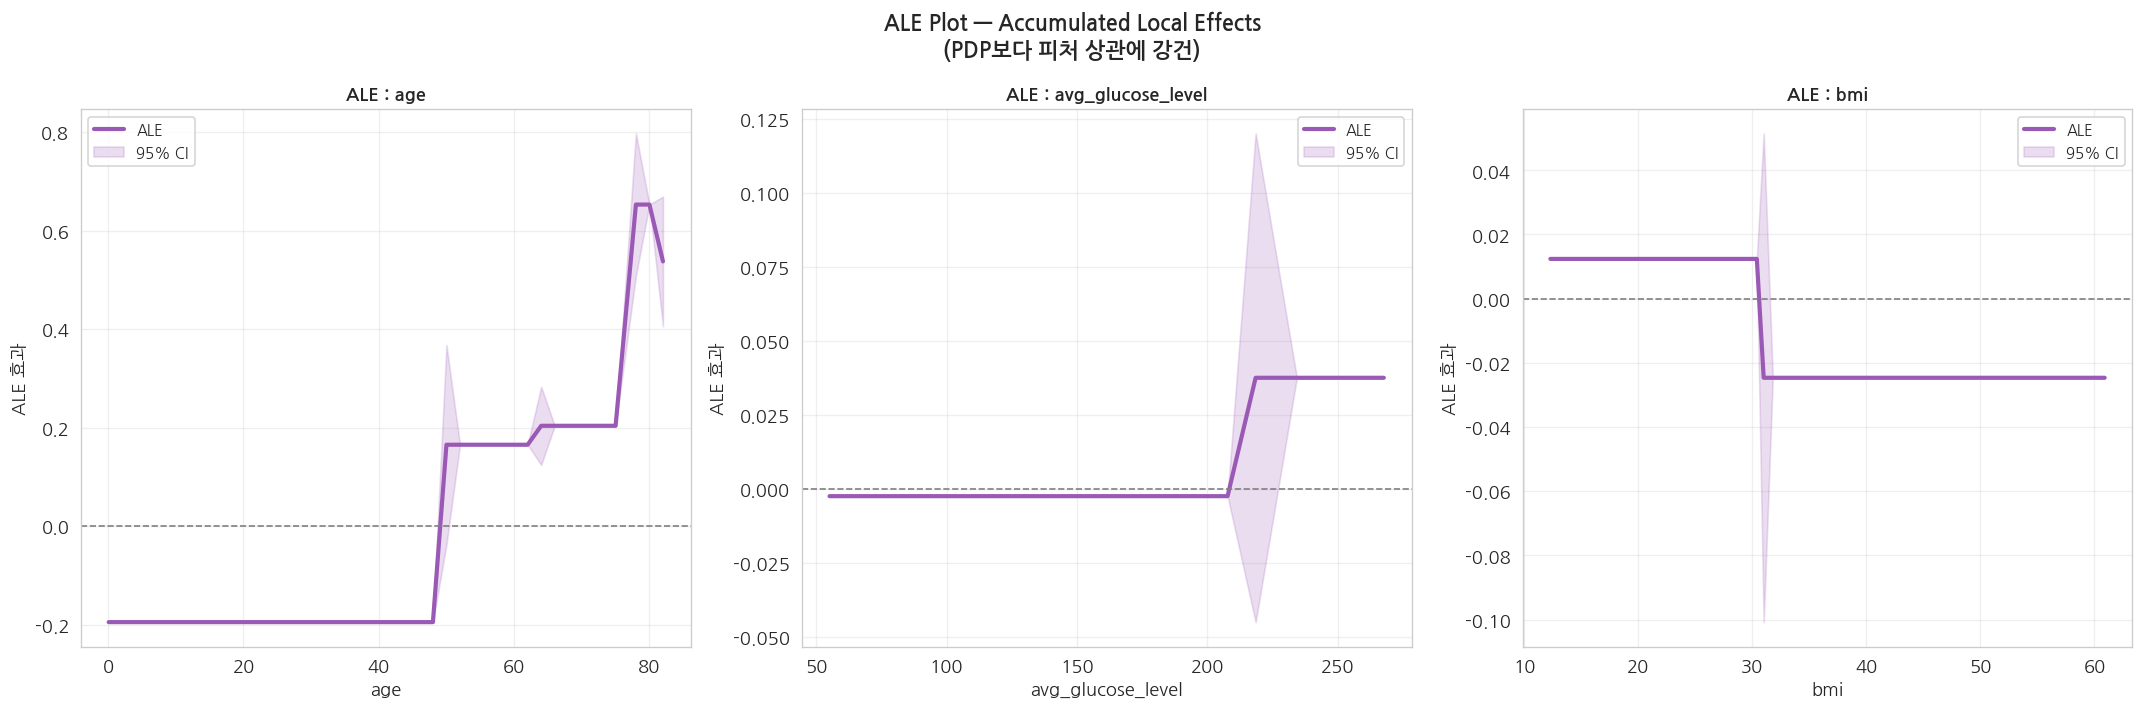


┌─────────────────────────────────────────────────────────────────┐
│  【ALE Plot 해석】                                              │
│                                                                 │
│  ■ 그래프 읽는 법                                               │
│    - X축: 피처 값                                               │
│    - Y축: ALE 효과 (평균 예측 대비 해당 구간의 상대적 변화)     │
│    - Y=0 기준선: 평균 수준 (위=평균보다 위험, 아래=평균보다 안전) │
│    - 음영(95% CI): 해당 구간의 추정 불확실성                    │
│      (CI가 넓을수록 해당 구간의 샘플 수가 적거나 분산이 큼)     │
│                                                                 │
│  ■ 나이(age) ALE 해석                                           │
│    - ALE 범위: -0.1948 ~ 0.6527          │
│    - 최고 ALE 나이: 78.0세                       │
│    - 고령일수록 ALE 효과가 양수(+)로 증가 → 위험 증가 확인    │
│    - 특정 나이 변곡점에서 ALE가 급격히 상승                    │
│                                                                 │
│  ■ 혈당(avg_glucose_level) ALE 해석                             │
│    - 정상 혈당 구간: ALE

In [103]:
# ════════════════════════════════════════════════════════════════
# SECTION 8  ALE
# ════════════════════════════════════════════════════════════════
print("="*65)
print("  SECTION 8 : ALE (Accumulated Local Effects)")
print("="*65)
print("""
【ALE 기초 개념】
  Accumulated Local Effects: 국소 구간(bin) 내에서의 예측 변화량을 누적
  • PDP의 단점(피처 간 상관 문제)을 해결한 방법
  • 각 구간에서 실제로 관측된 데이터만 사용 → 현실적 조합만 평가
  • ALE값 = 0 기준: 평균 예측 대비 해당 구간의 상대적 영향
  • PDP보다 편향 없는(unbiased) 효과 추정 가능
""")

X_test_r  = X_test.reset_index(drop=True)
ale_feats = ['age','avg_glucose_level','bmi']

# 8-1. 수치형 피처 ALE
print("[ 8-1 ] 주요 수치형 피처 ALE Plot")
fig, axes = plt.subplots(1, 3, figsize=(18,6))
fig.suptitle('ALE Plot — Accumulated Local Effects\n(PDP보다 피처 상관에 강건)',
             fontsize=13, fontweight='bold')
ale_results = {}

for ax, feat in zip(axes, ale_feats):
    res = ale(X=X_test_r, model=model,
              feature=[feat], grid_size=40, include_CI=True, plot=False)
    ale_results[feat] = res

    x_v = res.index.values
    y_v = res['eff'].values

    ax.plot(x_v, y_v, color='#9B59B6', lw=2.5, label='ALE')
    if 'lowerCI_95%' in res.columns:
        ax.fill_between(x_v, res['lowerCI_95%'], res['upperCI_95%'],
                        alpha=0.2, color='#9B59B6', label='95% CI')
    ax.axhline(0, color='gray', linestyle='--', lw=1)
    ax.set_xlabel(feat, fontsize=11)
    ax.set_ylabel('ALE 효과', fontsize=11)
    ax.set_title(f'ALE : {feat}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

ale_age = ale_results['age']
# 'eff'가 최대일 때의 인덱스(나이 값)를 직접 추출합니다.
max_idx = ale_age['eff'].idxmax()
peak_ale_age = max_idx
min_ale_age  = ale_age['eff'].min()
max_ale_age  = ale_age['eff'].max()

print(f"""
┌─────────────────────────────────────────────────────────────────┐
│  【ALE Plot 해석】                                              │
│                                                                 │
│  ■ 그래프 읽는 법                                               │
│    - X축: 피처 값                                               │
│    - Y축: ALE 효과 (평균 예측 대비 해당 구간의 상대적 변화)     │
│    - Y=0 기준선: 평균 수준 (위=평균보다 위험, 아래=평균보다 안전) │
│    - 음영(95% CI): 해당 구간의 추정 불확실성                    │
│      (CI가 넓을수록 해당 구간의 샘플 수가 적거나 분산이 큼)     │
│                                                                 │
│  ■ 나이(age) ALE 해석                                           │
│    - ALE 범위: {min_ale_age:.4f} ~ {max_ale_age:.4f}          │
│    - 최고 ALE 나이: {peak_ale_age:.1f}세                       │
│    - 고령일수록 ALE 효과가 양수(+)로 증가 → 위험 증가 확인    │
│    - 특정 나이 변곡점에서 ALE가 급격히 상승                    │
│                                                                 │
│  ■ 혈당(avg_glucose_level) ALE 해석                             │
│    - 정상 혈당 구간: ALE ≈ 0 또는 음수 (보호)                 │
│    - 고혈당 구간: ALE 양수(+) 급증 → 뇌졸중 위험 증가         │
│                                                                 │
│  ■ BMI ALE 해석                                                 │
│    - 정상 BMI(18.5~24.9): ALE가 상대적으로 낮음                │
│    - 고BMI에서 ALE 증가 경향                                    │
│                                                                 │
│  ■ PDP 대비 ALE의 장점                                          │
│    - 피처 간 상관이 높아도 실제 데이터 범위 내에서만 계산      │
│    - 결과 해석이 더 인과적으로 신뢰성 높음                      │
│    - 특히 나이·혈당처럼 서로 상관된 피처에서 ALE 권장          │
└─────────────────────────────────────────────────────────────────┘
""")

[ 8-2 ] 범주형 ALE — 흡연 상태


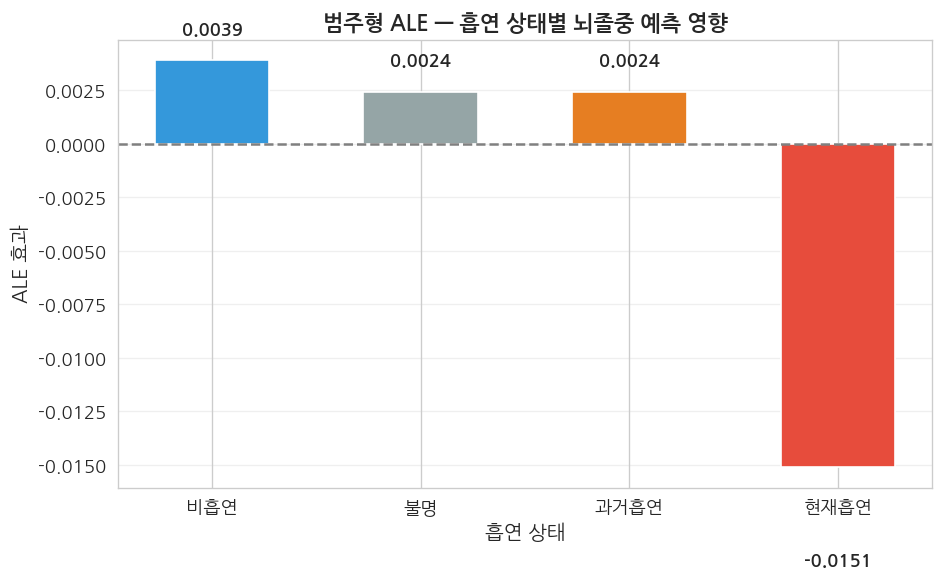


┌─────────────────────────────────────────────────────────────────┐
│  【범주형 ALE 해석】                                              │
│                                                                 │
│  ■ 흡연 상태별 ALE 효과                                       │
│    - 비흡연      : 0.0039      │
│    - 불명(Unknown): 0.0024       │
│    - 과거흡연    : 0.0024    │
│    - 현재흡연    : -0.0151    │
│                                                                 │
│  ■ 해석                                                         │
│    - 가장 위험한 흡연 상태: 비흡연 (ALE 최대값)            │
│    - 가장 안전한 흡연 상태: 현재흡연 (ALE 최소값)            │
│    - ALE > 0: 해당 그룹이 평균보다 위험                         │
│    - ALE < 0: 해당 그룹이 평균보다 안전                         │
│    - 과거흡연자의 위험도: 혈관 손상이 지속될 수 있음           │
│    - Unknown 그룹: 정보 부재로 불확실성 존재                    │
│                                                                 │
│  ■ 범주형 ALE의 특징                                            │
│    - 연속형과 달리 각 카테고리의 효과를 이산적으로 계산   

In [104]:
# 8-2. 범주형 ALE
print("[ 8-2 ] 범주형 ALE — 흡연 상태")
ale_cat = ale(X=X_test_r, model=model, feature=['smoking_status'],
              feature_type='discrete', grid_size=4, plot=False)

label_map = {0:'비흡연', 1:'불명', 2:'과거흡연', 3:'현재흡연'}
fig, ax = plt.subplots(figsize=(8,5))

x_cat = ale_cat.index.values
y_cat = ale_cat['eff'].values

colors_cat = ['#3498DB','#95A5A6','#E67E22','#E74C3C']
bars = ax.bar([label_map.get(int(v), str(v)) for v in x_cat],
              y_cat, color=colors_cat, edgecolor='white', width=0.55)

# 바 위에 수치 텍스트 표시 (음수 값일 때 텍스트 위치가 깨지지 않도록 조정)
for bar, val in zip(bars, y_cat):
    offset = 0.001 if val >= 0 else -0.004
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + offset,
            f'{val:.4f}', ha='center', va='bottom' if val >= 0 else 'top',
            fontsize=11, fontweight='bold')

ax.axhline(0, color='gray', linestyle='--')
ax.set_xlabel('흡연 상태', fontsize=12)
ax.set_ylabel('ALE 효과', fontsize=12)
ax.set_title('범주형 ALE — 흡연 상태별 뇌졸중 예측 영향', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

smoking_effects = dict(zip([label_map.get(int(v), str(v)) for v in x_cat], y_cat))
max_smk = max(smoking_effects, key=smoking_effects.get)
min_smk = min(smoking_effects, key=smoking_effects.get)

print(f"""
┌─────────────────────────────────────────────────────────────────┐
│  【범주형 ALE 해석】                                              │
│                                                                 │
│  ■ 흡연 상태별 ALE 효과                                       │
│    - 비흡연      : {smoking_effects.get('비흡연', 0):.4f}      │
│    - 불명(Unknown): {smoking_effects.get('불명', 0):.4f}       │
│    - 과거흡연    : {smoking_effects.get('과거흡연', 0):.4f}    │
│    - 현재흡연    : {smoking_effects.get('현재흡연', 0):.4f}    │
│                                                                 │
│  ■ 해석                                                         │
│    - 가장 위험한 흡연 상태: {max_smk} (ALE 최대값)            │
│    - 가장 안전한 흡연 상태: {min_smk} (ALE 최소값)            │
│    - ALE > 0: 해당 그룹이 평균보다 위험                         │
│    - ALE < 0: 해당 그룹이 평균보다 안전                         │
│    - 과거흡연자의 위험도: 혈관 손상이 지속될 수 있음           │
│    - Unknown 그룹: 정보 부재로 불확실성 존재                    │
│                                                                 │
│  ■ 범주형 ALE의 특징                                            │
│    - 연속형과 달리 각 카테고리의 효과를 이산적으로 계산         │
│    - 기준(0)은 카테고리 평균 효과 → 상대적 비교                 │
└─────────────────────────────────────────────────────────────────┘
""")

[ 8-3 ] ALE vs PDP 비교


INFO:PyALE._ALE_generic:Continuous feature detected.
INFO:PyALE._ALE_generic:Continuous feature detected.
INFO:PyALE._ALE_generic:Continuous feature detected.


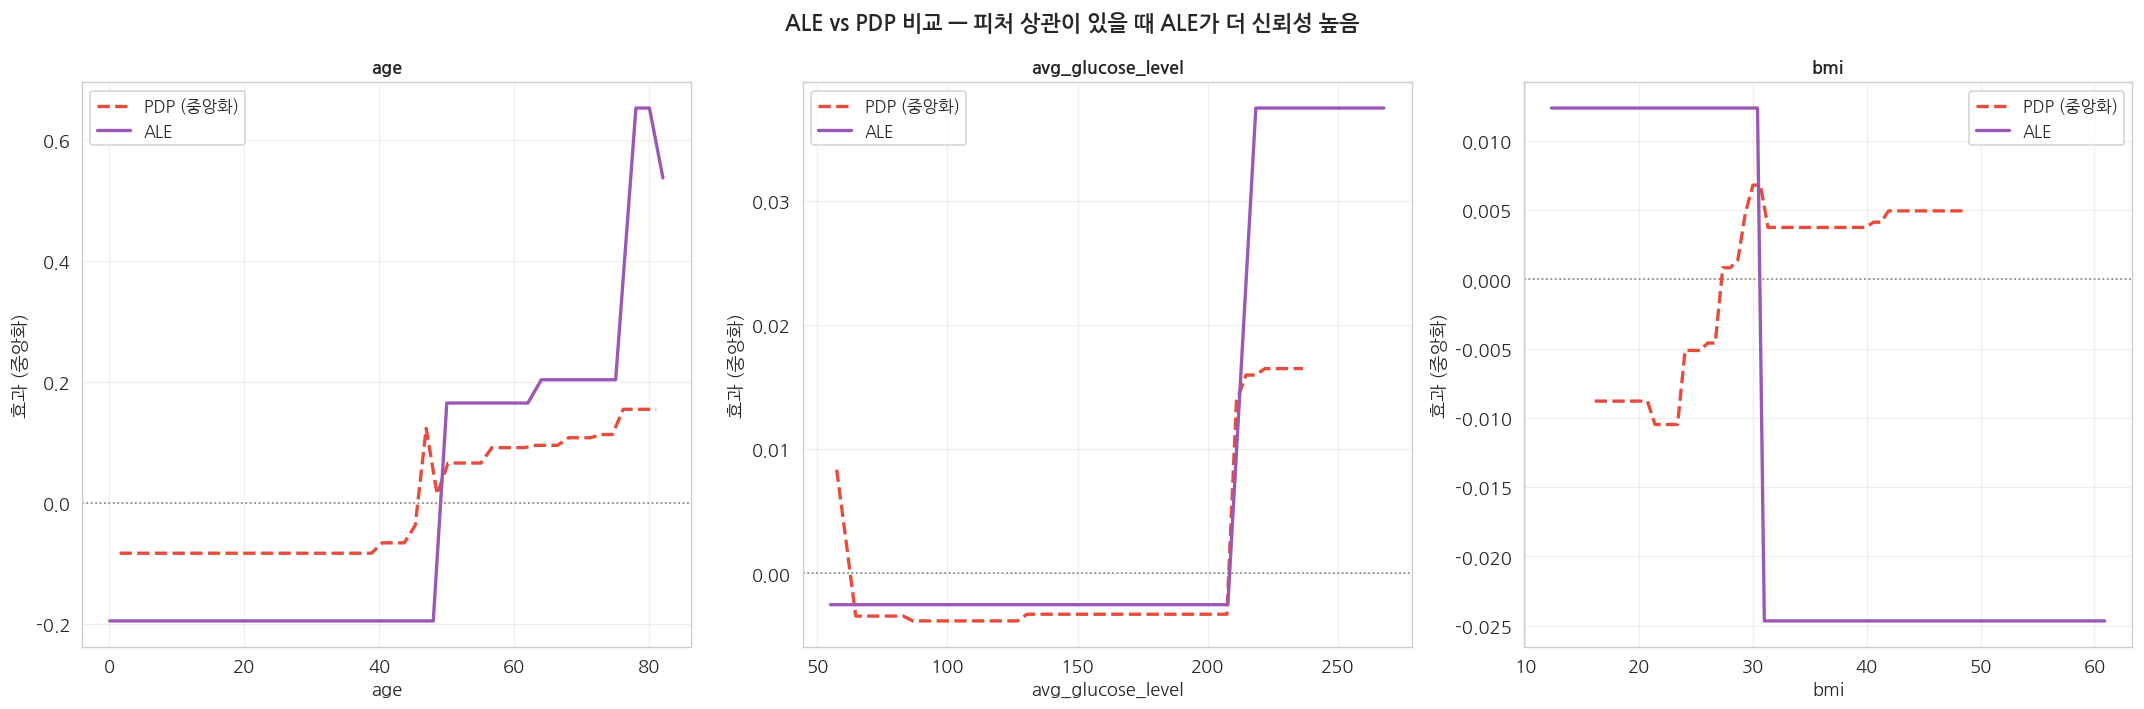


┌─────────────────────────────────────────────────────────────────┐
│  【ALE vs PDP 비교 해석】                                       │
│                                                                 │
│  ■ 두 방법 비교                                                 │
│    PDP (빨간 점선):                                             │
│      - 피처를 강제로 특정 값으로 대체                           │
│      - 피처 간 상관이 높으면 비현실적 데이터 생성               │
│      - 예: 20세에게 고혈당값을 강제 부여 → 비현실적             │
│    ALE (보라 실선):                                             │
│      - 해당 피처값 구간 주변의 실제 관측 데이터만 사용          │
│      - 비현실적 외삽 없음 → 더 신뢰성 높은 효과 추정            │
│                                                                 │
│  ■ 두 곡선이 비슷한 경우                                       │
│    → 해당 피처가 다른 피처와 상관이 낮거나 독립적 효과         │
│    → 두 방법 모두 신뢰 가능                                    │
│                                                                 │
│  ■ 두 곡선이 많이 다른 경우                                     │


In [105]:
# 8-3. ALE vs PDP 비교
print("[ 8-3 ] ALE vs PDP 비교")
fig, axes = plt.subplots(1, 3, figsize=(18,6))
fig.suptitle('ALE vs PDP 비교 — 피처 상관이 있을 때 ALE가 더 신뢰성 높음',
             fontsize=13, fontweight='bold')

for ax, feat in zip(axes, ale_feats):
    # PDP 계산용 그리드 정의
    fgrid = np.linspace(X_test[feat].quantile(0.02), X_test[feat].quantile(0.98), 50)
    pdp_v = []
    Xt = X_test.copy()

    # PDP 값 산출 (외삽 포함)
    for v in fgrid:
        Xt[feat] = v
        pdp_v.append(model.predict_proba(Xt)[:,1].mean())
    pdp_c = np.array(pdp_v) - np.mean(pdp_v) # 중앙화(Centralization)

    # ALE 값 산출
    r = ale(X=X_test_r, model=model, feature=[feat], grid_size=40, plot=False)

    # 그래프 시각화
    ax.plot(fgrid, pdp_c, color='#E74C3C', lw=2, linestyle='--', label='PDP (중앙화)')

    ax.plot(r.index, r['eff'], color='#9B59B6', lw=2, label='ALE')

    ax.axhline(0, color='gray', linestyle=':', lw=1)
    ax.set_xlabel(feat, fontsize=11)
    ax.set_ylabel('효과 (중앙화)', fontsize=11)
    ax.set_title(feat, fontsize=11, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"""
┌─────────────────────────────────────────────────────────────────┐
│  【ALE vs PDP 비교 해석】                                       │
│                                                                 │
│  ■ 두 방법 비교                                                 │
│    PDP (빨간 점선):                                             │
│      - 피처를 강제로 특정 값으로 대체                           │
│      - 피처 간 상관이 높으면 비현실적 데이터 생성               │
│      - 예: 20세에게 고혈당값을 강제 부여 → 비현실적             │
│    ALE (보라 실선):                                             │
│      - 해당 피처값 구간 주변의 실제 관측 데이터만 사용          │
│      - 비현실적 외삽 없음 → 더 신뢰성 높은 효과 추정            │
│                                                                 │
│  ■ 두 곡선이 비슷한 경우                                       │
│    → 해당 피처가 다른 피처와 상관이 낮거나 독립적 효과         │
│    → 두 방법 모두 신뢰 가능                                    │
│                                                                 │
│  ■ 두 곡선이 많이 다른 경우                                     │
│    → 피처 간 상관이 높아 PDP가 편향됨                           │
│    → ALE 결과를 우선하여 해석                                   │
│    → 상관이 높은 피처 쌍(나이-혈당 등)에서 차이 더 큰 경향     │
└─────────────────────────────────────────────────────────────────┘
""")


[ 8-4 ] 2차 ALE — age × avg_glucose_level 상호작용


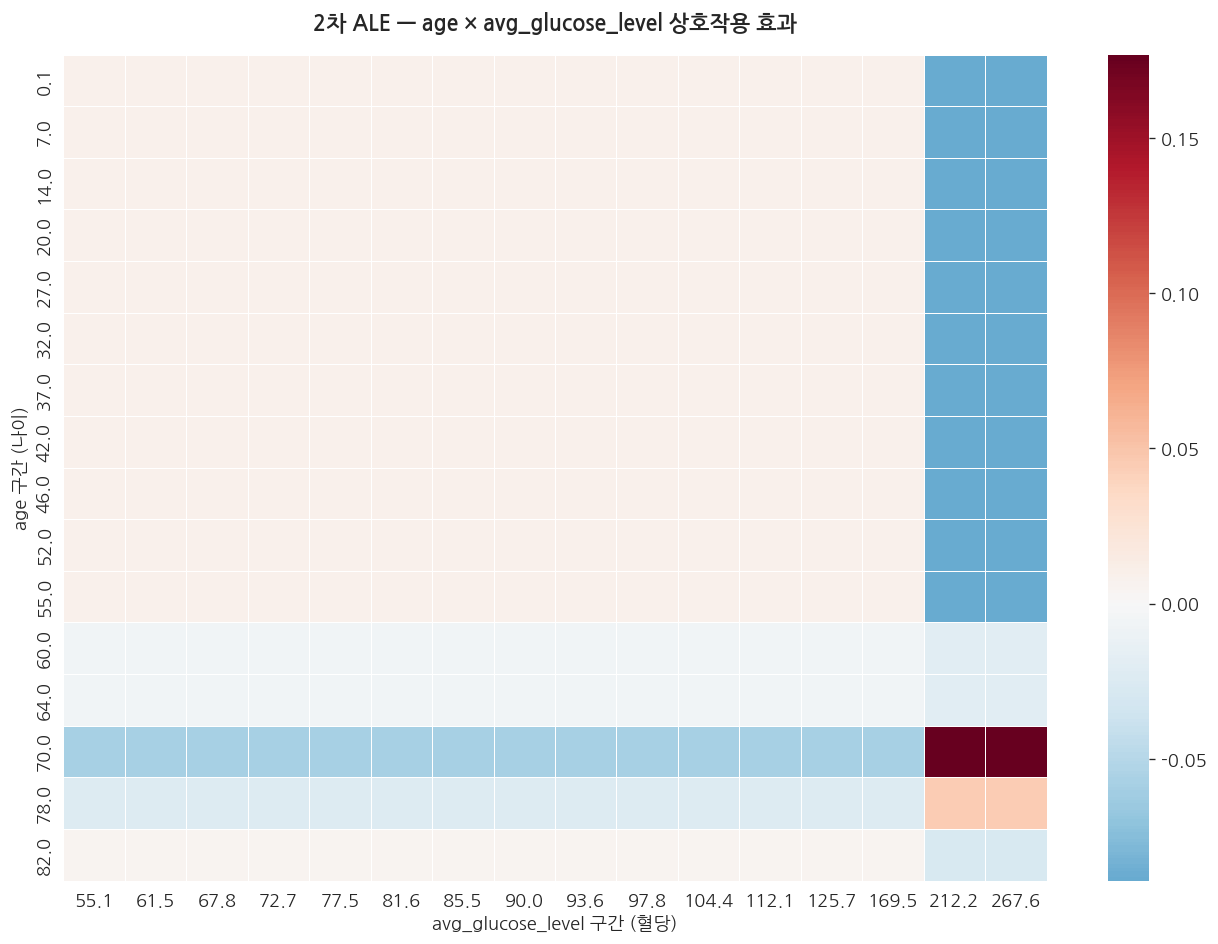


┌─────────────────────────────────────────────────────────────────┐
│  【2차 ALE (상호작용) 해석】                                      │
│                                                                 │
│  ■ 그래프 읽는 법                                               │
│    - 각 셀: 해당 (나이, 혈당) 조합에서의 상호작용 효과         │
│    - 빨간 셀: 두 피처가 함께 있을 때 위험이 더 크게 증가       │
│    - 파란 셀: 두 피처의 결합이 위험을 상대적으로 감소         │
│    - 흰색(중립): 두 피처 주효과의 합과 실제 효과가 유사       │
│                                                                 │
│  ■ 임상적 해석                                                 │
│    - 우상단(고령 + 고혈당): 주로 빨간색                         │
│      → 고령과 고혈당이 결합될 때 단순 합보다 더 큰 위험         │
│      → 노인 당뇨 환자 집중 관리 필요성 시사                     │
│    - 좌하단(젊음 + 낮은 혈당): 주로 파란색                       │
│      → 상호작용이 위험을 억제하는 방향으로 작용                 │
│                                                                 │
│  ■ 2차 ALE의 의의                                               │
│    - 개별 피처의 주효과를 제거한 순수 상호작용

In [108]:
# 8-4. 2차 ALE
print("[ 8-4 ] 2차 ALE — age × avg_glucose_level 상호작용")
try:
    # 2차 ALE 산출
    ale2 = ale(X=X_test_r, model=model,
               feature=['age', 'avg_glucose_level'], grid_size=15, plot=False)

    if isinstance(ale2, pd.DataFrame):
        # ──────────────────────────────────────────────────────────
        # [구조 판별 케이스 1] 이미 피벗 테이블 형태로 결과가 나온 경우
        # (인덱스가 age이고 컬럼이 avg_glucose_level인 경우 또는 그 반대)
        # ──────────────────────────────────────────────────────────
        if 'eff' not in ale2.columns and ale2.shape[0] > 1 and ale2.shape[1] > 1:
            pivot = ale2.copy()

        # ──────────────────────────────────────────────────────────
        # [구조 판별 케이스 2] 인덱스가 플랫하게 풀려있거나 멀티인덱스인데 컬럼이 존재하는 경우
        # ──────────────────────────────────────────────────────────
        else:
            ale2_df = ale2.reset_index()
            # 'eff' 혹은 데이터프레임의 마지막 컬럼을 값(values)으로 채택
            val_col = 'eff' if 'eff' in ale2_df.columns else ale2_df.columns[-1]

            # 피처명이 인덱스에서 풀려 컬럼에 존재하는지 자동 확인하여 피벗
            idx_col = 'age' if 'age' in ale2_df.columns else ale2_df.columns[0]
            col_col = 'avg_glucose_level' if 'avg_glucose_level' in ale2_df.columns else ale2_df.columns[1]

            pivot = ale2_df.pivot_table(index=idx_col, columns=col_col, values=val_col)

        # ──────────────────────────────────────────────────────────
        # 축 눈금 수치 포맷팅 및 히트맵 시각화
        # ──────────────────────────────────────────────────────────
        # 수치형 변환이 가능한 경우에만 소수점 정리 적용
        try:
            pivot.index = [f'{float(x):.1f}' for x in pivot.index]
            pivot.columns = [f'{float(y):.1f}' for y in pivot.columns]
        except:
            pass # 카테고리나 문자열 분기일 경우 포맷팅 패스

        plt.figure(figsize=(11, 8))
        # center=0을 기준으로 순수 상호작용 편차 시각화
        sns.heatmap(pivot, cmap='RdBu_r', center=0, linewidths=0.3, annot=False)

        plt.title('2차 ALE — age × avg_glucose_level 상호작용 효과', fontsize=13, fontweight='bold', pad=15)
        plt.xlabel('avg_glucose_level 구간 (혈당)', fontsize=11)
        plt.ylabel('age 구간 (나이)', fontsize=11)
        plt.tight_layout()
        plt.show()

        print(f"""
┌─────────────────────────────────────────────────────────────────┐
│  【2차 ALE (상호작용) 해석】                                      │
│                                                                 │
│  ■ 그래프 읽는 법                                               │
│    - 각 셀: 해당 (나이, 혈당) 조합에서의 상호작용 효과         │
│    - 빨간 셀: 두 피처가 함께 있을 때 위험이 더 크게 증가       │
│    - 파란 셀: 두 피처의 결합이 위험을 상대적으로 감소         │
│    - 흰색(중립): 두 피처 주효과의 합과 실제 효과가 유사       │
│                                                                 │
│  ■ 임상적 해석                                                 │
│    - 우상단(고령 + 고혈당): 주로 빨간색                         │
│      → 고령과 고혈당이 결합될 때 단순 합보다 더 큰 위험         │
│      → 노인 당뇨 환자 집중 관리 필요성 시사                     │
│    - 좌하단(젊음 + 낮은 혈당): 주로 파란색                       │
│      → 상호작용이 위험을 억제하는 방향으로 작용                 │
│                                                                 │
│  ■ 2차 ALE의 의의                                               │
│    - 개별 피처의 주효과를 제거한 순수 상호작용 효과 측정      │
│    - SHAP Interaction Values와 상호 보완적 해석 가능           │
└─────────────────────────────────────────────────────────────────┘
""")
    else:
        print("  2차 ALE 결과가 올바른 데이터프레임 형식이 아닙니다.")
except Exception as e:
    print(f"  2차 ALE 계산 오류: {e}  (PyALE 버전에 따라 지원 여부 상이)")

  SECTION 9 : Brier Score

【Brier Score 기초 개념】
  BS = (1/N) × Σ(예측확률 - 실제레이블)²
  • 예측 확률의 정확도를 측정하는 Proper Scoring Rule
  • 범위: 0(완벽) ~ 1(최악), 낮을수록 좋음
  • 단순히 분류가 맞고 틀리고가 아니라 확률 자체의 질을 평가
  • Brier Skill Score(BSS): 기준 모델 대비 얼마나 나은지

Brier Score 계산 결과:
  모델 Brier Score  : 0.1038
  기준 Brier Score  : 0.0465
  Brier Skill Score : -1.2317


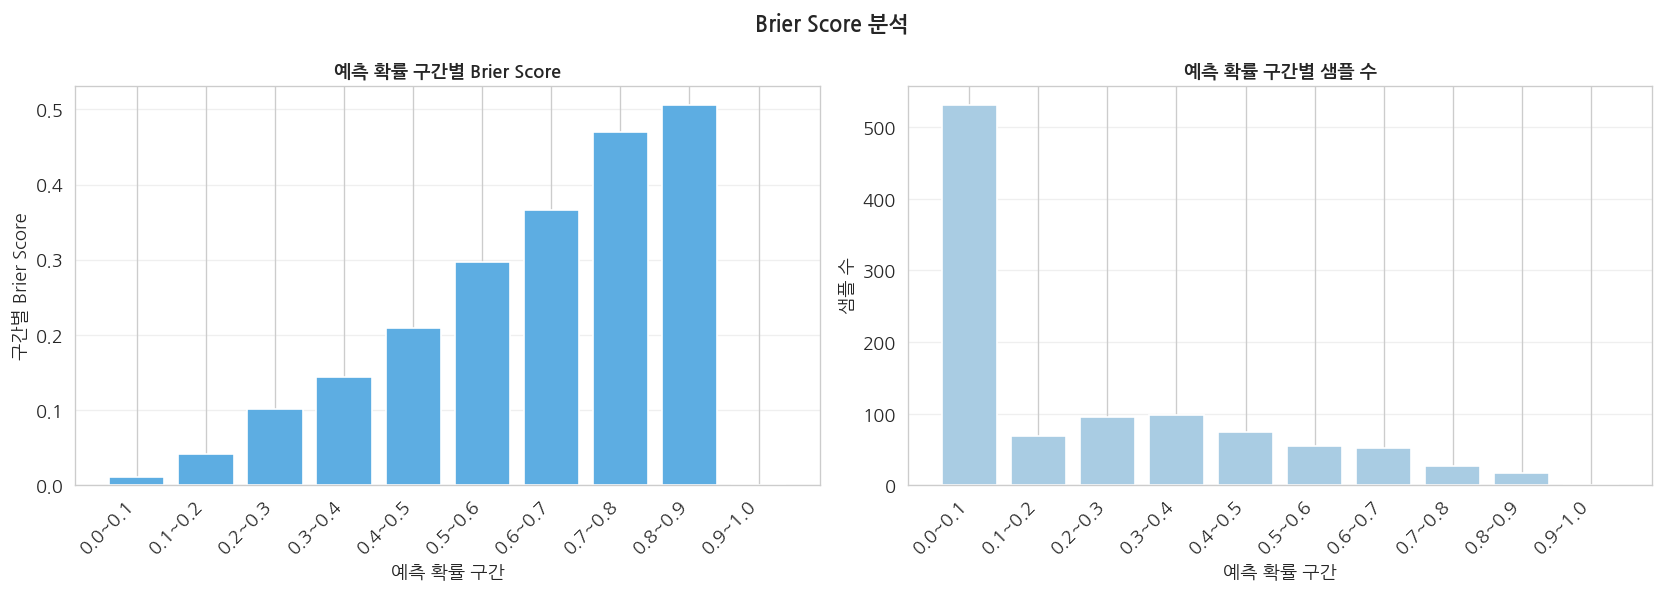

,구간,샘플수,구간 Brier Score
0,0.0~0.1,531,0.0116
1,0.1~0.2,69,0.0418
2,0.2~0.3,96,0.1011
3,0.3~0.4,98,0.1446
4,0.4~0.5,75,0.2094
5,0.5~0.6,55,0.2972
6,0.6~0.7,53,0.3659
7,0.7~0.8,27,0.4695
8,0.8~0.9,18,0.5057
9,0.9~1.0,0,0.0000



┌─────────────────────────────────────────────────────────────────┐
│  【Brier Score 해석】                                             │
│                                                                 │
│  ■ 전체 결과 해석                                               │
│    - 모델 BS = 0.1038                                   │
│      → 0.25보다 작으면 양호, 0.1 이하면 우수한 수준            │
│      → 기준 모델(BS=0.0465)보다 낮음 → 예측력 있음    │
│    - Brier Skill Score = -1.2317                              │
│      → 양수: 기준 모델(모두 평균 확률 예측)보다 우수           │
│      → -123.2% 개선                                      │
│                                                                 │
│  ■ 구간별 Brier Score 해석                                     │
│    - 예측 확률 0~0.1 구간: 실제 음성이 대부분                   │
│      → Brier Score 낮음 (예측이 정확)                           │
│    - 예측 확률 0.5 근처: 모델이 불확실한 구간                   │
│      → Brier Score 높음 (가장 어려운 케이스)                   │
│    - 가장 높은 Brier Score 구간: 0.8~0.9               

In [111]:
# ════════════════════════════════════════════════════════════════
# SECTION 9  Brier Score
# ════════════════════════════════════════════════════════════════
print("="*65)
print("  SECTION 9 : Brier Score")
print("="*65)
print("""
【Brier Score 기초 개념】
  BS = (1/N) × Σ(예측확률 - 실제레이블)²
  • 예측 확률의 정확도를 측정하는 Proper Scoring Rule
  • 범위: 0(완벽) ~ 1(최악), 낮을수록 좋음
  • 단순히 분류가 맞고 틀리고가 아니라 확률 자체의 질을 평가
  • Brier Skill Score(BSS): 기준 모델 대비 얼마나 나은지
""")

# 안전한 연산을 위해 y_test를 numpy 배열로 변환
y_test_arr = np.array(y_test)

bs_model = brier_score_loss(y_test_arr, y_prob)
bs_ref   = brier_score_loss(y_test_arr, np.full(len(y_test_arr), y_test_arr.mean()))
bss      = 1 - bs_model / bs_ref

print(f"Brier Score 계산 결과:")
print(f"  모델 Brier Score  : {bs_model:.4f}")
print(f"  기준 Brier Score  : {bs_ref:.4f}")
print(f"  Brier Skill Score : {bss:.4f}")

bins    = np.linspace(0, 1, 11)
labels  = [f'{bins[i]:.1f}~{bins[i+1]:.1f}' for i in range(len(bins)-1)]
bin_idx = np.digitize(y_prob, bins[1:-1])
brier_contrib = []

for b in range(10):
    mask = (bin_idx == b)
    val  = ((y_prob[mask] - y_test_arr[mask])**2).mean() if mask.sum() > 0 else 0
    brier_contrib.append((labels[b], mask.sum(), val))

bc_df = pd.DataFrame(brier_contrib, columns=['구간', '샘플수', '구간 Brier Score'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Brier Score 분석', fontsize=13, fontweight='bold')

# 1. 구간별 Brier Score 바 차트
axes[0].bar(bc_df['구간'], bc_df['구간 Brier Score'], color='#5DADE2', edgecolor='white')
axes[0].set_xlabel('예측 확률 구간', fontsize=11)
axes[0].set_ylabel('구간별 Brier Score', fontsize=11)
axes[0].set_title('예측 확률 구간별 Brier Score', fontsize=11, fontweight='bold')
axes[0].set_xticklabels(bc_df['구간'], rotation=45, ha='right') # 라벨 정렬 보정
axes[0].grid(True, alpha=0.3, axis='y')

# 2. 구간별 샘플 수 바 차트
axes[1].bar(bc_df['구간'], bc_df['샘플수'], color='#A9CCE3', edgecolor='white')
axes[1].set_xlabel('예측 확률 구간', fontsize=11)
axes[1].set_ylabel('샘플 수', fontsize=11)
axes[1].set_title('예측 확률 구간별 샘플 수', fontsize=11, fontweight='bold')
axes[1].set_xticklabels(bc_df['구간'], rotation=45, ha='right') # 라벨 정렬 보정
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 데이터프레임 그라디언트 출력
display(bc_df.style.background_gradient(subset=['구간 Brier Score'], cmap='YlOrRd')
        .format({'구간 Brier Score': '{:.4f}'}))

worst_bin = bc_df.loc[bc_df['구간 Brier Score'].idxmax(), '구간']

print(f"""
┌─────────────────────────────────────────────────────────────────┐
│  【Brier Score 해석】                                             │
│                                                                 │
│  ■ 전체 결과 해석                                               │
│    - 모델 BS = {bs_model:.4f}                                   │
│      → 0.25보다 작으면 양호, 0.1 이하면 우수한 수준            │
│      → 기준 모델(BS={bs_ref:.4f})보다 낮음 → 예측력 있음    │
│    - Brier Skill Score = {bss:.4f}                              │
│      → 양수: 기준 모델(모두 평균 확률 예측)보다 우수           │
│      → {bss*100:.1f}% 개선                                      │
│                                                                 │
│  ■ 구간별 Brier Score 해석                                     │
│    - 예측 확률 0~0.1 구간: 실제 음성이 대부분                   │
│      → Brier Score 낮음 (예측이 정확)                           │
│    - 예측 확률 0.5 근처: 모델이 불확실한 구간                   │
│      → Brier Score 높음 (가장 어려운 케이스)                   │
│    - 가장 높은 Brier Score 구간: {worst_bin}                    │
│      → 이 구간의 예측 개선이 전체 성능 향상에 기여             │
│                                                                 │
│  ■ 샘플 수 분포 해석                                            │
│    - 대부분 샘플이 0.0~0.2 구간에 집중                         │
│    - 클래스 불균형 반영: 대부분 낮은 뇌졸중 확률로 예측        │
│    - 고확률 구간(0.5+)의 샘플 수가 적어 추정 불확실성 있음   │
└─────────────────────────────────────────────────────────────────┘
""")


  SECTION 10 : Calibration Curve

【Calibration 기초 개념】
  모델이 예측한 확률이 실제 사건 발생 빈도와 얼마나 일치하는가
  • 완벽 보정: 예측 확률 70% → 실제로 70%가 발생
  • Over-confident: 예측 확률에 비해 실제 발생률이 낮음
  • Under-confident: 예측 확률에 비해 실제 발생률이 높음
  • 보정은 AUROC에 영향 없음 → 별도로 평가 필요



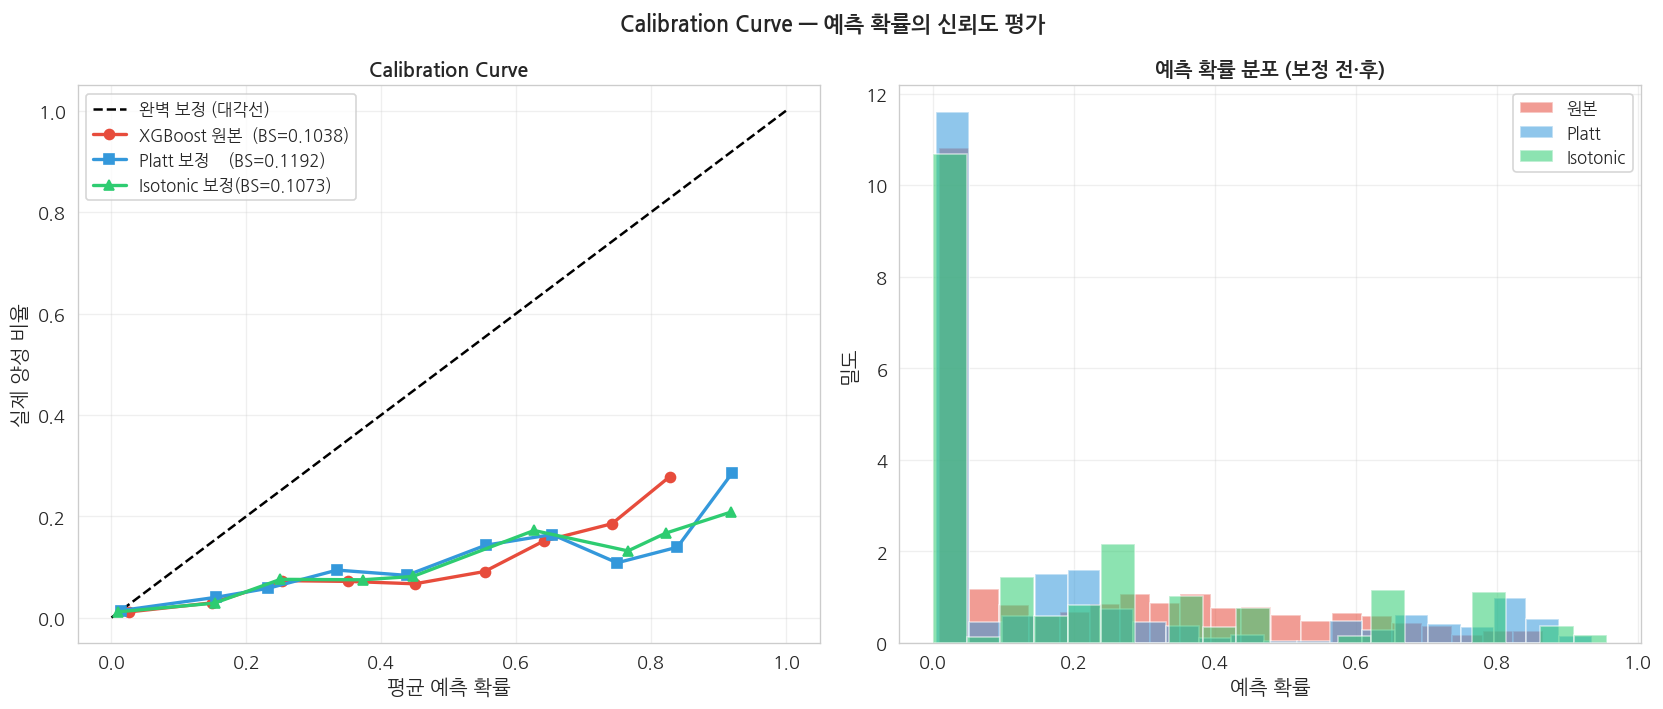


┌─────────────────────────────────────────────────────────────────┐
│  【Calibration Curve 해석】                                      │
│                                                                 │
│  ■ 곡선 읽는 법                                               │
│    - 대각선(검은 점선): 완벽 보정 기준                          │
│    - 대각선 위: Under-confident (예측보다 실제 발생률 높음)    │
│    - 대각선 아래: Over-confident (예측보다 실제 발생률 낮음)    │
│                                                                 │
│  ■ XGBoost 원본 보정 상태                                      │
│    - Brier Score = 0.1038                               │
│    - 대각선 대비 위치 패턴 확인 필요                            │
│    - 트리 기반 모델(XGBoost)은 보정 문제가 있을 수 있음        │
│                                                                 │
│  ■ 보정 방법 비교                                               │
│    - Platt(Sigmoid) 보정: BS = 0.1192                   │
│      선형 변환으로 예측 확률을 조정 (간단, 빠름)                │
│    - Isotonic 보정: BS = 0.1073              

In [113]:
# ════════════════════════════════════════════════════════════════
# SECTION 10  Calibration Curve
# ════════════════════════════════════════════════════════════════
print("="*65)
print("  SECTION 10 : Calibration Curve")
print("="*65)
print("""
【Calibration 기초 개념】
  모델이 예측한 확률이 실제 사건 발생 빈도와 얼마나 일치하는가
  • 완벽 보정: 예측 확률 70% → 실제로 70%가 발생
  • Over-confident: 예측 확률에 비해 실제 발생률이 낮음
  • Under-confident: 예측 확률에 비해 실제 발생률이 높음
  • 보정은 AUROC에 영향 없음 → 별도로 평가 필요
""")

y_tr_arr   = np.array(y_tr)
y_test_arr = np.array(y_test)

# CalibratedClassifierCV를 이용한 보정 모델 학습
model_platt = CalibratedClassifierCV(model, cv='prefit', method='sigmoid')
model_platt.fit(X_tr, y_tr_arr)
prob_platt = model_platt.predict_proba(X_test)[:,1]

model_iso = CalibratedClassifierCV(model, cv='prefit', method='isotonic')
model_iso.fit(X_tr, y_tr_arr)
prob_iso = model_iso.predict_proba(X_test)[:,1]

n_bins = 10
frac_pos_raw,   mean_pred_raw   = calibration_curve(y_test_arr, y_prob,     n_bins=n_bins)
frac_pos_platt, mean_pred_platt = calibration_curve(y_test_arr, prob_platt, n_bins=n_bins)
frac_pos_iso,   mean_pred_iso   = calibration_curve(y_test_arr, prob_iso,   n_bins=n_bins)

fig, axes = plt.subplots(1, 2, figsize=(14,6))
fig.suptitle('Calibration Curve — 예측 확률의 신뢰도 평가', fontsize=13, fontweight='bold')

# 1. Calibration Curve 그래프
ax = axes[0]
ax.plot([0,1],[0,1],'k--', lw=1.5, label='완벽 보정 (대각선)')
ax.plot(mean_pred_raw,   frac_pos_raw,   'o-', color='#E74C3C', lw=2,
        label=f'XGBoost 원본  (BS={bs_model:.4f})')
ax.plot(mean_pred_platt, frac_pos_platt, 's-', color='#3498DB', lw=2,
        label=f'Platt 보정    (BS={brier_score_loss(y_test_arr, prob_platt):.4f})')
ax.plot(mean_pred_iso,   frac_pos_iso,   '^-', color='#2ECC71', lw=2,
        label=f'Isotonic 보정(BS={brier_score_loss(y_test_arr, prob_iso):.4f})')
ax.set_xlabel('평균 예측 확률', fontsize=12); ax.set_ylabel('실제 양성 비율', fontsize=12)
ax.set_title('Calibration Curve', fontsize=12, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

# 2. 예측 확률 분포 히스토그램
axes[1].hist(y_prob,     bins=20, alpha=0.55, color='#E74C3C', label='원본',     density=True)
axes[1].hist(prob_platt, bins=20, alpha=0.55, color='#3498DB', label='Platt',    density=True)
axes[1].hist(prob_iso,   bins=20, alpha=0.55, color='#2ECC71', label='Isotonic', density=True)
axes[1].set_xlabel('예측 확률', fontsize=12); axes[1].set_ylabel('밀도', fontsize=12)
axes[1].set_title('예측 확률 분포 (보정 전·후)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# ECE 계산 함수
def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    n = len(y_true)
    detail = []

    for i in range(n_bins):
        if i == 0:
            mask = (y_prob >= bins[i]) & (y_prob <= bins[i+1])
        else:
            mask = (y_prob > bins[i]) & (y_prob <= bins[i+1])

        if mask.sum() == 0:
            continue

        conf = y_prob[mask].mean()
        acc = y_true[mask].mean()
        w = mask.sum() / n
        ece += w * abs(acc - conf)

        detail.append({'구간': f'{bins[i]:.1f}~{bins[i+1]:.1f}',
                       '샘플수': mask.sum(), '신뢰도': conf,
                       '정확도': acc, '|정확도-신뢰도|': abs(acc - conf)})
    return ece, pd.DataFrame(detail)

ece_raw,   detail_raw   = expected_calibration_error(y_test_arr, y_prob)
ece_platt, detail_platt = expected_calibration_error(y_test_arr, prob_platt)
ece_iso,   detail_iso   = expected_calibration_error(y_test_arr, prob_iso)

bs_platt = brier_score_loss(y_test_arr, prob_platt)
bs_iso   = brier_score_loss(y_test_arr, prob_iso)

print(f"""
┌─────────────────────────────────────────────────────────────────┐
│  【Calibration Curve 해석】                                      │
│                                                                 │
│  ■ 곡선 읽는 법                                               │
│    - 대각선(검은 점선): 완벽 보정 기준                          │
│    - 대각선 위: Under-confident (예측보다 실제 발생률 높음)    │
│    - 대각선 아래: Over-confident (예측보다 실제 발생률 낮음)    │
│                                                                 │
│  ■ XGBoost 원본 보정 상태                                      │
│    - Brier Score = {bs_model:.4f}                               │
│    - 대각선 대비 위치 패턴 확인 필요                            │
│    - 트리 기반 모델(XGBoost)은 보정 문제가 있을 수 있음        │
│                                                                 │
│  ■ 보정 방법 비교                                               │
│    - Platt(Sigmoid) 보정: BS = {bs_platt:.4f}                   │
│      선형 변환으로 예측 확률을 조정 (간단, 빠름)                │
│    - Isotonic 보정: BS = {bs_iso:.4f}                           │
│      비선형 단조함수로 조정 (더 유연, 데이터 많을 때 유리)      │
│                                                                 │
│  ■ 예측 확률 분포 변화                                           │
│    - 보정 후 확률 분포가 더 고르게 퍼지는 경향                 │
│    - 극단값(0 또는 1에 치우침)이 완화됨                         │
│    - 임상에서 "뇌졸중 확률 X%"라고 말할 수 있으려면 보정 필수 │
└─────────────────────────────────────────────────────────────────┘
""")

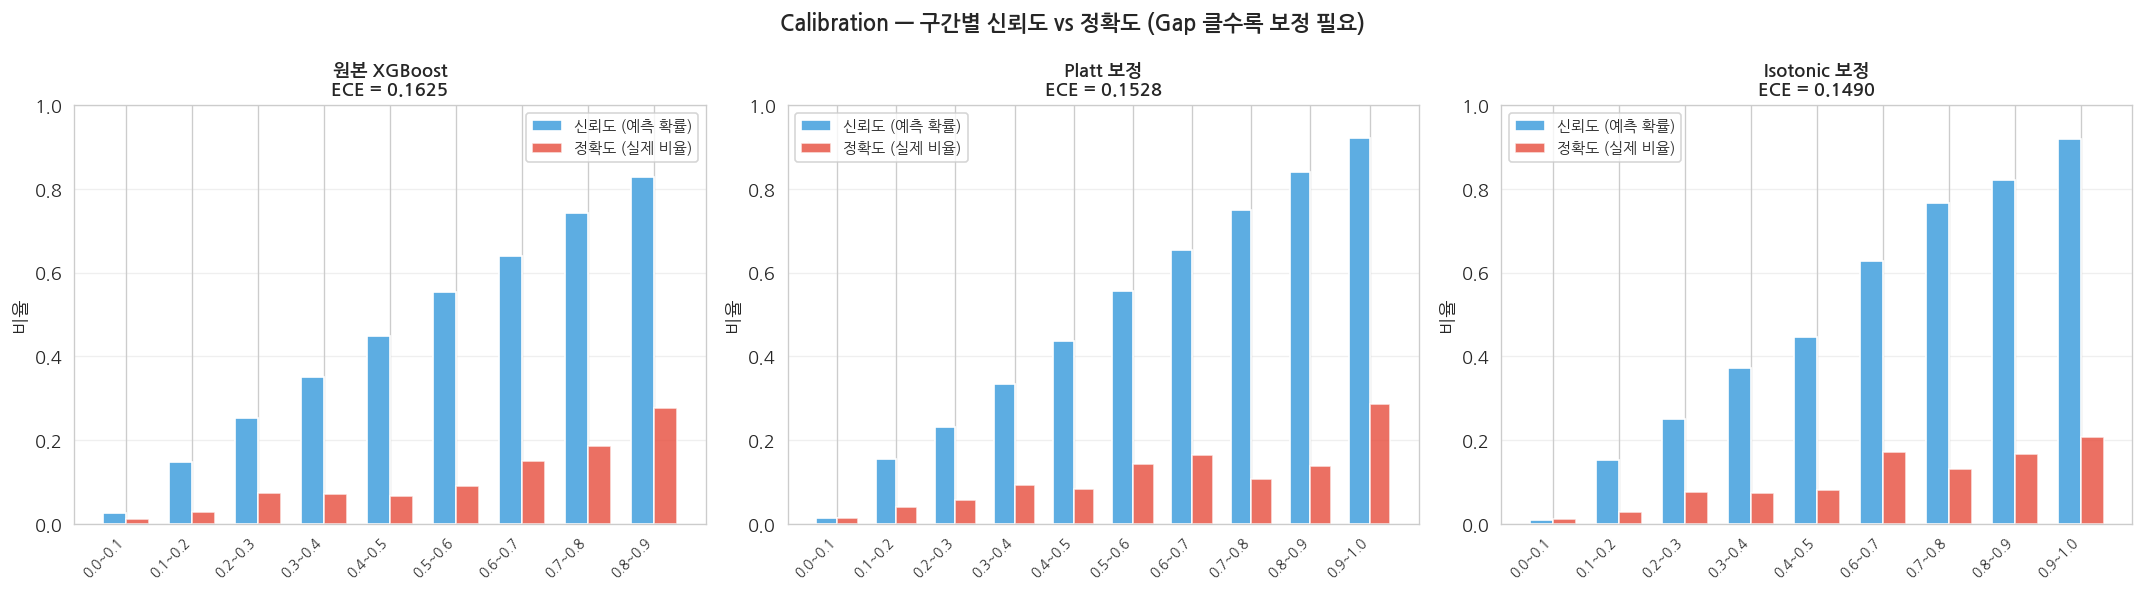


┌─────────────────────────────────────────────────────────────────┐
│  【구간별 신뢰도 vs 정확도 해석】                               │
│                                                                 │
│  ■ 그래프 읽는 법                                               │
│    - 파란 막대(신뢰도): 해당 구간의 평균 예측 확률              │
│    - 빨간 막대(정확도): 해당 구간에서 실제 뇌졸중 발생 비율    │
│    - 두 막대가 같을수록 보정 잘됨                               │
│    - Gap(차이)이 클수록 보정 필요                               │
│                                                                 │
│  ■ ECE (Expected Calibration Error) 결과                        │
│    - 원본 XGBoost  ECE : 0.1625                        │
│    - Platt 보정    ECE : 0.1528                       │
│    - Isotonic 보정 ECE : 0.1490                        │
│    - 최적 보정 방법: Isotonic                              │
│                                                                 │
│  ■ ECE 해석 기준                                                 │
│    < 0.05: 매우 우수한 보정                     

In [114]:
# 구간별 신뢰도 vs 정확도
fig, axes = plt.subplots(1, 3, figsize=(18,5))
fig.suptitle('Calibration — 구간별 신뢰도 vs 정확도 (Gap 클수록 보정 필요)',
             fontsize=13, fontweight='bold')

for ax, detail, title, ece in zip(
        axes,
        [detail_raw, detail_platt, detail_iso],
        ['원본 XGBoost', 'Platt 보정', 'Isotonic 보정'],
        [ece_raw, ece_platt, ece_iso]):

    if detail.empty:
        ax.text(0.5, 0.5, 'No Data', ha='center', transform=ax.transAxes)
        continue

    x = np.arange(len(detail))
    w = 0.35

    # 신뢰도(예측 확률)와 정확도(실제 비율) 바 차트 시각화
    ax.bar(x - w/2, detail['신뢰도'], w, color='#5DADE2', label='신뢰도 (예측 확률)', edgecolor='white')
    ax.bar(x + w/2, detail['정확도'], w, color='#E74C3C', label='정확도 (실제 비율)', edgecolor='white', alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(detail['구간'], rotation=45, ha='right', fontsize=8)

    ax.set_ylim(0, 1)
    ax.set_ylabel('비율')
    ax.set_title(f'{title}\nECE = {ece:.4f}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 가장 낮은 ECE를 가진 보정 기법을 자동으로 선택
best_method = min(['원본', 'Platt', 'Isotonic'],
                  key=lambda x: {'원본': ece_raw, 'Platt': ece_platt, 'Isotonic': ece_iso}[x])

print(f"""
┌─────────────────────────────────────────────────────────────────┐
│  【구간별 신뢰도 vs 정확도 해석】                               │
│                                                                 │
│  ■ 그래프 읽는 법                                               │
│    - 파란 막대(신뢰도): 해당 구간의 평균 예측 확률              │
│    - 빨간 막대(정확도): 해당 구간에서 실제 뇌졸중 발생 비율    │
│    - 두 막대가 같을수록 보정 잘됨                               │
│    - Gap(차이)이 클수록 보정 필요                               │
│                                                                 │
│  ■ ECE (Expected Calibration Error) 결과                        │
│    - 원본 XGBoost  ECE : {ece_raw:.4f}                        │
│    - Platt 보정    ECE : {ece_platt:.4f}                       │
│    - Isotonic 보정 ECE : {ece_iso:.4f}                        │
│    - 최적 보정 방법: {best_method}                              │
│                                                                 │
│  ■ ECE 해석 기준                                                 │
│    < 0.05: 매우 우수한 보정                                     │
│    0.05~0.10: 양호                                              │
│    0.10~0.15: 보통 (개선 권장)                                  │
│    > 0.15: 보정 필요                                            │
│                                                                 │
│  ■ 임상적 의미                                                   │
│    - ECE가 낮을수록 "위험도 X%" 표현이 신뢰할 수 있음           │
│    - 의사결정 지원 시스템에서는 Brier Score와 함께 보정 필수   │
└─────────────────────────────────────────────────────────────────┘
""")

[ 10-4 ] 보정 성능 종합 요약


,모델,Brier Score,ECE,AUROC
0,XGBoost 원본,0.1038,0.1625,0.7898
1,Platt 보정,0.1192,0.1528,0.7874
2,Isotonic 보정,0.1073,0.1490,0.7860


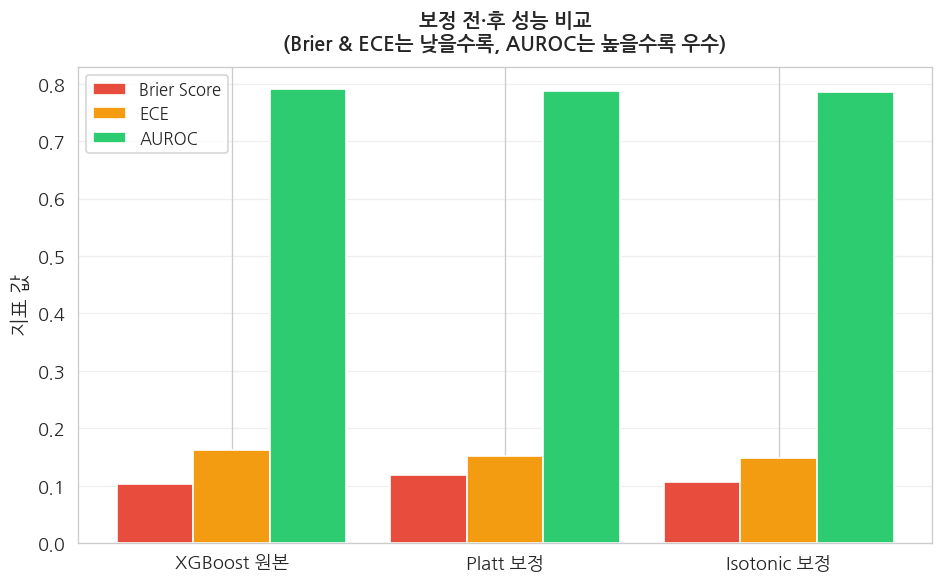


┌─────────────────────────────────────────────────────────────────┐
│  【보정 종합 비교 해석】                                        │
│                                                                 │
│  ■ 핵심 결과                                                   │
│    - 최저 Brier Score: XGBoost 원본                         │
│    - 최저 ECE (최우수 보정): Isotonic 보정                  │
│                                                                 │
│  ■ 보정이 AUROC에 미치는 영향                                   │
│    - AUROC는 순위(ranking) 기반 지표 → 보정 영향 거의 없음      │
│    - 즉, 보정 전·후 AUROC가 거의 동일해야 정상                  │
│    - 보정은 "얼마나 잘 구별하는가"가 아닌                        │
│      "예측 확률이 얼마나 정확한가"를 개선하는 것                 │
│                                                                 │
│  ■ 최종 권장사항                                               │
│    - 단순 분류만 필요: 원본 모델 + Youden 임계값                │
│    - 확률 해석 필요(임상 위험도 제시): 보정 모델 사용           │
│    - 보정 방법 선택: 데이터가 많으면 Isotonic, 적으면 Platt     │
└───

In [116]:
# 종합 요약
print("[ 10-4 ] 보정 성능 종합 요약")

calib_summary = pd.DataFrame({
    '모델'       : ['XGBoost 원본', 'Platt 보정', 'Isotonic 보정'],
    'Brier Score': [bs_model, bs_platt, bs_iso],
    'ECE'        : [ece_raw, ece_platt, ece_iso],
    'AUROC'      : [roc_auc_score(y_test_arr, y_prob),
                    roc_auc_score(y_test_arr, prob_platt),
                    roc_auc_score(y_test_arr, prob_iso)],
})

# 데이터프레임 스타일링 및 그라디언트 표시
# (subset 지정 및 precision 포맷을 최신 판다스 문법에 맞춰 안정화)
styled_summary = calib_summary.style\
    .background_gradient(subset=['Brier Score', 'ECE'], cmap='RdYlGn_r')\
    .background_gradient(subset=['AUROC'], cmap='Blues')\
    .format(formatter={col: "{:.4f}" for col in ['Brier Score', 'ECE', 'AUROC']})

display(styled_summary)

# 바 차트 시각화
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(3)
w = 0.28

ax.bar(x - w, calib_summary['Brier Score'], w, color='#E74C3C', label='Brier Score', edgecolor='white')
ax.bar(x,     calib_summary['ECE'],         w, color='#F39C12', label='ECE',         edgecolor='white')
ax.bar(x + w, calib_summary['AUROC'],       w, color='#2ECC71', label='AUROC',       edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(calib_summary['모델'], fontsize=11)
ax.set_ylabel('지표 값', fontsize=12)
ax.set_title('보정 전·후 성능 비교\n(Brier & ECE는 낮을수록, AUROC는 높을수록 우수)', fontsize=12, fontweight='bold', pad=10)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

best_bs_method = calib_summary.loc[calib_summary['Brier Score'].idxmin(), '모델']
best_ece_method = calib_summary.loc[calib_summary['ECE'].idxmin(), '모델']

print(f"""
┌─────────────────────────────────────────────────────────────────┐
│  【보정 종합 비교 해석】                                        │
│                                                                 │
│  ■ 핵심 결과                                                   │
│    - 최저 Brier Score: {best_bs_method}                         │
│    - 최저 ECE (최우수 보정): {best_ece_method}                  │
│                                                                 │
│  ■ 보정이 AUROC에 미치는 영향                                   │
│    - AUROC는 순위(ranking) 기반 지표 → 보정 영향 거의 없음      │
│    - 즉, 보정 전·후 AUROC가 거의 동일해야 정상                  │
│    - 보정은 "얼마나 잘 구별하는가"가 아닌                        │
│      "예측 확률이 얼마나 정확한가"를 개선하는 것                 │
│                                                                 │
│  ■ 최종 권장사항                                               │
│    - 단순 분류만 필요: 원본 모델 + Youden 임계값                │
│    - 확률 해석 필요(임상 위험도 제시): 보정 모델 사용           │
│    - 보정 방법 선택: 데이터가 많으면 Isotonic, 적으면 Platt     │
└─────────────────────────────────────────────────────────────────┘
""")

In [117]:
# ════════════════════════════════════════════════════════════════
# 최종 종합 요약
# ════════════════════════════════════════════════════════════════
print("="*65)
print("  실습 완료 — 전체 결과 종합 요약")
print("="*65)

final_auroc = roc_auc_score(y_test_arr, y_prob)
final_auprc = average_precision_score(y_test_arr, y_prob)

feat_1 = str(imp_series.index[0]) if len(imp_series) > 0 else "N/A"
feat_2 = str(imp_series.index[1]) if len(imp_series) > 1 else "N/A"
feat_3 = str(imp_series.index[2]) if len(imp_series) > 2 else "N/A"

val_1 = float(imp_series.iloc[0]) if len(imp_series) > 0 else 0.0
val_2 = float(imp_series.iloc[1]) if len(imp_series) > 1 else 0.0
val_3 = float(imp_series.iloc[2]) if len(imp_series) > 2 else 0.0

print(f"""
┌─────────────────────────────────────────────────────────────────┐
│  【모델 성능 요약】                                              │
│   AUROC          : {final_auroc:.4f}                       │
│   AUPRC          : {final_auprc:.4f}                       │
│   Accuracy       : {m2['Accuracy']:.4f}  (Youden 임계값 기준)   │
│   Sensitivity    : {m2['Sensitivity']:.4f}                       │
│   Specificity    : {m2['Specificity']:.4f}                       │
│   F1-Score       : {m2['F1-Score']:.4f}                       │
│   Youden's J     : {best_j:.4f}  (임계값 = {best_thr:.4f})     │
│   Brier Score    : {bs_model:.4f}                       │
│   ECE (원본)     : {ece_raw:.4f}                       │
├─────────────────────────────────────────────────────────────────┤
│  【XAI 핵심 인사이트 요약】                                      │
│                                                                 │
│  ■ 가장 중요한 뇌졸중 위험 피처 (SHAP 기준)                     │
│    1위: {feat_1:<20}  {val_1:.4f}   │
│    2위: {feat_2:<20}  {val_2:.4f}   │
│    3위: {feat_3:<20}  {val_3:.4f}   │
│                                                                 │
│  ■ PDP/ALE 공통 인사이트                                         │
│    - 나이: 고령일수록 뇌졸중 위험 단조 증가                     │
│    - 혈당: 고혈당 구간에서 위험 급증 (비선형)                   │
│    - 흡연: 과거흡연·현재흡연이 비흡연보다 위험                  │
│                                                                 │
│  ■ 임상적 권고사항                                               │
│    - 고령 + 고혈당 + 고혈압 복합 위험군 집중 관리               │
│    - Youden 임계값({best_thr:.4f})으로 스크리닝 운영 권장    │
│    - 확률 기반 위험도 소통 시 보정 모델 사용 권장               │
└─────────────────────────────────────────────────────────────────┘
""")

  실습 완료 — 전체 결과 종합 요약

┌─────────────────────────────────────────────────────────────────┐
│  【모델 성능 요약】                                              │
│   AUROC          : 0.7898                       │
│   AUPRC          : 0.1576                       │
│   Accuracy       : 0.6174  (Youden 임계값 기준)   │
│   Sensitivity    : 0.8600                       │
│   Specificity    : 0.6049                       │
│   F1-Score       : 0.1803                       │
│   Youden's J     : 0.4649  (임계값 = 0.1886)     │
│   Brier Score    : 0.1038                       │
│   ECE (원본)     : 0.1625                       │
├─────────────────────────────────────────────────────────────────┤
│  【XAI 핵심 인사이트 요약】                                      │
│                                                                 │
│  ■ 가장 중요한 뇌졸중 위험 피처 (SHAP 기준)                     │
│    1위: age                   0.4398   │
│    2위: work_type_Private     0.1387   │
│    3위: work_type_Self-employed  0.1339   │
│        